<a href="https://colab.research.google.com/github/claudio1975/Storm_Events/blob/main/9_Tornado_prediction_used_count.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tornado daily prediction per event

In [ ]:
!pip install optuna &> /dev/null

In [ ]:
!pip install -q "tabpfn>=8.0.8,<9" &> /dev/null

### Workspace

In [ ]:
import os
os.environ["TABPFN_TOKEN"] = ""

In [ ]:
# Set CUDA allocator for recycled GPU blocks.
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")


'expandable_segments:True'

In [ ]:

import gc
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import scipy
import sklearn
from scipy.stats import chi2_contingency,kruskal, kendalltau,rankdata
from scipy.stats import chi2 as chi2_dist
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_poisson_deviance, d2_tweedie_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import lightgbm
from lightgbm import LGBMRegressor
import tensorflow as tf
import glob
import optuna
from itertools import combinations, product
import torch
import tabpfn
from tabpfn import TabPFNRegressor
from tabpfn.constants import ModelVersion

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.figsize"] = (11, 5)

print("Libraries loaded:")
for name, module in [("numpy", np), ("pandas", pd), ("matplotlib", matplotlib), ("scipy", scipy),
                     ("scikit-learn", sklearn), ("lightgbm", lightgbm), ("tf", tf), ("torch", torch),
                     ("tabpfn", tabpfn),("optuna", optuna)]:
    print(f"  {name:14s} {getattr(module, '__version__', '?')}")

print("CUDA device ", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none (CPU only)")


Libraries loaded:
  numpy          2.1.3
  pandas         2.2.3
  matplotlib     3.10.0
  scipy          1.16.3
  scikit-learn   1.6.1
  lightgbm       4.6.0
  tf             2.20.0
  torch          2.11.0+cu128
  tabpfn         8.4.0
  optuna         4.9.0
CUDA device  NVIDIA A100-SXM4-40GB


In [ ]:
# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
TRAIN_END = pd.Timestamp("2023-12-31 23:59:59")
CALIBRATION_START = pd.Timestamp("2024-01-01")
CALIBRATION_END = pd.Timestamp("2024-12-31 23:59:59")
TEST_START = pd.Timestamp("2025-01-01")

EXCLUDE_GROUPS = {
    'Thunderstorm', 'High_Wind', 'Flooding', 'Winter_Storm',
       'Cold', 'Dust', 'Avalanche', 'Extreme_Heat', 'Coastal_Flood',
       'Wildfire', 'Drought', 'Tropical_Cyclone', 'Volcanic',
       'Geomagnetic', 'Marine_Other', 'Tsunami'
}

TARGETS = [
    "INJURIES_DIRECT", "INJURIES_INDIRECT",
    "DEATHS_DIRECT", "DEATHS_INDIRECT",
    "DAMAGE_PROPERTY", "DAMAGE_CROPS",
]

FORECAST_TARGETS = [
    "INJURIES_DIRECT", "INJURIES_INDIRECT",
    "DEATHS_DIRECT", "DEATHS_INDIRECT",
]

ORDINAL_LEVELS = {
    "risk": ["low", "medium", "high"],
    "event_scope": ["localized", "county-wide", "regional", "widespread"],
    "MONTH_NAME": [
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December",
    ],
}


GROUP_COL = None  # single EVENT_GROUP left after filtering (Tornado only): no group key to model on

RANDOM_STATE = 0

DEFAULT_RANDOM_STATE = 0 # Set a random seed for reproducibility throughout Python, NumPy, and TensorFlow operations
random.seed(DEFAULT_RANDOM_STATE)
os.environ['PYTHONHASHSEED'] = str(DEFAULT_RANDOM_STATE)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
np.random.seed(DEFAULT_RANDOM_STATE)
tf.random.set_seed(DEFAULT_RANDOM_STATE)

### Load data

In [ ]:
base_url = "https://github.com/claudio1975/Storm_Events/raw/main/data/"
file_names = [f"StormEvents_fe_ep_augmentation_fin_part_{i}.parquet" for i in range(1, 11)]

# Construct full URLs for each part
parts_urls = [base_url + fn for fn in file_names]

# Read each part from the URL and concatenate them into a single DataFrame
df = pd.concat([pd.read_parquet(url) for url in parts_urls], ignore_index=True)
print(f'Loaded {len(df):,} rows  ×  {df.shape[1]} columns')
print('dtype backend in use:'); print(df.dtypes.value_counts())
df.head()

Loaded 2,012,856 rows  ×  58 columns
dtype backend in use:
float64    29
object     22
int64       7
Name: count, dtype: int64


,EVENT_ID,STATE,YEAR,MONTH_NAME,EVENT_TYPE,CZ_TYPE,CZ_FIPS,CZ_NAME,WFO,BEGIN_DATE_TIME,...,ev_embedding_4,ev_embedding_5,ev_embedding_6,ev_embedding_7,ev_embedding_8,ev_embedding_9,ev_embedding_10,risk,impact_type,event_scope
0,10096222,OKLAHOMA,1950,April,Tornado,C,149,WASHITA,OUN,28-APR-50 14:45:00,...,0.122519,0.216200,-0.101279,-0.029508,-0.004710,0.132303,0.390889,high,no_significant_impact,regional
1,10120412,TEXAS,1950,April,Tornado,C,93,COMANCHE,FWD,29-APR-50 15:30:00,...,0.155210,0.202612,-0.117554,-0.069974,-0.058874,0.081851,0.329872,high,no_significant_impact,regional
2,10104927,PENNSYLVANIA,1950,July,Tornado,C,77,LEHIGH,PHI,05-JUL-50 18:00:00,...,0.111113,0.042321,-0.088230,-0.116744,-0.044282,0.181879,0.355398,medium,property_damage,localized
3,10104928,PENNSYLVANIA,1950,July,Tornado,C,43,DAUPHIN,PHI,05-JUL-50 18:30:00,...,0.142479,0.162930,-0.081303,-0.035376,-0.122510,0.111897,0.351036,high,casualties,county-wide
4,10104929,PENNSYLVANIA,1950,July,Tornado,C,39,CRAWFORD,PHI,24-JUL-50 14:40:00,...,0.156529,0.247835,-0.079917,-0.016163,-0.072048,0.135745,0.407406,high,casualties,county-wide


## Workflow

### Building features

In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2, radius_km=6371.0):
    arrays = (np.radians(np.asarray(value, dtype="float64")) for value in (lat1, lon1, lat2, lon2))
    lat1, lon1, lat2, lon2 = arrays
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))
    return radius_km * c


def parse_storm_datetime(series):
    parsed = pd.to_datetime(series, format="%d-%b-%y %H:%M:%S", errors="coerce")
    future_century = parsed.dt.year > 2025
    return parsed.where(~future_century, parsed - pd.DateOffset(years=100))


MONTH_NAME_TO_NUMBER = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}


def month_cyclical(month_name, fallback_month):
    """sin / cos of MONTH_NAME on the 12-month circle.
    """
    number = (
        month_name.astype("string")
        .str.strip()
        .str.capitalize()
        .map(MONTH_NAME_TO_NUMBER)
    )
    number = number.astype("Float64").fillna(fallback_month).astype("float64")
    angle = 2.0 * np.pi * (number - 1.0) / 12.0
    return np.sin(angle), np.cos(angle)


def build_base_event_frame(raw):
    out = raw.copy()
    out["BEGIN_DATE_TIME"] = parse_storm_datetime(out["BEGIN_DATE_TIME"])
    out["END_DATE_TIME"] = parse_storm_datetime(out["END_DATE_TIME"])
    out = out.loc[out["BEGIN_DATE_TIME"].notna()].copy()

    out.index = pd.DatetimeIndex(out["BEGIN_DATE_TIME"], name="Date")
    out = out.sort_index(kind="stable")

    begin = out["BEGIN_DATE_TIME"]
    end = out["END_DATE_TIME"]
    out["YEAR_BEGIN"] = begin.dt.year.astype("int64")
    out["MONTH_BEGIN"] = begin.dt.month.astype("int64")
    out["DAY_BEGIN"] = begin.dt.day.astype("int64")
    out["HOUR_BEGIN"] = begin.dt.hour.astype("int64")
    out["YEAR_END"] = end.dt.year.astype("Int64")
    out["MONTH_END"] = end.dt.month.astype("Int64")
    out["DAY_END"] = end.dt.day.astype("Int64")
    out["HOUR_END"] = end.dt.hour.astype("Int64")
    out["DAY_DURATION"] = (end - begin).dt.total_seconds() / 86400.0
    out["HOUR_DURATION"] = (end - begin).dt.total_seconds() / 3600.0

    out["MONTH_SIN"], out["MONTH_COS"] = month_cyclical(out["MONTH_NAME"], out["MONTH_BEGIN"])

    out['DISTANCE'] = haversine_distance(out["BEGIN_LAT"], out["BEGIN_LON"], out["END_LAT"], out["END_LON"])
    out["EXPOSURE"] = 1.0

    drop_replaced_features = [
        "BEGIN_LOCATION", "END_LOCATION", "EVENT_ID",
        "BEGIN_DATE_TIME", "END_DATE_TIME",
        "EPISODE_NARRATIVE", "EVENT_NARRATIVE",
        "BEGIN_LAT", "BEGIN_LON", "END_LAT", "END_LON",
        "DAY_BEGIN","DAY_END","HOUR_BEGIN","HOUR_END","MONTH_NAME", "MAGNITUDE", "MAGNITUDE_TYPE",
    ]
    out = out.drop(columns=[column for column in drop_replaced_features if column in out.columns])
    out = out.loc[~out["EVENT_GROUP"].isin(EXCLUDE_GROUPS)].copy()

    if "CZ_FIPS" in out.columns:
        out["CZ_FIPS"] = out["CZ_FIPS"].astype("string[pyarrow]")

    return out.sort_index(kind="stable")


base_events = build_base_event_frame(df)
print(base_events.shape)
print(base_events.index.min(), base_events.index.max())
base_events.head()


(90255, 54)
1950-01-03 11:00:00 2025-12-28 21:22:00


,STATE,YEAR,EVENT_TYPE,CZ_TYPE,CZ_FIPS,CZ_NAME,WFO,CZ_TIMEZONE,INJURIES_DIRECT,INJURIES_INDIRECT,...,YEAR_BEGIN,MONTH_BEGIN,YEAR_END,MONTH_END,DAY_DURATION,HOUR_DURATION,MONTH_SIN,MONTH_COS,DISTANCE,EXPOSURE
Date,,,,,,,,,,,,,,,,,,,,,
1950-01-03 11:00:00,MISSOURI,1950,Tornado,C,189,ST. LOUIS,SGF,CST,3,0,...,1950,1,1950,1,0.0,0.0,0.0,1.0,10.296510,1.0
1950-01-03 11:10:00,ILLINOIS,1950,Tornado,C,119,MADISON,ILX,CST,0,0,...,1950,1,1950,1,0.0,0.0,0.0,1.0,6.165067,1.0
1950-01-03 11:55:00,ILLINOIS,1950,Tornado,C,135,MONTGOMERY,ILX,CST,3,0,...,1950,1,1950,1,0.0,0.0,0.0,1.0,6.436043,1.0
1950-01-03 16:00:00,OHIO,1950,Tornado,C,161,VAN WERT,ILN,CST,1,0,...,1950,1,1950,1,0.0,0.0,0.0,1.0,0.000000,1.0
1950-01-13 05:25:00,ARKANSAS,1950,Tornado,C,113,POLK,LZK,CST,1,0,...,1950,1,1950,1,0.0,0.0,0.0,1.0,0.000000,1.0


### Split first to avoid data-leakege

In [ ]:
train_raw = base_events.loc[:TRAIN_END].copy()
calibration_raw = base_events.loc[CALIBRATION_START:CALIBRATION_END].copy()
test_raw = base_events.loc[TEST_START:].copy()

split_summary = pd.DataFrame({
    "rows": [len(train_raw), len(calibration_raw), len(test_raw)],
    "start": [train_raw.index.min(), calibration_raw.index.min(), test_raw.index.min()],
    "end": [train_raw.index.max(), calibration_raw.index.max(), test_raw.index.max()]}, index=["train", "calibration", "test"])
display(split_summary)


,rows,start,end
train,86063,1950-01-03 11:00:00,2023-12-19 17:40:00
calibration,2416,2024-01-05 05:56:00,2024-12-29 15:08:00
test,1776,2025-01-03 17:18:00,2025-12-28 21:22:00


In [ ]:
### If you want to jump the filter features go to Dataset filtered and uncomment the line

### Filter Features by train

In [ ]:
# ==============================================================================
# ZERO-VARIANCE FEATURE REMOVAL
# ==============================================================================

categorical_columns = [
    column
    for column in train_raw.columns
    if train_raw[column].dtype in ("string[pyarrow]", "object", "category")
]

numeric_columns = [
    column
    for column in train_raw.columns
    if column not in categorical_columns
]

categorical_zero_variance = [
    column
    for column in categorical_columns
    if train_raw[column].nunique(dropna=False) <= 1]

protected_numeric = set(TARGETS) | {"EXPOSURE"}
numeric_zero_variance = [
    column
    for column in numeric_columns
    if column not in protected_numeric
    and train_raw[column].nunique(dropna=False) <= 1]

cat=train_raw[categorical_columns]
num=train_raw[numeric_columns]
ordinal_cols = [c for c in cat if c in ORDINAL_LEVELS]        # ranked labels
nominal_cols = [c for c in cat if c not in ORDINAL_LEVELS]    # unranked labels
num_feat = [c for c in num if c not in TARGETS and c != "EXPOSURE"]


print("=" * 60)
print("Categorical zero-variance variables:", categorical_zero_variance)
print("Numerical zero-variance variables:", numeric_zero_variance)
print("=" * 60)

Categorical zero-variance variables: ['FLOOD_CAUSE', 'EVENT_GROUP']
Numerical zero-variance variables: []


In [ ]:
# ==============================================================================
# CRAMER'S V  TEST FOR CATEGORICAL VARIABLES
# ==============================================================================

CRAMER_THRESHOLD = 0.75
PROTECTED = {"EVENT_GROUP"}

test_columns = [c for c in categorical_columns if c not in PROTECTED]

rows = []
for a, b in combinations(test_columns, 2):
    tab = pd.crosstab(cat[a], cat[b])
    chi2, p, dof, _ = chi2_contingency(tab)
    k = min(tab.shape) - 1
    v = np.sqrt(chi2 / (tab.to_numpy().sum() * k)) if k else 0.0
    rows.append((a, b, chi2, p, dof, v))

cramers_v = pd.DataFrame(rows, columns=["Variable_1", "Variable_2", "Chi2_Stat", "p_value", "dof", "Cramer_V"]).sort_values("Cramer_V", ascending=False, ignore_index=True)

strong = cramers_v[cramers_v.Cramer_V >= CRAMER_THRESHOLD]
cramer_to_drop = sorted({max((r.Variable_1, r.Variable_2), key=lambda c: cat[c].nunique()) for r in strong.itertuples()})
print("=" * 60, "\nCategorical variables to drop:", cramer_to_drop, "\n" + "=" * 60)

Categorical variables to drop: ['CZ_NAME', 'TOR_F_SCALE', 'WFO'] 


In [ ]:
# ==============================================================================
# SPEARMAN CORRELATION FILTER FOR NUMERICAL PREDICTORS
# ==============================================================================

SPEARMAN_THRESHOLD = 0.75
PROTECTED_NUMERIC = set(TARGETS) | {"EXPOSURE"}

correlation_columns = [c for c in numeric_columns if c not in PROTECTED_NUMERIC]

corr = train_raw[correlation_columns].corr(method="spearman").abs()
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)

corr_to_drop = corr.columns[(corr.where(mask) > SPEARMAN_THRESHOLD).any()].tolist()

print("=" * 60, "\nNumerical predictor variables to drop:", corr_to_drop, "\n" + "=" * 60)

Numerical predictor variables to drop: ['YEAR_BEGIN', 'YEAR_END', 'MONTH_END', 'HOUR_DURATION', 'MONTH_SIN', 'DISTANCE'] 


In [ ]:
# ==============================================================================
# KENDALL'S TAU-b TEST — NUMERICAL vs ORDINAL CATEGORICAL VARIABLES
# ==============================================================================

KENDALL_THRESHOLD = 0.75

ordinal_num = pd.DataFrame(index=train_raw.index)

for col in ordinal_cols:
    levels = ORDINAL_LEVELS[col]
    encoding = {}
    for position, level in enumerate(levels):
        encoding[level] = position
    ordinal_num[col] = train_raw[col].map(encoding)

X = train_raw[num_feat].to_numpy(dtype=float)
Y = ordinal_num.to_numpy(dtype=float)

n_num, n_ord = X.shape[1], Y.shape[1]
tau_mat = np.empty((n_num, n_ord))
pval_mat = np.empty((n_num, n_ord))
count_mat = np.empty((n_num, n_ord), dtype=int)

valid_x = ~np.isnan(X)
valid_y = ~np.isnan(Y)

for i in range(n_num):
    for j in range(n_ord):
        ok = valid_x[:, i] & valid_y[:, j]
        count_mat[i, j] = ok.sum()
        tau_mat[i, j], pval_mat[i, j] = kendalltau(X[ok, i], Y[ok, j], variant="b")

df_tau = pd.DataFrame({
    "Numerical":   np.repeat(list(num_feat), n_ord),
    "Categorical": np.tile(list(ordinal_cols), n_num),
    "tau_b":       tau_mat.ravel(),
    "p_value":     pval_mat.ravel(),
    "n_used":      count_mat.ravel()})
df_tau["Assoc"] = df_tau["tau_b"].abs()
df_tau = df_tau.sort_values("Assoc", ascending=False, ignore_index=True)

print("Strongest rank agreements (|tau_b| near 1 = duplicated information):")
print(df_tau.head(10).to_string(index=False))

strong = df_tau[df_tau["Assoc"] >= KENDALL_THRESHOLD]

df_tau_to_drop = sorted(set(strong["Categorical"]))

Strongest rank agreements (|tau_b| near 1 = duplicated information):
      Numerical Categorical     tau_b  p_value  n_used    Assoc
ev_embedding_10        risk  0.293980      0.0   86063 0.293980
 ep_embedding_4        risk -0.252230      0.0   86063 0.252230
 ep_embedding_6        risk  0.228857      0.0   86063 0.228857
       DISTANCE event_scope  0.209910      0.0   86063 0.209910
 ev_embedding_2        risk -0.206900      0.0   86063 0.206900
       YEAR_END        risk -0.197898      0.0   86063 0.197898
     YEAR_BEGIN        risk -0.197898      0.0   86063 0.197898
           YEAR        risk -0.197898      0.0   86063 0.197898
 ep_embedding_5        risk  0.188651      0.0   86063 0.188651
 ev_embedding_8 event_scope -0.186885      0.0   86063 0.186885


In [ ]:
# ==============================================================================
# KRUSKAL-WALLIS H-TEST — NUMERICAL vs NOMINAL CATEGORICAL VARIABLES
# ==============================================================================

KRUSKAL_ETA_THRESHOLD = 0.75
PROTECTED = {"EVENT_GROUP"}

nominal_cols = [c for c in nominal_cols if c not in PROTECTED]

cat_codes = {}
for col in nominal_cols:
    cat_codes[col] = pd.factorize(train_raw[col])[0]

X = train_raw[num_feat].to_numpy(dtype=float)
valid_x = ~np.isnan(X)

def tie_correction(ranks):
    n = ranks.size
    if n < 2:
        return 0.0
    counts = np.unique(ranks, return_counts=True)[1].astype(float)
    tied = counts[counts > 1]
    return 1.0 - (tied ** 3 - tied).sum() / (n ** 3 - n)


def kruskal_from_ranks(ranks, group_codes, tie_corr):
    n = ranks.size
    group_size = np.bincount(group_codes)
    rank_sum = np.bincount(group_codes, weights=ranks)

    non_empty = group_size > 0
    group_size = group_size[non_empty]
    rank_sum = rank_sum[non_empty]
    k = group_size.size

    if k < 2 or n <= k or tie_corr <= 0:
        return np.nan, np.nan, k

    H = (12.0 / (n * (n + 1)) * np.sum(rank_sum ** 2 / group_size) - 3.0 * (n + 1)) / tie_corr
    return H, chi2_dist.sf(H, k - 1), k

rows = []

for i, num_col in enumerate(num_feat):
    x = X[:, i]
    ok_x = valid_x[:, i]
    n_x = int(ok_x.sum())

    ranks_cached = None
    tie_cached = None

    for cat_col in nominal_cols:
        codes = cat_codes[cat_col]
        ok = ok_x & (codes >= 0)
        n = int(ok.sum())
        if n < 3:
            continue

        if n == n_x:
            if ranks_cached is None:
                ranks_cached = rankdata(x[ok])
                tie_cached = tie_correction(ranks_cached)
            ranks, tie_corr = ranks_cached, tie_cached
        else:
            ranks = rankdata(x[ok])
            tie_corr = tie_correction(ranks)

        H, p, k = kruskal_from_ranks(ranks, codes[ok], tie_corr)
        if np.isnan(H):
            continue

        eta_sq = max(0.0, (H - k + 1) / (n - k))
        rows.append((num_col, cat_col, H, p, n, k, eta_sq))

df_kw = pd.DataFrame(rows,columns=["Numerical", "Categorical", "H_Stat", "p_value", "n_used", "k_groups",
                                   "Eta_Sq"]).sort_values("Eta_Sq", ascending=False, ignore_index=True)

print("Strongest Kruskal-Wallis associations (ranked by Eta-Squared):")
print(df_kw.head(10).to_string(index=False))

strong = df_kw[df_kw["Eta_Sq"] >= KRUSKAL_ETA_THRESHOLD]
df_kw_to_drop = sorted(set(strong["Categorical"]))

Strongest Kruskal-Wallis associations (ranked by Eta-Squared):
     Numerical Categorical       H_Stat  p_value  n_used  k_groups   Eta_Sq
      YEAR_END DATA_SOURCE 71553.685913      0.0   86063         5 0.831412
    YEAR_BEGIN DATA_SOURCE 71553.685913      0.0   86063         5 0.831412
          YEAR DATA_SOURCE 71553.685913      0.0   86063         5 0.831412
      YEAR_END      SOURCE 66922.550173      0.0   86063        48 0.777487
    YEAR_BEGIN      SOURCE 66922.550173      0.0   86063        48 0.777487
          YEAR      SOURCE 66922.550173      0.0   86063        48 0.777487
          YEAR CZ_TIMEZONE 62306.539976      0.0   86063        22 0.723905
    YEAR_BEGIN CZ_TIMEZONE 62306.539976      0.0   86063        22 0.723905
      YEAR_END CZ_TIMEZONE 62306.539976      0.0   86063        22 0.723905
ep_embedding_9         WFO 52008.511696      0.0   86063       124 0.603748


In [ ]:
###########################
# HIGH CARDINALITY
###########################
HIGH_CARDINALITY=50
cardinality = train_raw.select_dtypes(include=['object', 'category', 'string']).nunique(dropna=False).sort_values(ascending=False)
print(cardinality)
cardinality_drop=cardinality[cardinality>HIGH_CARDINALITY].index.tolist()

CZ_NAME        1924
CZ_FIPS         297
WFO             124
STATE            55
SOURCE           48
CZ_TIMEZONE      22
TOR_F_SCALE       7
DATA_SOURCE       5
impact_type       5
event_scope       4
risk              3
EVENT_TYPE        2
CZ_TYPE           2
FLOOD_CAUSE       1
EVENT_GROUP       1
dtype: int64


### Dataset filtered

In [ ]:
#feature_drop_columns = ['FLOOD_CAUSE', 'EVENT_GROUP', 'CZ_NAME', 'TOR_F_SCALE', 'WFO', 'YEAR_BEGIN', 'YEAR_END', 'MONTH_END',
#'HOUR_DURATION', 'MONTH_SIN', 'DISTANCE', 'DATA_SOURCE', 'SOURCE', 'CZ_NAME', 'CZ_FIPS', 'WFO', 'STATE']

# comment the line if youe have jumped Filter Features by train
feature_drop_columns=categorical_zero_variance+numeric_zero_variance+cramer_to_drop+corr_to_drop+df_tau_to_drop+df_kw_to_drop+cardinality_drop
print("Columns removed using training data only:")
print(feature_drop_columns)
train_events = train_raw.drop(columns=feature_drop_columns, errors="ignore")
calibration_events = calibration_raw.drop(columns=feature_drop_columns, errors="ignore")
test_events = test_raw.drop(columns=feature_drop_columns, errors="ignore")
print("Shapes after applying the frozen training filter:")
print(train_events.shape, calibration_events.shape, test_events.shape)

Columns removed using training data only:
['FLOOD_CAUSE', 'EVENT_GROUP', 'CZ_NAME', 'TOR_F_SCALE', 'WFO', 'YEAR_BEGIN', 'YEAR_END', 'MONTH_END', 'HOUR_DURATION', 'MONTH_SIN', 'DISTANCE', 'DATA_SOURCE', 'SOURCE', 'CZ_NAME', 'CZ_FIPS', 'WFO', 'STATE']
Shapes after applying the frozen training filter:
(86063, 39) (2416, 39) (1776, 39)


### Data Preparation

In [ ]:
#########################################
# Data Preparation shared by every model
#########################################

MODEL_SPECS = {
    "GLM": {
        "label": "Poisson GLM",
        "nominal_encoding": "onehot",
        "scale_numeric": True,
        "scalar_param": "alpha",
        "fit_kind": "tabular",
        "default_params": {"alpha": 1.0},
    },
    "LGBM": {
        "label": "LightGBM Poisson",
        "nominal_encoding": "category",
        "scale_numeric": False,
        "scalar_param": None,
        "fit_kind": "tabular",
        "default_params": {
            "n_estimators": 300,
            "learning_rate": 0.05,
            "num_leaves": 31,
            "min_child_samples": 200,
            "subsample": 0.8,
            "subsample_freq": 1,
            "colsample_bytree": 0.8,
            "reg_lambda": 5.0,
            "poisson_max_delta_step": 0.3,
        },
    },
    "LSTM": {
        "label": "LSTM Poisson",
        "nominal_encoding": "onehot",
        "scale_numeric": True,
        "scalar_param": None,
        "fit_kind": "sequence",
        "default_params": {
            "sequence_length": 6,
            "sequence_by": GROUP_COL,
            "units": 32,
            "dropout": 0.1,
            "learning_rate": 1e-3,
            "epochs": 5,
            "batch_size": 512,
            "verbose": 0,
        },
    },
}

DEFAULT_MODEL = "GLM"


def model_spec(model=DEFAULT_MODEL):
    """looks up and returns the spec dict for a given model name
    from MODEL_SPECS"""
    return MODEL_SPECS[model]


def model_label(model=DEFAULT_MODEL):
    """returns the human-readable label from that model's spec."""
    return model_spec(model)["label"]


def normalize_params(params, model=DEFAULT_MODEL):
    """merges user-supplied params over the model's default params"""
    spec = model_spec(model)
    defaults = dict(spec["default_params"])

    if params is None:
        return defaults
    if isinstance(params, dict):
        return {**defaults, **params}
    if spec["scalar_param"] is None:
        raise TypeError(f"{model} expects a parameter dictionary, got {params!r}")

    return {**defaults, spec["scalar_param"]: params}


def make_estimator(model=DEFAULT_MODEL, params=None):
    """Build the estimator for one model from its parameter dictionary."""
    params = normalize_params(params, model)

    if model == "GLM":
        return PoissonRegressor(fit_intercept=True,**params)
    if model == "LGBM":
        return LGBMRegressor(
            objective="poisson",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
            **params,
        )

    raise KeyError(f"no estimator defined for {model!r}")


def fit_nominal_encoder(train_df, model=DEFAULT_MODEL):
    """Encode the unranked categorical predictors, training split only.

    GLM, LSTM  -> one-hot encoding, unseen levels ignored.
    LGBM -> pandas `category` columns with the training levels frozen.

    EVENT_GROUP, the ordinals and the targets are left out: the first is a
    diagnostic key, the second keep their order inside a single column, the
    third are outcomes and would leak straight into the design matrix.

    Returns a dictionary describing the fitted encoding, read back by
    encoder_output_columns and apply_nominal_encoder.
    """
    encoding = model_spec(model)["nominal_encoding"]
    columns = [
        column
        for column in train_df.select_dtypes(
            include=["object", "string", "category"]
        ).columns
        if column not in ORDINAL_LEVELS
        and column != GROUP_COL
        and column not in TARGETS
    ]
    frame = train_df[columns].astype(str)

    onehot = None
    categories = {}

    if encoding == "onehot":
        onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(frame)
    else:
        categories = {
            column: pd.CategoricalDtype(np.unique(frame[column]))
            for column in columns
        }

    return {
        "model": model,
        "encoding": encoding,
        "columns": columns,
        "onehot": onehot,
        "categories": categories,
    }


def encoder_output_columns(encoder):
    """Names of the columns the encoder produces."""
    if encoder["encoding"] == "onehot":
        return list(encoder["onehot"].get_feature_names_out())
    return list(encoder["columns"])


def apply_nominal_encoder(data, encoder):
    """Replace the nominal columns with their encoded version."""
    frame = data[encoder["columns"]].astype(str)
    encoded = data.drop(columns=encoder["columns"])

    if encoder["encoding"] == "onehot":
        encoded[encoder_output_columns(encoder)] = encoder["onehot"].transform(frame)
    else:
        for column, dtype in encoder["categories"].items():
            encoded[column] = frame[column].astype(dtype)

    return encoded


def fit_feature_scaler(X_train, encoder, model=DEFAULT_MODEL):
    """Standardise the continuous and ordinal predictors, training rows only.
    Skipped for LightGBM.
    """
    if not model_spec(model)["scale_numeric"]:
        return None

    dummy_columns = set(encoder_output_columns(encoder))
    columns = [
        column
        for column in X_train.select_dtypes(include="number").columns
        if column not in dummy_columns and column not in TARGETS
    ]
    scaler = StandardScaler()
    scaler.fit(X_train[columns])
    return scaler


def apply_feature_scaler(X, scaler):
    if scaler is None:
        return X

    columns = list(scaler.feature_names_in_)
    X_scaled = X.copy()
    X_scaled[columns] = scaler.transform(X[columns])
    return X_scaled


def categorical_columns(frame):
    return [
        column
        for column in frame.columns
        if isinstance(frame[column].dtype, pd.CategoricalDtype)
    ]


def prepare_target_data(df, target, encoder=None, model=DEFAULT_MODEL):
    """Model matrix for a single target, indexed by event date."""
    other_targets = [c for c in TARGETS if c != target and c in df.columns]
    drop_columns = other_targets + ([GROUP_COL] if GROUP_COL in df.columns else [])
    data = df.drop(columns=drop_columns).copy()

    for column, levels in ORDINAL_LEVELS.items():
        if column in data.columns:
            data[column] = data[column].map(
                {level: rank for rank, level in enumerate(levels)}
            )

    if encoder is None:
        encoder = fit_nominal_encoder(df, model=model)
    data = apply_nominal_encoder(data, encoder)

    if GROUP_COL in df.columns:
        data.insert(0, GROUP_COL, df[GROUP_COL].astype(str).to_numpy())

    category_columns = categorical_columns(data)
    if category_columns:
        numeric_columns = [c for c in data.columns if c not in category_columns]
        data[numeric_columns] = data[numeric_columns].replace([np.inf, -np.inf], np.nan)
        data = data.dropna(subset=numeric_columns)
    else:
        data = data.replace([np.inf, -np.inf], np.nan).dropna()

    return data.sort_index(kind="stable")


def as_model_matrix(frame, feature_columns):
    """Selects the given feature columns from frame and casts the
    non-categorical ones to float64, returning a model-ready feature matrix."""
    X = frame.loc[:, feature_columns]
    numeric = [c for c in feature_columns if c not in categorical_columns(X)]

    return X.astype({column: np.float64 for column in numeric}) if numeric else X


def build_model_matrices(frames, target, model=DEFAULT_MODEL):
    """Raw split frames -> everything an estimator needs, whatever the model."""
    fit_name = next(iter(frames))

    encoder = fit_nominal_encoder(frames[fit_name], model=model)
    prepared = {
        name: prepare_target_data(frame, target, encoder=encoder, model=model)
        for name, frame in frames.items()
    }

    feature_columns = [
        column
        for column in prepared[fit_name].columns
        if column not in [target, "EXPOSURE", GROUP_COL]
    ]

    train_matrix = as_model_matrix(prepared[fit_name], feature_columns)
    scaler = fit_feature_scaler(train_matrix, encoder, model=model)

    matrices = {
        name: train_matrix if name == fit_name else as_model_matrix(frame, feature_columns)
        for name, frame in prepared.items()
    }

    return {
        "model": model,
        "prepared": prepared,
        "feature_columns": feature_columns,
        "encoder": encoder,
        "scaler": scaler,
        "X": {
            name: apply_feature_scaler(matrix, scaler)
            for name, matrix in matrices.items()
        },
        "y": {
            name: frame[target].astype(np.float64).to_numpy()
            for name, frame in prepared.items()
        },
        "exposure": {
            name: frame["EXPOSURE"].astype(np.float64).to_numpy()
            for name, frame in prepared.items()
        },
    }


def build_sequence_index(n_rows, sequence_length, groups=None):
    """Row positions of the window of events ending at each row.
    Returns an (n_rows, sequence_length) array of positions, oldest first. With
    `groups` the window only walks back inside the same EVENT_GROUP.
    """
    index = np.empty((n_rows, sequence_length), dtype="int64")
    offsets = np.arange(sequence_length - 1, -1, -1)
    positions = np.arange(n_rows)

    if groups is None:
        blocks = [positions]
    else:
        blocks = [
            block.to_numpy()
            for _, block in pd.Series(positions).groupby(np.asarray(groups), sort=False)
        ]

    for block in blocks:
        walk_back = np.arange(len(block))[:, None] - offsets[None, :]
        index[block] = block[np.clip(walk_back, 0, None)]

    return index


def sequence_batches(X_values, index, y=None, weight=None, batch_size=512, shuffle=False):
    """Batches of (rows, sequence_length, features)."""
    features = tf.constant(np.asarray(X_values, dtype="float32"))
    parts = [index]
    if y is not None:
        parts.append(np.asarray(y, dtype="float32"))
    if weight is not None:
        parts.append(np.asarray(weight, dtype="float32"))

    dataset = tf.data.Dataset.from_tensor_slices(
        tuple(parts) if len(parts) > 1 else parts[0]
    )
    if shuffle:
        dataset = dataset.shuffle(min(len(index), 100_000), seed=RANDOM_STATE)
    dataset = dataset.batch(batch_size)

    if len(parts) == 1:
        dataset = dataset.map(lambda i: tf.gather(features, i))
    elif len(parts) == 2:
        dataset = dataset.map(lambda i, t: (tf.gather(features, i), t))
    else:
        dataset = dataset.map(lambda i, t, w: (tf.gather(features, i), t, w))

    return dataset.prefetch(tf.data.AUTOTUNE)


def build_lstm(n_features, params, baseline_rate):
    """One recurrent layer over the event window, log link on the output."""
    tf.keras.utils.set_random_seed(RANDOM_STATE)

    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(params["sequence_length"], n_features)),
        tf.keras.layers.LSTM(params["units"], dropout=params["dropout"]),
        tf.keras.layers.Dense(
            1,
            activation="exponential",
            bias_initializer=tf.keras.initializers.Constant(
                float(np.log(max(baseline_rate, 1e-6)))
            ),
        ),
    ])


def fit_predict_tabular(matrices, params, fit_on, model):
    """One row in, one prediction out: the GLM and LightGBM path."""
    estimator = make_estimator(model, params)
    estimator.fit(
        matrices["X"][fit_on],
        matrices["y"][fit_on] / matrices["exposure"][fit_on],
        sample_weight=matrices["exposure"][fit_on],
    )

    predicted = {
        name: estimator.predict(X) * matrices["exposure"][name]
        for name, X in matrices["X"].items()
    }

    return estimator, predicted


def fit_predict_sequence(matrices, params, fit_on, model):
    """A window of past events in, one prediction per event out: the LSTM path."""
    sequence_by = params.get("sequence_by")
    index = {
        name: build_sequence_index(
            len(frame),
            params["sequence_length"],
            groups=frame[sequence_by] if sequence_by else None,
        )
        for name, frame in matrices["prepared"].items()
    }

    rate = matrices["y"][fit_on] / matrices["exposure"][fit_on]

    network = build_lstm(matrices["X"][fit_on].shape[1], params, rate.mean())
    network.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=params["learning_rate"]),
        loss=tf.keras.losses.Poisson(),
    )
    network.fit(
        sequence_batches(
            matrices["X"][fit_on].to_numpy(),
            index[fit_on],
            y=rate,
            weight=matrices["exposure"][fit_on],
            batch_size=params["batch_size"],
            shuffle=True,
        ),
        epochs=params["epochs"],
        verbose=params.get("verbose", 0),
    )

    predicted = {
        name: network.predict(
            sequence_batches(X.to_numpy(), index[name], batch_size=params["batch_size"]),
            verbose=0,
        ).ravel() * matrices["exposure"][name]
        for name, X in matrices["X"].items()
    }

    return network, predicted


def fit_predict(matrices, params=None, model=None, fit_on=None):
    """Fit on one split, predict counts on all of them."""
    model = model or matrices["model"]
    fit_on = fit_on or next(iter(matrices["X"]))
    params = normalize_params(params, model)

    kind = model_spec(model)["fit_kind"]

    if kind == "sequence":
        return fit_predict_sequence(matrices, params, fit_on, model)
    if kind == "foundation":
        return fit_predict_foundation(matrices, params, fit_on, model)

    return fit_predict_tabular(matrices, params, fit_on, model)


### Hyperparameter Tuning by Expanding-Window Cross-Validation

In [ ]:
####################################
# Evaluation Metrics
####################################
POINT_METRIC_COLUMNS = ["n", "events", "D2", "RMSE", "MPD"]


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float),1e-6, None)

    n = len(y_true)

    null_deviance_is_zero = (n < 2 or np.allclose(y_true, y_true.mean()))


    return {
        "n": len(y_true),
        "events": int((y_true > 0).sum()),
        "D2": np.nan if null_deviance_is_zero else d2_tweedie_score(y_true, y_pred, power=1),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MPD": mean_poisson_deviance(y_true, y_pred),
    }


In [ ]:
#############################################################
# FINE TUNING BY EXPANDING-YEAR CROSS VALIDATION
#############################################################

VALIDATION_YEARS = (2019, 2020, 2021, 2022, 2023)


def expanding_year_splits(df, validation_years=VALIDATION_YEARS):
    """Yields expanding-window train/validation index splits, training
    on all years before each val_year and validating on that year alone."""
    years = df.index.year.to_numpy()

    for fold, val_year in enumerate(validation_years, start=1):
        train_index = np.flatnonzero(years < val_year)
        val_index = np.flatnonzero(years == val_year)

        if len(train_index) == 0 or len(val_index) == 0:
            continue

        yield fold, val_year, train_index, val_index


def suggest_params(trial, model=DEFAULT_MODEL):
    """Search space, one branch per model."""
    if model == "GLM":
        return {"alpha": trial.suggest_float("alpha", 1e-4, 1.0, log=True)}

    if model == "LGBM":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 100, 800, step=100),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 127, log=True),
            "min_child_samples": trial.suggest_int("min_child_samples", 20, 1000, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 50.0, log=True),
            "poisson_max_delta_step": trial.suggest_float("poisson_max_delta_step", 0.05, 0.7, log=True),
        }

    if model == "LSTM":
        return {
            "sequence_length": trial.suggest_int("sequence_length", 3, 12),
            "units": trial.suggest_categorical("units", [16, 32, 64]),
            "dropout": trial.suggest_float("dropout", 0.0, 0.3),
            "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
            "epochs": trial.suggest_int("epochs", 3, 10),
            "batch_size": trial.suggest_categorical("batch_size", [256, 512, 1024]),
        }

    raise KeyError(f"no search space defined for {model!r}")


def tune_params_cv(
    train_df,
    target,
    model=DEFAULT_MODEL,
    validation_years=VALIDATION_YEARS,
    n_trials=10,
):
    """Runs an Optuna hyperparameter search
    over expanding-window CV folds, minimizing mean Poisson deviance,
    and returns the best-found parameters normalized against
    the model's defaults."""
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    # Precompute model matrices for all folds (faster CV solution)
    print(f"Precomputing {len(validation_years)} folds for {target}...")
    fold_matrices = []
    for _, _, train_index, val_index in expanding_year_splits(train_df, validation_years):
        matrices = build_model_matrices(
            {
                "train": train_df.iloc[train_index],
                "validation": train_df.iloc[val_index],
            },
            target,
            model=model,
        )
        fold_matrices.append(matrices)

    def objective(trial):
        params = suggest_params(trial, model)
        scores = []
        try:
            for matrices in fold_matrices:
                _, predicted = fit_predict(matrices, params)
                scores.append(
                    mean_poisson_deviance(
                        matrices["y"]["validation"],
                        np.clip(predicted["validation"], 1e-6, None),
                    )
                )
            return float(np.mean(scores))
        except ValueError as e:
            raise optuna.exceptions.TrialPruned(f"Pruned due to numerical instability: {e}")

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )
    study.optimize(objective, n_trials=n_trials)

    return normalize_params(study.best_params, model)


def find_best_parameters_for_all_targets(
    train_df,
    targets,
    model=DEFAULT_MODEL,
    validation_years=VALIDATION_YEARS,
    n_trials=10,
):
    """One tuned parameter dictionary per target, for the requested model."""
    best_parameters = {}

    for target in targets:
        print(f"Tuning {model_label(model)} for target {target}...")

        best_parameters[target] = tune_params_cv(
            train_df=train_df,
            target=target,
            model=model,
            validation_years=validation_years,
            n_trials=n_trials,
        )

        print(f"  best parameters: {best_parameters[target]}")

    return best_parameters

### Fit the model

In [ ]:
###########################################
# Adaptive Conformal Prediction
###########################################


def finite_sample_conformal_quantile(scores, alpha):
    """Computes the finite-sample-corrected (1-alpha)
    quantile of the calibration scores."""
    scores = np.sort(np.asarray(scores, dtype=float))
    rank = int(np.ceil((len(scores) + 1) * (1.0 - alpha)))

    if rank > len(scores):
        return np.inf

    return float(scores[rank - 1])


def adaptive_conformal_by_period(
    y_true,
    y_pred,
    dates,
    calibration_scores,
    alpha_target=0.10,
    gamma=0.01,
):
    """Adaptive conformal intervals updated once per temporal period."""
    actual = np.asarray(y_true, dtype=float)
    predicted = np.asarray(y_pred, dtype=float)
    period_dates = pd.DatetimeIndex(dates).normalize()

    lower = np.empty(len(actual))
    upper = np.empty(len(actual))
    covered = np.empty(len(actual), dtype=bool)
    alphas = np.empty(len(actual))

    alpha_t = alpha_target
    min_alpha = max(
        1e-3,
        1.0 / (len(calibration_scores) + 1),
    )

    for period in np.unique(period_dates):
        positions = np.flatnonzero(period_dates == period)

        alpha_t = float(np.clip(alpha_t, min_alpha, 0.999))
        q = finite_sample_conformal_quantile(calibration_scores, alpha_t)

        margin = q * np.sqrt(np.clip(predicted[positions], 1, None))
        lower[positions] = np.maximum(0.0, predicted[positions] - margin)
        upper[positions] = predicted[positions] + margin
        covered[positions] = (
            (actual[positions] >= lower[positions])
            & (actual[positions] <= upper[positions])
        )
        alphas[positions] = alpha_t

        alpha_t += gamma * (
            alpha_target - (1.0 - covered[positions].mean())
        )

    return lower, upper, upper - lower, covered, alphas


def _aggregate_split_predictions(
    predictions,
    split,
    freq,
    group_column=None,
    group_name=None,
):
    """Filters predictions to the given split and resamples
    the actual/predicted values by summing them at the given time."""
    split_mask = predictions["split"].eq(split)
    split_data = predictions.loc[
        split_mask,
        ["actual", "predicted"],
    ].copy()

    if group_name is not None:
        group_values = predictions.loc[split_mask, group_column]
        group_mask = group_values.eq(group_name).to_numpy()
        split_data.loc[~group_mask, ["actual", "predicted"]] = 0.0

    return split_data.resample(freq).sum()


def build_daily_base(predictions, group_column=None, group_name=None):
    """THE base measure: daily totals of actual and predicted, one row per
    calendar day, for the calibration and test splits."""
    return {
        split: _aggregate_split_predictions(
            predictions,
            split=split,
            freq="D",
            group_column=group_column,
            group_name=group_name,
        )
        for split in ("calibration", "test")
    }


CALIBRATION_WINDOW_DAYS = {"D": 1, "MS": 30}


def conformity_scores(daily_calibration, window_days):
    """Poisson-standardized absolute residuals of the daily base, summed over
    a rolling window as wide as the view will be read at.

    The window is what makes the monthly view usable."""
    frame = daily_calibration
    if window_days > 1:
        frame = frame.rolling(window_days).sum().dropna()

    return np.abs(
        frame["actual"].to_numpy() - frame["predicted"].to_numpy()
    ) / np.sqrt(np.clip(frame["predicted"].to_numpy(), 1, None))


def conformalize_base(
    daily_base,
    freq="D",
    alpha_target=0.10,
    gamma=0.01,
    calibration_window=None,
):
    """Adaptive conformal intervals on the daily base, re-aggregated to a
    monthly view."""
    calibration = daily_base["calibration"]
    test = daily_base["test"]

    if calibration_window is None:
        calibration_window = CALIBRATION_WINDOW_DAYS.get(freq, 1)

    calibration_scores = conformity_scores(calibration, calibration_window)

    if freq != "D":
        test = test.resample(freq).sum()

    lower, upper, width, covered, alphas = adaptive_conformal_by_period(
        y_true=test["actual"].to_numpy(),
        y_pred=test["predicted"].to_numpy(),
        dates=test.index,
        calibration_scores=calibration_scores,
        alpha_target=alpha_target,
        gamma=gamma,
    )

    return test.assign(
        lower=lower,
        upper=upper,
        width=width,
        covered=covered,
        alpha_t=alphas,
    )


def build_group_monthly_conformal(
    predictions,
    group_column=GROUP_COL,
    alpha_target=0.10,
    gamma=0.01,
    calibration_window=None,
):
    """One monthly conformal frame per event group, keyed by group name."""
    if group_column not in predictions.columns:
        return {}

    test_records = (
        predictions[predictions["split"].eq("test")]
        .groupby(group_column, observed=True)
        .size()
    )

    group_conformal = {}
    for group_name in predictions[group_column].dropna().unique():
        monthly = conformalize_base(
            build_daily_base(
                predictions,
                group_column=group_column,
                group_name=group_name,
            ),
            freq="MS",
            alpha_target=alpha_target,
            gamma=gamma,
            calibration_window=calibration_window,
        )
        monthly.attrs["test_records"] = int(test_records.get(group_name, 0))
        group_conformal[group_name] = monthly

    return group_conformal


In [ ]:
###################################
# Fit one model per target
###################################

SPLIT_ORDER = ["train", "calibration", "test"]


def run_target_model(
    train_df,
    calibration_df,
    test_df,
    target,
    params=None,
    model=DEFAULT_MODEL,
    alpha_target=0.10,
    gamma=0.01,
    group_column=None):

    """Fits one target's model end-to-end: builds matrices, trains/predicts,
    computes overall and per-group metrics, and produces record-level plus
    daily/monthly aggregated conformal prediction intervals, returning
    everything bundled in a result dict."""
    matrices = build_model_matrices(
        {"train": train_df, "calibration": calibration_df, "test": test_df},
        target,
        model=model)

    data = matrices["prepared"]
    y = matrices["y"]
    params = normalize_params(params, model)

    estimator, predicted = fit_predict(matrices, params)

    blocks = {}
    for name, frame in data.items():
        block = pd.DataFrame(
            {"split": name,
             "actual": y[name],
             "predicted": predicted[name]},
            index=frame.index)
        for column in dict.fromkeys([GROUP_COL, group_column]):
            if column is not None and column in frame.columns:
                block[column] = frame[column].to_numpy()
        blocks[name] = block

    predictions = pd.concat(blocks.values()).sort_index(kind="stable")

    metrics = pd.DataFrame([{"split": name, **compute_metrics(y[name], predicted[name])}
            for name in data]).set_index("split")

    group_column = GROUP_COL

    empty_group_metrics = pd.DataFrame(
        columns=POINT_METRIC_COLUMNS,
        index=pd.MultiIndex.from_arrays([[], []], names=["split", group_column]))

    if group_column in predictions.columns:
        group_rows = [{"split": split_name,group_column: group_name,**compute_metrics(part["actual"], part["predicted"])}
            for split_name in SPLIT_ORDER
            for group_name, part in predictions[predictions["split"] == split_name].groupby(group_column, observed=True)]
        group_metrics = (
            pd.DataFrame(group_rows).set_index(["split", group_column])
            if group_rows
            else empty_group_metrics)
    else:
        group_metrics = empty_group_metrics

    daily_base = build_daily_base(predictions)

    daily_conformal = conformalize_base(
        daily_base,
        freq="D",
        alpha_target=alpha_target,
        gamma=gamma)

    monthly_conformal = conformalize_base(
        daily_base,
        freq="MS",
        alpha_target=alpha_target,
        gamma=gamma)

    group_monthly_conformal = build_group_monthly_conformal(
        predictions,
        group_column=group_column,
        alpha_target=alpha_target,
        gamma=gamma)

    scaler = matrices["scaler"]

    return {
        "model": estimator,
        "model_name": model,
        "params": params,
        "metrics": metrics,
        "group_metrics": group_metrics,
        "predictions": predictions,
        "daily_conformal": daily_conformal,
        "monthly_conformal": monthly_conformal,
        "group_monthly_conformal": group_monthly_conformal,
        "feature_columns": matrices["feature_columns"],
        "encoder": matrices["encoder"],
        "feature_scaler": scaler,
        "scaled_columns": [] if scaler is None else list(scaler.feature_names_in_)}


def build_forecast_results(
    train_df,
    calibration_df,
    test_df,
    targets,
    best_params=None,
    model=DEFAULT_MODEL,
    alpha_target=0.10,
    gamma=0.01,
    group_column=None):

    """Runs run_target_model for each outcome in targets
    and collects the results into a dict keyed by target."""
    best_params = best_params or {}
    results = {}

    for target in targets:
        print(f"[{model_label(model)}] fitting {target}...")
        results[target] = run_target_model(
            train_df=train_df,
            calibration_df=calibration_df,
            test_df=test_df,
            target=target,
            params=best_params.get(target),
            model=model,
            alpha_target=alpha_target,
            gamma=gamma,
            group_column=group_column)

    return results

### Reporting

In [ ]:
#############################################################
# Reporting tables
#############################################################

def _order_splits(frame, column="Split"):
    """Train, calibration, then test splits occured in time."""
    frame[column] = pd.Categorical(frame[column], categories=SPLIT_ORDER, ordered=True)
    return frame


def _select_targets(results, targets):
    """filter results per targets"""
    if targets is None:
        return results
    if isinstance(targets, str):
        targets = [targets]

    missing = [name for name in targets if name not in results]
    if missing:
        raise KeyError(f"{missing} not in results: available are {list(results)}")

    return {name: results[name] for name in targets}


def _check_model(results, model=None):
    """check results belong to the same target"""
    fitted = {result.get("model_name", DEFAULT_MODEL) for result in results.values()}

    if model is not None and fitted != {model}:
        raise ValueError(
            f"these results were fitted with {sorted(fitted)}, not {model!r}: "
            f"re-run the {model} prediction cell first"
        )

    return model or next(iter(fitted))


def point_metrics_by_target(results, targets=None, model=None):
    """point metrics tables per outcome"""
    _check_model(results, model)
    selected = _select_targets(results, targets)
    df = pd.concat({k: v["metrics"] for k, v in selected.items()})
    df.index.names = ["Target", "Split"]

    return _order_splits(df.reset_index()).set_index(["Target", "Split"]).sort_index()


def point_metrics_by_event_group(results, group_column=GROUP_COL, targets=None, model=None):
    """point metrics tables per outcome and event group"""
    _check_model(results, model)
    frames = {
        k: v["group_metrics"]
        for k, v in _select_targets(results, targets).items()
        if v.get("group_metrics") is not None and not v["group_metrics"].empty
    }

    if not frames:
        index = pd.MultiIndex.from_arrays([[], [], []], names=["Target", "Split", group_column])
        return pd.DataFrame(columns=POINT_METRIC_COLUMNS, index=index)

    df = pd.concat(frames)
    df.index.names = ["Target", "Split", group_column]

    return _order_splits(df.reset_index()).set_index(["Target", "Split", group_column]).sort_index()


def event_monthly_conformal_summary(results, group_column=GROUP_COL, model=None):
    """Coverage per target and event group, read on the monthly view of the
    daily base."""
    _check_model(results, model)

    rows = [
        {
            "Target": target,
            group_column: group_name,
            "Months": len(frame),
            "TestRecords": frame.attrs.get("test_records", 0),
            "Coverage": float(frame["covered"].mean()),
            "MeanActual": float(frame["actual"].mean()),
            "MeanWidth": float(frame["width"].mean()),
        }
        for target, result in results.items()
        for group_name, frame in result["group_monthly_conformal"].items()
    ]

    if not rows:
        index = pd.MultiIndex.from_arrays([[], []], names=["Target", group_column])
        return pd.DataFrame(
            columns=["Months", "TestRecords", "Coverage", "MeanActual", "MeanWidth", "RelWidth"],
            index=index)

    summary = pd.DataFrame(rows).set_index(["Target", group_column]).sort_index()

    return _add_relative_width(summary)


def _add_relative_width(summary):
    """Reads the band width against the level it is measuring.

    MeanWidth is in target units - deaths per month, injuries per day - so it
    cannot be compared across targets, views or event groups. RelWidth can:
    it is MeanWidth over MeanActual."""
    mean_actual = summary["MeanActual"]
    summary["RelWidth"] = summary["MeanWidth"] / mean_actual.where(mean_actual > 0)

    return summary


def daily_conformal_summary(results, model=None):
    """target coverage: it starts from daily results aggregated by target"""
    _check_model(results, model)
    df = pd.concat({k: v["daily_conformal"] for k, v in results.items()})
    df.index.names = ["Target", "Date"]

    grouped = df.reset_index().groupby("Target")
    summary = pd.DataFrame({
        "Days": grouped["covered"].size(),
        "Coverage": grouped["covered"].mean(),
        "MeanActual": grouped["actual"].mean(),
        "MeanWidth": grouped["width"].mean(),
    })

    return _add_relative_width(summary)


### Visualization

In [ ]:
# ==============================================================================
# MONTHLY TOTAL: ACTUAL VS PREDICTED (FULL TIMELINE)
# ==============================================================================

TEST_YEAR = TEST_START.year
SHADED_SPLITS = {"calibration": 0.20, "test": 0.30}


def plot_monthly_actual_vs_predicted(results, targets, freq="MS", model=None):
    """Monthly totals for 4 targets organized in a 2x2 subplot grid."""
    label = model_label(_check_model(results, model))

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), layout="constrained")
    axes = axes.flatten()

    for idx, target in enumerate(targets[:4]):
        ax = axes[idx]
        predictions = results[target]["predictions"]
        monthly = predictions[["actual", "predicted"]].resample(freq).sum()

        for split_name, shade in SHADED_SPLITS.items():
            stamps = predictions.index[predictions["split"] == split_name]
            if len(stamps) == 0:
                continue
            ax.axvspan(
                stamps.min(),
                stamps.max(),
                color="grey",
                alpha=shade,
                linewidth=0,
                zorder=0,
            )

        ax.plot(
            monthly.index,
            monthly["predicted"],
            color="#e07b39",
            linewidth=2.0,
            label="predicted",
        )
        ax.plot(
            monthly.index,
            monthly["actual"],
            color="#1f4e79",
            linewidth=2.0,
            marker="o",
            markersize=3,
            label="actual",
        )

        ax.set_title(
            f"{target}: monthly view, actual vs {label}", fontsize=12
        )
        ax.set_xlabel("Month")
        ax.set_ylabel(f"{target.replace('_', ' ').capitalize()} per month")
        ax.legend(fontsize=10)

    plt.show()

In [ ]:
# ==============================================================================
# MONTHLY CONFORMAL PREDICTION INTERVALS
# ==============================================================================


def plot_conformal_monthly(results, targets, model=None, test_year=None):
    """Plot monthly adaptive conformal intervals."""
    label = model_label(_check_model(results, model))
    test_year = TEST_YEAR if test_year is None else test_year

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 10),
        layout="constrained",
    )
    axes = axes.flatten()

    for idx, target in enumerate(targets[:4]):
        ax = axes[idx]

        monthly = results[target]["monthly_conformal"]
        x = monthly.index

        ax.fill_between(
            x,
            monthly["lower"],
            monthly["upper"],
            color="#e07b39",
            alpha=0.20,
            label="90% conformal (adaptive)",
        )
        ax.plot(
            x,
            monthly["predicted"],
            color="#e07b39",
            linewidth=2.0,
            label="predicted",
        )
        ax.plot(
            x,
            monthly["actual"],
            color="#1f4e79",
            linewidth=2.0,
            marker="o",
            markersize=4,
            label="actual",
        )

        target_clean = target.replace("_", " ").capitalize()
        ax.set_title(
            f"{target_clean}, {test_year}: monthly adaptive conformal interval ({label})",
            fontsize=12,
        )
        ax.set_xlabel("Month")
        ax.set_ylabel(target_clean)
        ax.legend(fontsize=9, loc="upper left")

    plt.show()


def plot_conformal_monthly_by_event(
    results,
    target,
    model=None,
    test_year=None,
    event_groups=None,
    group_column=None,
    ncols=4,
):
    """Plot group-specific monthly conformal intervals for all event groups."""
    label = model_label(_check_model(results, model))
    test_year = TEST_YEAR if test_year is None else test_year
    group_conformal = results[target]["group_monthly_conformal"]

    group_counts = pd.Series(
        {
            name: frame.attrs.get("test_records", 0)
            for name, frame in group_conformal.items()
        },
        dtype=int,
    ).sort_values(ascending=False)

    if event_groups is not None:
        if isinstance(event_groups, str):
            event_groups = [event_groups]
        groups_to_plot = list(event_groups)
    else:
        groups_to_plot = group_counts.index.tolist()

    n_plots = len(groups_to_plot)
    if n_plots == 0:
        print(f"{target.replace('_', ' ').capitalize()}: no event-group breakdown available (single-group dataset).")
        return
    cols = min(ncols, n_plots)
    rows = int(np.ceil(n_plots / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(5.0 * cols, 3.6 * rows),
        layout="constrained",
        squeeze=False,
    )
    axes = axes.flatten()

    target_clean = target.replace("_", " ").capitalize()
    legend_handles = None

    for idx, group_name in enumerate(groups_to_plot):
        ax = axes[idx]
        group_clean = str(group_name).replace("_", " ").capitalize()
        n_events = int(group_counts.get(group_name, 0))

        if n_events == 0:
            ax.set_title(f"{group_clean} - no test data", fontsize=10)
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        monthly = group_conformal[group_name]
        x = monthly.index

        ax.fill_between(
            x,
            monthly["lower"],
            monthly["upper"],
            color="#e07b39",
            alpha=0.20,
            label="90% conformal (adaptive)",
        )
        ax.plot(x, monthly["predicted"], color="#e07b39", linewidth=1.8,
                label="predicted")
        ax.plot(x, monthly["actual"], color="#1f4e79", linewidth=1.8,
                marker="o", markersize=3, label="actual")

        ax.set_title(f"{group_clean} (n test = {n_events})", fontsize=10)
        ax.tick_params(labelsize=8)
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

        if idx % cols == 0:
            ax.set_ylabel(f"Monthly {target_clean}", fontsize=9)
        if idx >= n_plots - cols:
            ax.set_xlabel("Month", fontsize=9)

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

    for idx in range(n_plots, len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(
        f"{target_clean} - monthly conformal intervals by event, "
        f"{test_year} - {label}",
        fontsize=14,
    )
    if legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="outside lower center",
            ncols=3,
            fontsize=10,
        )
    plt.show()

### Historical Backtesting with Selected Hyperparameters

In [ ]:
###################################################
# Historical backtesting, same folds as the tuning
###################################################



def backtest_target_cv(train_df,target,params=None,model=DEFAULT_MODEL,
                       validation_years=VALIDATION_YEARS):
    """backtesting end-to-end pipeline"""
    params = normalize_params(params, model)

    print("\n" + "=" * 70)
    print(f" BACKTESTING FOR TARGET: {target} ({model_label(model)})")
    print("=" * 70)

    oof_records = []

    # --- Expanding-window backtesting by calendar year ---
    for fold, val_year, train_index, val_index in expanding_year_splits(
        train_df,validation_years):
        print(
            f"Fold {fold}: train <= {val_year - 1}, "
            f"validation = {val_year}")

        matrices = build_model_matrices(
            {
                "train": train_df.iloc[train_index],
                "validation": train_df.iloc[val_index],
            },
            target, model=model)

        _, predicted = fit_predict(matrices, params)

        oof_records.append(
            pd.DataFrame(
                {
                    "actual": matrices["y"]["validation"],
                    "predicted": predicted["validation"],
                    "fold": fold,
                    "validation_year": val_year,
                },
                index=matrices["prepared"]["validation"].index,
            )
        )

    # --- Result aggregation ---
    oof_results = pd.concat(oof_records).sort_index()
    oof_monthly = (
        oof_results[["actual", "predicted"]]
        .resample("MS")
        .sum()
    )

    # 1. Actual vs predicted
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(
        oof_monthly.index,
        oof_monthly["actual"],
        color="#1f4e79",
        linewidth=2,
        label="Actual",
    )
    ax.plot(
        oof_monthly.index,
        oof_monthly["predicted"],
        color="#e07b39",
        linewidth=2,
        label="Prediction",
    )
    ax.set_title(
        f"Out-of-Fold Actual vs Prediction ({target}, {model_label(model)})",
        fontsize=14,
    )
    ax.set_xlabel("Date")
    ax.set_ylabel(f"{target} (monthly total)")
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    # 2. Residuals over time
    oof_monthly["residual"] = (
        oof_monthly["actual"]
        - oof_monthly["predicted"]
    )

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.scatter(
        oof_monthly.index,
        oof_monthly["residual"],
        color="#1f4e79",
        s=25,
    )
    ax.axhline(
        0,
        color="red",
        linestyle="--",
        linewidth=1,
    )
    ax.set_title(
        f"Backtesting Residuals Over Time ({target}, {model_label(model)})",
        fontsize=14,
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Residual")
    plt.tight_layout()
    plt.show()

    # 3. Metrics by validation year
    year_metrics = pd.DataFrame([
        {
            "year": year,
            **compute_metrics(
                group["actual"],
                group["predicted"],
            ),
        }
        for year, group in oof_results.groupby("validation_year")
    ]).set_index("year")

    display(year_metrics.round(4))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, metric in zip(axes, ["D2", "RMSE", "MPD"]):
        ax.bar(
            year_metrics.index.astype(str),
            year_metrics[metric],
            color="#e07b39",
        )
        ax.set_title(metric, fontsize=12)
        ax.set_xlabel("Validation year")

    fig.suptitle(
        f"Backtest Metrics by Validation Year ({target}, {model_label(model)})",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()

    if False:
        return oof_results

## GLM

### Fine-Tuning

In [ ]:
# To recalculate BEST_ALPHA with the yearly expanding-window CV, uncomment and run:
#BEST_ALPHA_TUNED = find_best_parameters_for_all_targets(
#       tra#in_events,
#       FORECAST_TARGETS,
#       model='GLM',
#       validation_years=VALIDATION_YEARS,
#       n_trials=20,
#)
#print("New BEST_ALPHA dictionary:", BEST_ALPHA_TUNED)

Tuning Poisson GLM for target INJURIES_DIRECT...
Precomputing 5 folds for INJURIES_DIRECT...
  best parameters: {'alpha': 0.0015437490280570134}
Tuning Poisson GLM for target INJURIES_INDIRECT...
Precomputing 5 folds for INJURIES_INDIRECT...
  best parameters: {'alpha': 0.9708604885452139}
Tuning Poisson GLM for target DEATHS_DIRECT...
Precomputing 5 folds for DEATHS_DIRECT...
  best parameters: {'alpha': 0.02216308099744126}
Tuning Poisson GLM for target DEATHS_INDIRECT...
Precomputing 5 folds for DEATHS_INDIRECT...
  best parameters: {'alpha': 0.0001205973838097534}
New BEST_ALPHA dictionary: {'INJURIES_DIRECT': {'alpha': 0.0015437490280570134}, 'INJURIES_INDIRECT': {'alpha': 0.9708604885452139}, 'DEATHS_DIRECT': {'alpha': 0.02216308099744126}, 'DEATHS_INDIRECT': {'alpha': 0.0001205973838097534}}


### Prediction

In [ ]:
# A bare float is accepted for the GLM: alpha is its whole parameter set.
BEST_ALPHA= {'INJURIES_DIRECT': 0.0015437490280570134,
             'INJURIES_INDIRECT': 0.9708604885452139,
             'DEATHS_DIRECT': 0.02216308099744126,
             'DEATHS_INDIRECT': 0.0001205973838097534}

forecast_results = build_forecast_results(
    train_events,
    calibration_events,
    test_events,
    FORECAST_TARGETS,
    best_params=BEST_ALPHA,
    model='GLM',
    group_column=GROUP_COL,
)
glm_results = forecast_results

[Poisson GLM] fitting INJURIES_DIRECT...
[Poisson GLM] fitting INJURIES_INDIRECT...
[Poisson GLM] fitting DEATHS_DIRECT...
[Poisson GLM] fitting DEATHS_INDIRECT...


### Reporting Results

In [ ]:
display(point_metrics_by_target(forecast_results, model='GLM').round(4))

n  events      D2     RMSE     MPD
Target            Split                                              
DEATHS_DIRECT     train        86063    1812  0.3490   1.2496  0.4388
                  calibration   2416      27  0.2931   0.2521  0.1414
                  test          1776      25  0.2475   0.4755  0.2536
DEATHS_INDIRECT   train        86063      37  0.3669   0.0355  0.0054
                  calibration   2416       2  0.1021   0.0290  0.0106
                  test          1776       0     NaN   0.0060  0.0040
INJURIES_DIRECT   train        86063    8584  0.4168  15.3363  5.0848
                  calibration   2416     100  0.2066   2.5290  1.6920
                  test          1776      74 -0.2693   1.5393  1.3269
INJURIES_INDIRECT train        86063      65  0.0050   0.3502  0.0535
                  calibration   2416       4  0.0029   0.1270  0.0504
                  test          1776       2 -0.0067   0.1912  0.0728

In [ ]:
display(daily_conformal_summary(forecast_results, model='GLM').round(4))

,Days,Coverage,MeanActual,MeanWidth,RelWidth
Target,,,,,
DEATHS_DIRECT,360,0.9278,0.1778,0.6567,3.6942
DEATHS_INDIRECT,360,0.9389,0.0000,0.0254,NaN
INJURIES_DIRECT,360,0.9250,0.6889,4.5948,6.6699
INJURIES_INDIRECT,360,0.9361,0.0250,0.0654,2.6153


### Visualization Results

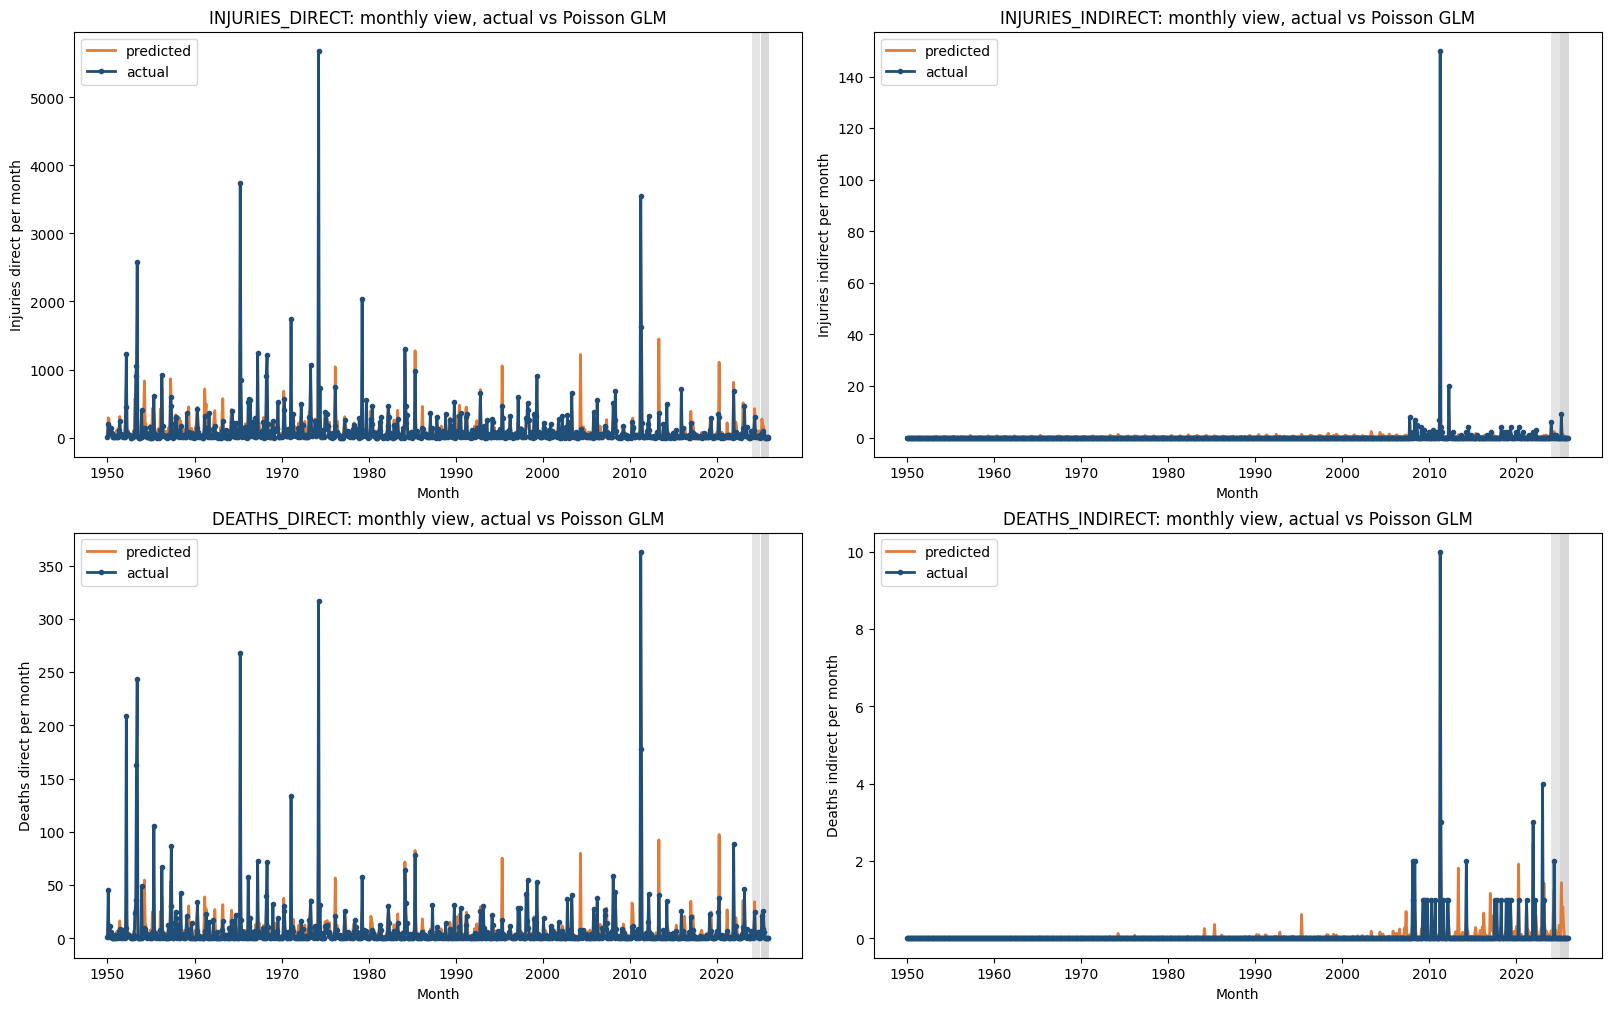

In [ ]:
target_list=['INJURIES_DIRECT','INJURIES_INDIRECT','DEATHS_DIRECT','DEATHS_INDIRECT']
plot_monthly_actual_vs_predicted(forecast_results, target_list, model='GLM')

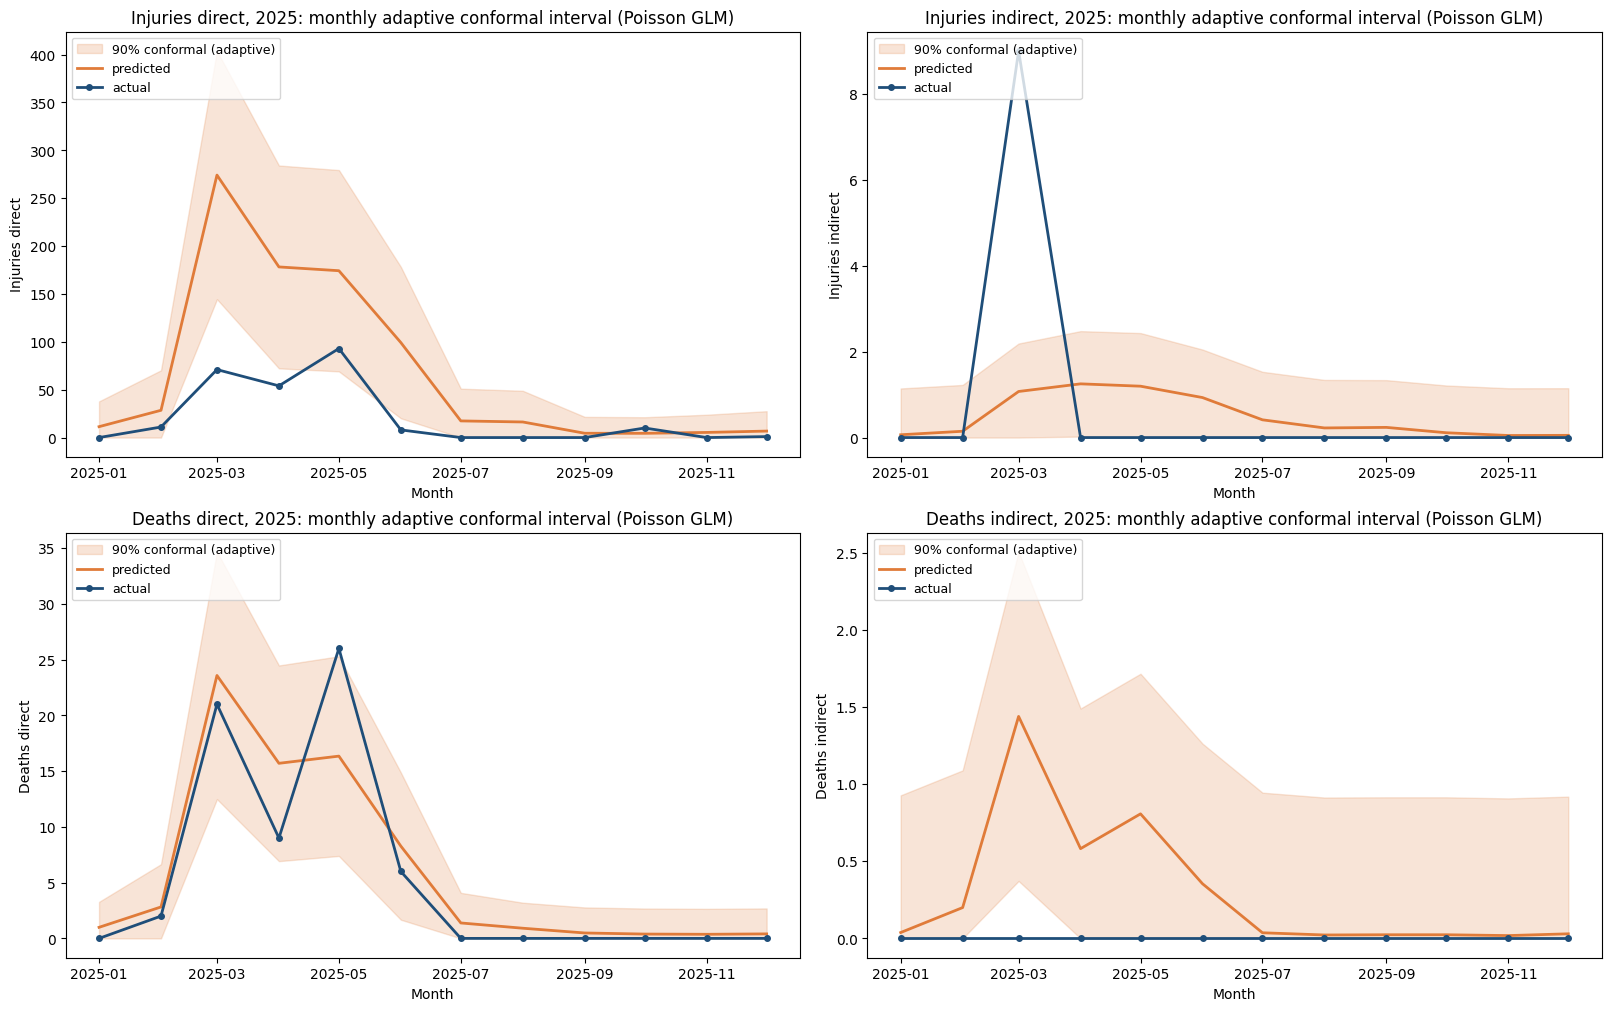

In [ ]:
plot_conformal_monthly(forecast_results, target_list, model='GLM', test_year=2025)

### Backtesting Results


 BACKTESTING FOR TARGET: INJURIES_DIRECT (Poisson GLM)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


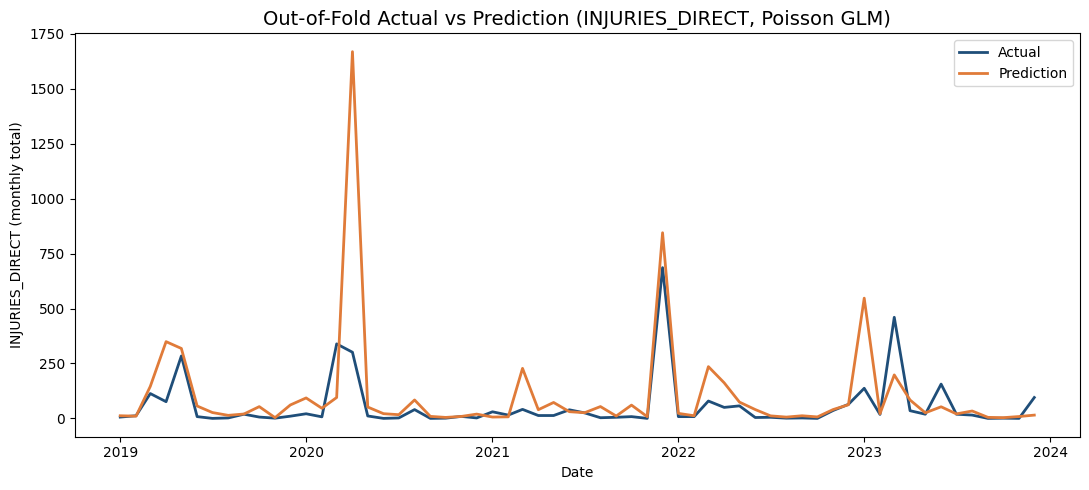

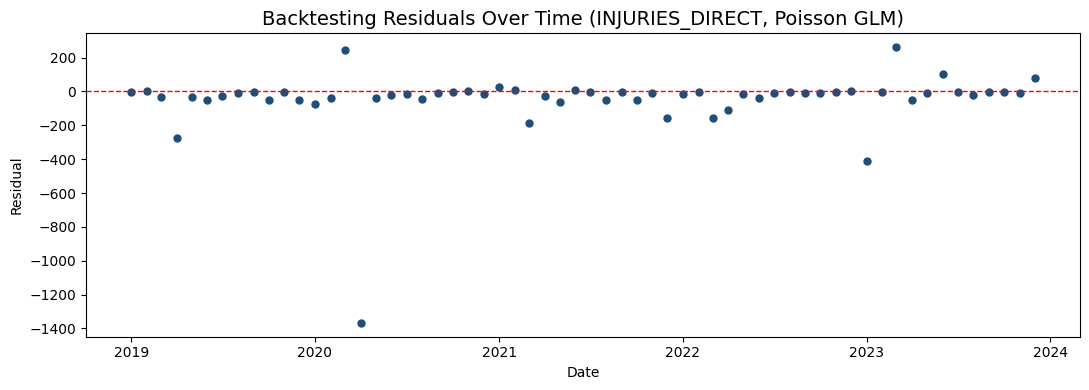

,n,events,D2,RMSE,MPD
year,,,,,
2019,2085,75,0.0316,4.4446,2.3686
2020,1517,71,0.2048,18.6075,3.3220
2021,1728,75,0.5157,7.0984,2.2651
2022,1588,76,-0.0338,1.7390,1.4920
2023,1734,97,0.2135,5.6117,3.3680


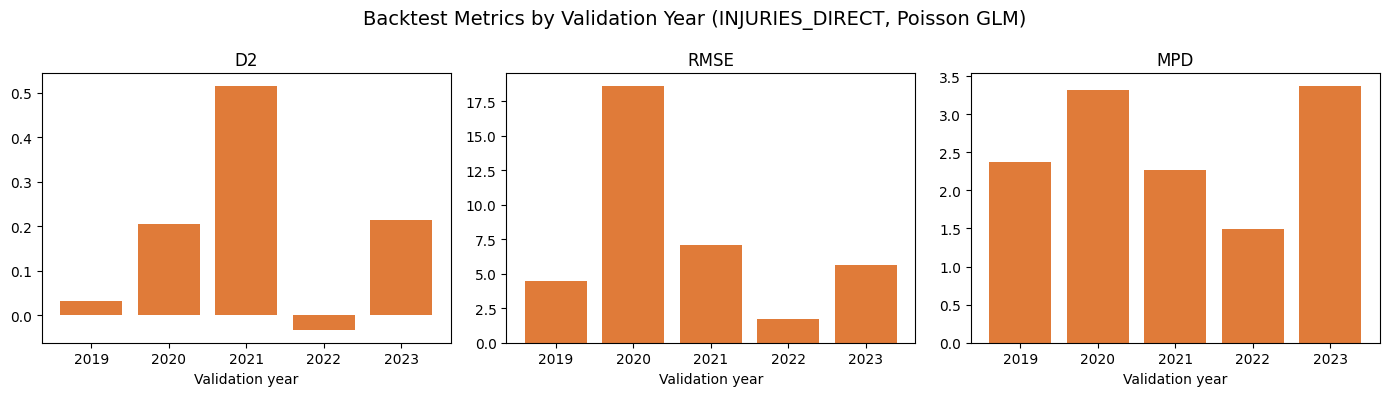

In [ ]:
backtest_target_cv(
    train_events,
    'INJURIES_DIRECT',
    params=BEST_ALPHA['INJURIES_DIRECT'],
    model='GLM',
)


 BACKTESTING FOR TARGET: INJURIES_INDIRECT (Poisson GLM)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


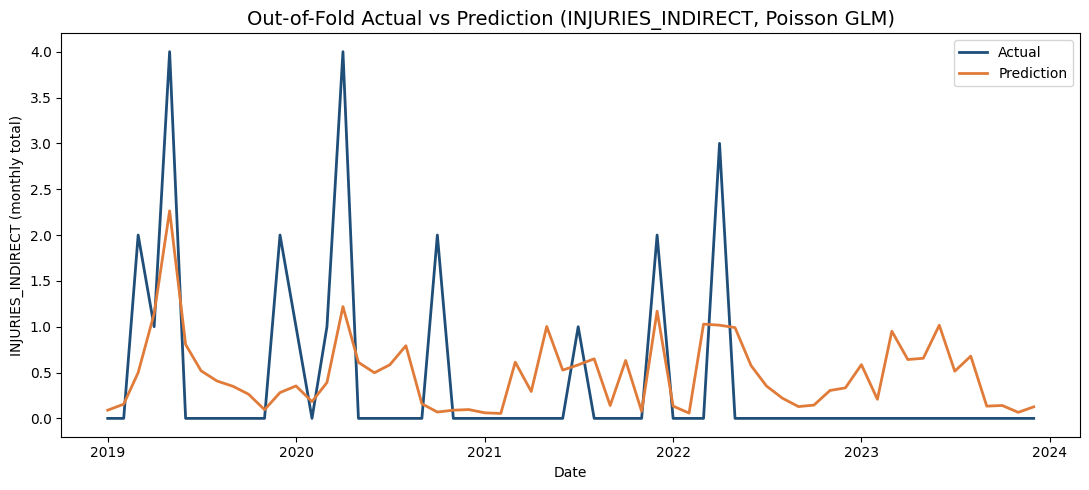

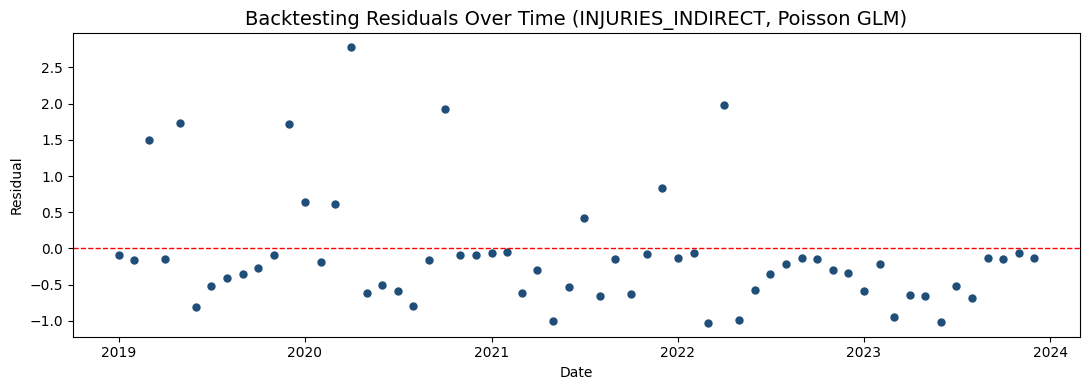

,n,events,D2,RMSE,MPD
year,,,,,
2019,2085,7,-0.0038,0.0847,0.0504
2020,1517,5,-0.0124,0.1026,0.0623
2021,1728,2,-0.0337,0.0538,0.0245
2022,1588,1,-0.0259,0.0753,0.0286
2023,1734,0,NaN,0.0033,0.0066


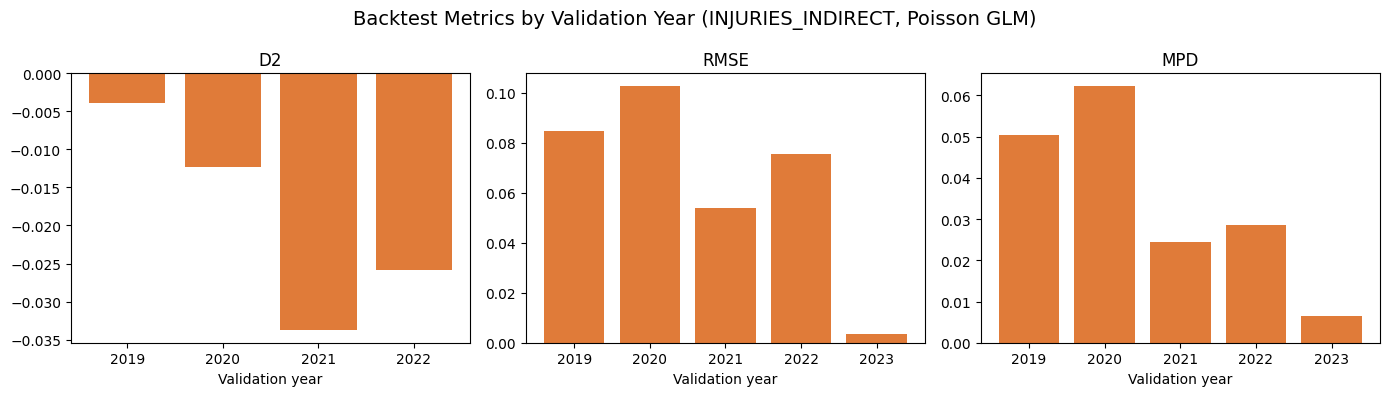

In [ ]:
backtest_target_cv(
    train_events,
    'INJURIES_INDIRECT',
    params=BEST_ALPHA['INJURIES_INDIRECT'],
    model='GLM',
)


 BACKTESTING FOR TARGET: DEATHS_DIRECT (Poisson GLM)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


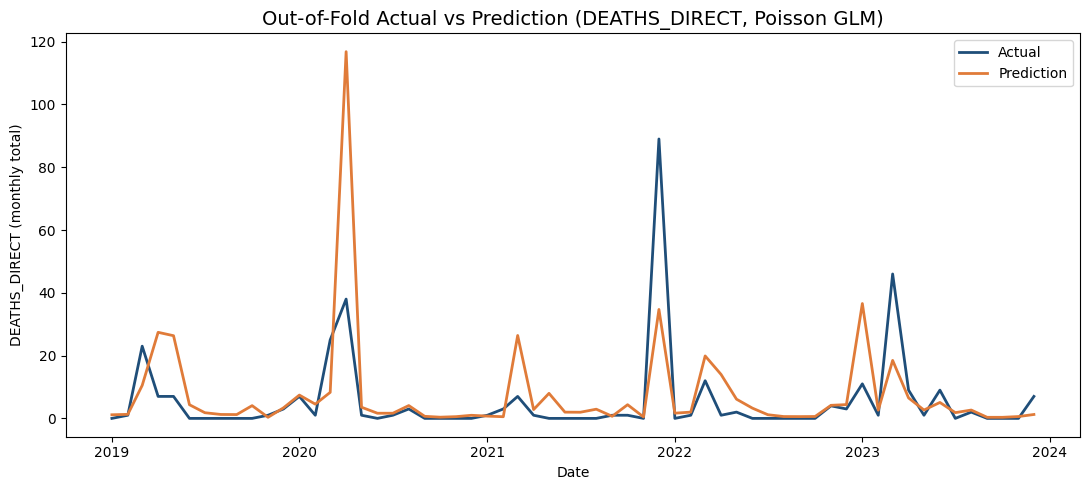

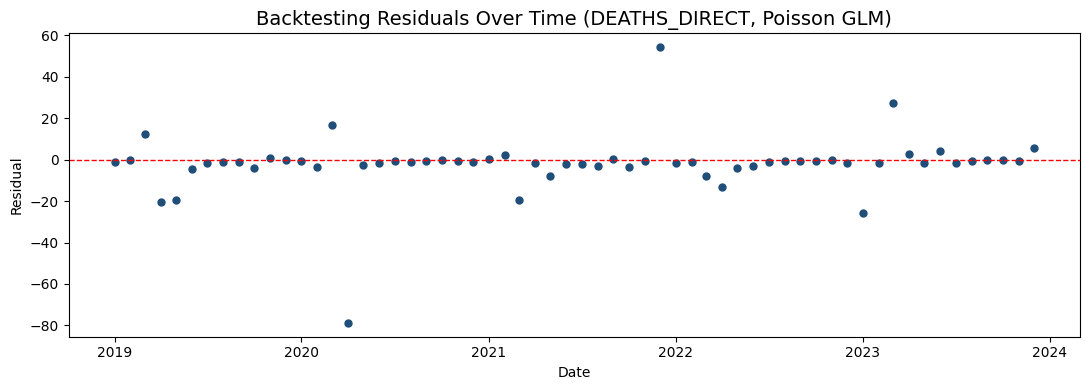

,n,events,D2,RMSE,MPD
year,,,,,
2019,2085,14,0.0917,0.5239,0.2134
2020,1517,27,0.2294,1.4136,0.3453
2021,1728,23,0.4856,0.8046,0.3055
2022,1588,14,-0.0499,0.2008,0.1503
2023,1734,31,0.3106,0.5165,0.3000


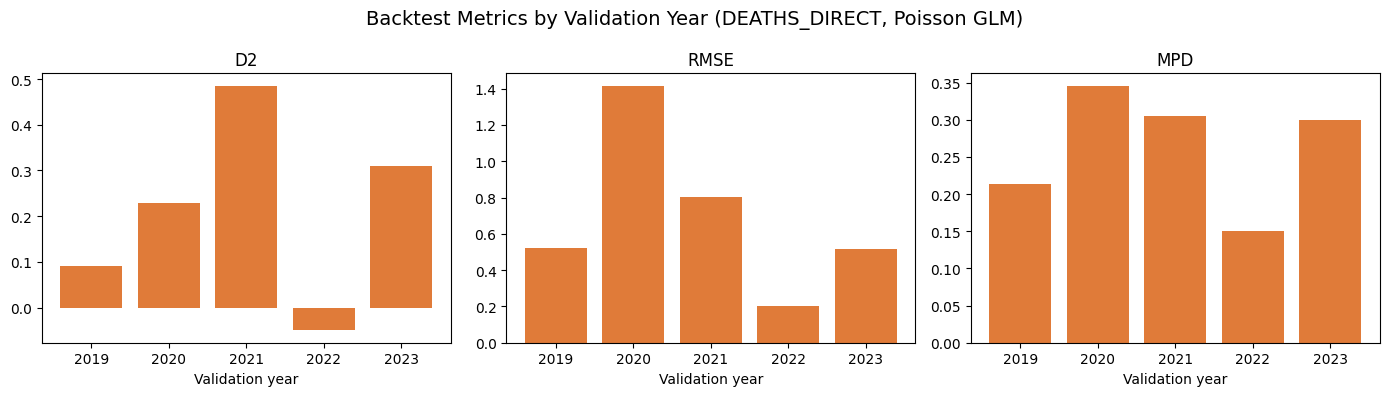

In [ ]:
backtest_target_cv(
    train_events,
    'DEATHS_DIRECT',
    params=BEST_ALPHA['DEATHS_DIRECT'],
    model='GLM',
)


 BACKTESTING FOR TARGET: DEATHS_INDIRECT (Poisson GLM)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


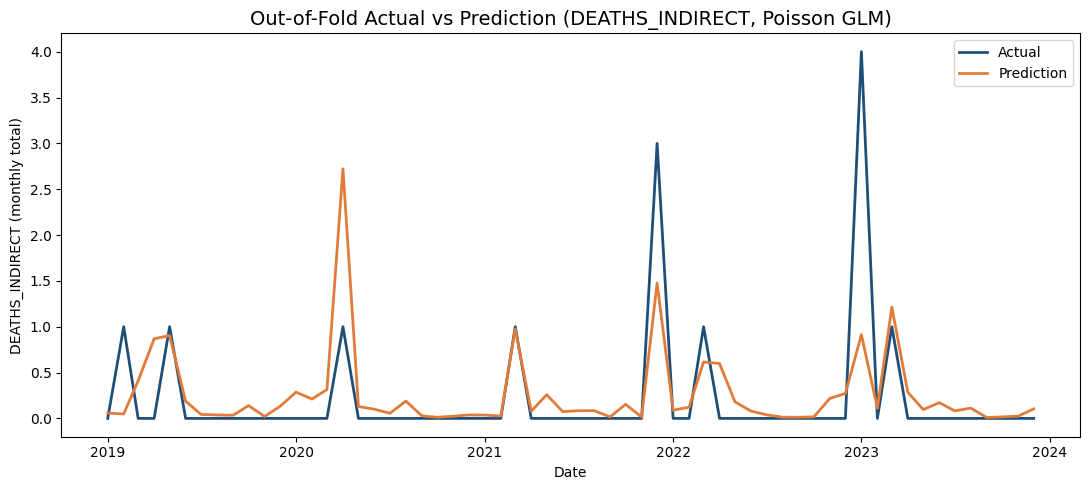

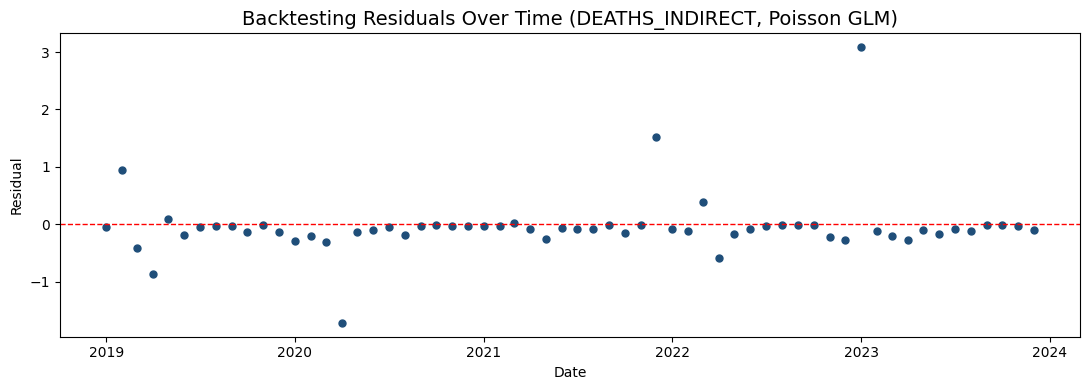

,n,events,D2,RMSE,MPD
year,,,,,
2019,2085,2,0.1216,0.0310,0.0117
2020,1517,1,0.4255,0.0254,0.0055
2021,1728,4,0.4585,0.0469,0.0152
2022,1588,1,-0.0282,0.0253,0.0095
2023,1734,5,0.3050,0.0532,0.0234


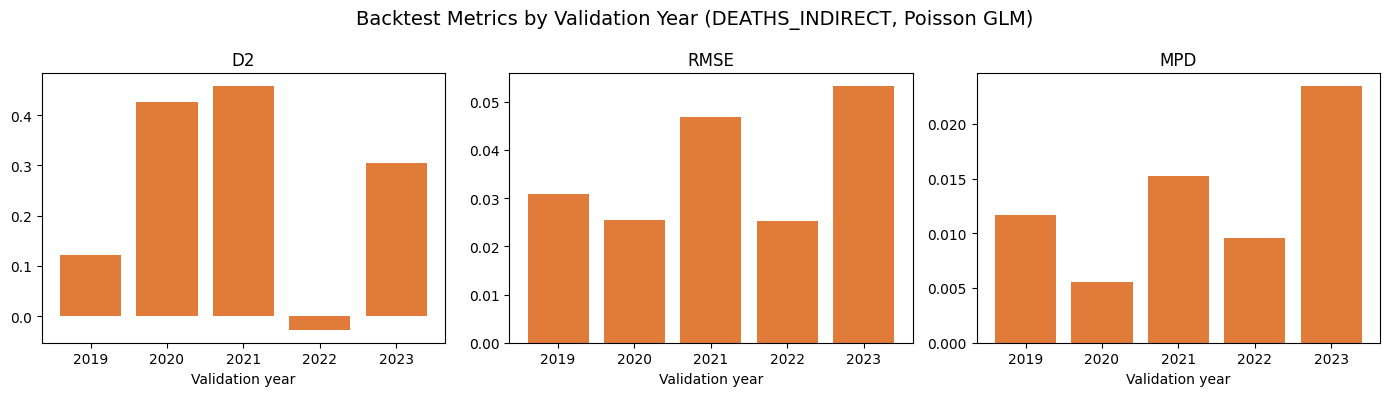

In [ ]:
backtest_target_cv(
    train_events,
    'DEATHS_INDIRECT',
    params=BEST_ALPHA['DEATHS_INDIRECT'],
    model='GLM',
)

## LightGBM

### Fine-Tuning

In [ ]:
# To recalculate BEST_PARAMETERS with the yearly expanding-window CV, uncomment and run:
#BEST_PARAMETERS_LGBM_TUNED = find_best_parameters_for_all_targets(
#      train_events,
#      FORECAST_TARGETS,
#      model='LGBM',
#      validation_years=VALIDATION_YEARS,
#      n_trials=30,
#)
#print("New BEST_PARAMETERS dictionary:", BEST_PARAMETERS_LGBM_TUNED)

Tuning LightGBM Poisson for target INJURIES_DIRECT...
Precomputing 5 folds for INJURIES_DIRECT...
  best parameters: {'n_estimators': 700, 'learning_rate': 0.010245543379918285, 'num_leaves': 126, 'min_child_samples': 276, 'subsample': 0.616807291068738, 'subsample_freq': 1, 'colsample_bytree': 0.6916843564758962, 'reg_lambda': 0.9708956739906706, 'poisson_max_delta_step': 0.09754389570758944}
Tuning LightGBM Poisson for target INJURIES_INDIRECT...
Precomputing 5 folds for INJURIES_INDIRECT...
  best parameters: {'n_estimators': 800, 'learning_rate': 0.016656892645518603, 'num_leaves': 72, 'min_child_samples': 117, 'subsample': 0.6967248772046244, 'subsample_freq': 1, 'colsample_bytree': 0.6699213122929307, 'reg_lambda': 41.50545403155786, 'poisson_max_delta_step': 0.33177606032209545}
Tuning LightGBM Poisson for target DEATHS_DIRECT...
Precomputing 5 folds for DEATHS_DIRECT...
  best parameters: {'n_estimators': 400, 'learning_rate': 0.018806941928647555, 'num_leaves': 33, 'min_child_

### Prediction

In [ ]:
LGBM_INJ_DIR = {
    'n_estimators': 700,
    'learning_rate': 0.010245543379918285,
    'num_leaves': 126,
    'min_child_samples': 276,
    'subsample': 0.616807291068738,
    'subsample_freq': 1,
    'colsample_bytree': 0.6916843564758962,
    'reg_lambda': 0.9708956739906706,
    'poisson_max_delta_step': 0.09754389570758944}

LGBM_INJ_INDIR = {
    'n_estimators': 800,
    'learning_rate': 0.016656892645518603,
    'num_leaves': 72,
    'min_child_samples': 117,
    'subsample': 0.6967248772046244,
    'subsample_freq': 1,
    'colsample_bytree': 0.6699213122929307,
    'reg_lambda': 41.50545403155786,
    'poisson_max_delta_step': 0.33177606032209545}

LGBM_DEATHS_DIR = {
    'n_estimators': 400,
    'learning_rate': 0.018806941928647555,
    'num_leaves': 33,
    'min_child_samples': 967,
    'subsample': 0.754875273545491,
    'subsample_freq': 1,
    'colsample_bytree': 0.8111617362066507,
    'reg_lambda': 1.9617712680321506,
    'poisson_max_delta_step': 0.24019109045228032}

LGBM_DEATHS_INDIR = {
    'n_estimators': 200,
    'learning_rate': 0.021569901802308007,
    'num_leaves': 19,
    'min_child_samples': 976,
    'subsample': 0.6396294461117416,
    'subsample_freq': 1,
    'colsample_bytree': 0.8036985160596606,
    'reg_lambda': 5.113423775857205,
    'poisson_max_delta_step': 0.0518396591710489}

BEST_PARAMETERS = {
    'INJURIES_DIRECT': dict(LGBM_INJ_DIR),
    'INJURIES_INDIRECT': dict(LGBM_INJ_INDIR),
    'DEATHS_DIRECT': dict(LGBM_DEATHS_DIR),
    'DEATHS_INDIRECT': dict(LGBM_DEATHS_INDIR),
}

forecast_results = build_forecast_results(
    train_events,
    calibration_events,
    test_events,
    FORECAST_TARGETS,
    best_params=BEST_PARAMETERS,
    model='LGBM',
    group_column=GROUP_COL,
)
lgbm_results = forecast_results

[LightGBM Poisson] fitting INJURIES_DIRECT...
[LightGBM Poisson] fitting INJURIES_INDIRECT...
[LightGBM Poisson] fitting DEATHS_DIRECT...
[LightGBM Poisson] fitting DEATHS_INDIRECT...


### Reporting Results

In [ ]:
display(point_metrics_by_target(forecast_results, model='LGBM').round(4))

n  events      D2    RMSE     MPD
Target            Split                                             
DEATHS_DIRECT     train        86063    1812  0.7596  0.5856  0.1620
                  calibration   2416      27  0.4342  0.2391  0.1132
                  test          1776      25  0.3467  0.4771  0.2201
DEATHS_INDIRECT   train        86063      37  0.6605  0.0324  0.0029
                  calibration   2416       2  0.1049  0.0290  0.0105
                  test          1776       0     NaN  0.0048  0.0024
INJURIES_DIRECT   train        86063    8584  0.8629  4.4860  1.1956
                  calibration   2416     100  0.4320  2.6024  1.2113
                  test          1776      74  0.1376  1.5784  0.9016
INJURIES_INDIRECT train        86063      65  0.9021  0.0540  0.0053
                  calibration   2416       4  0.0906  0.1270  0.0460
                  test          1776       2  0.4214  0.1898  0.0418

In [ ]:
display(daily_conformal_summary(forecast_results, model='LGBM').round(4))

,Days,Coverage,MeanActual,MeanWidth,RelWidth
Target,,,,,
DEATHS_DIRECT,360,0.9278,0.1778,0.3816,2.1464
DEATHS_INDIRECT,360,0.9250,0.0000,0.0150,NaN
INJURIES_DIRECT,360,0.9250,0.6889,2.4445,3.5484
INJURIES_INDIRECT,360,0.9333,0.0250,0.0323,1.2939


### Visualization Results

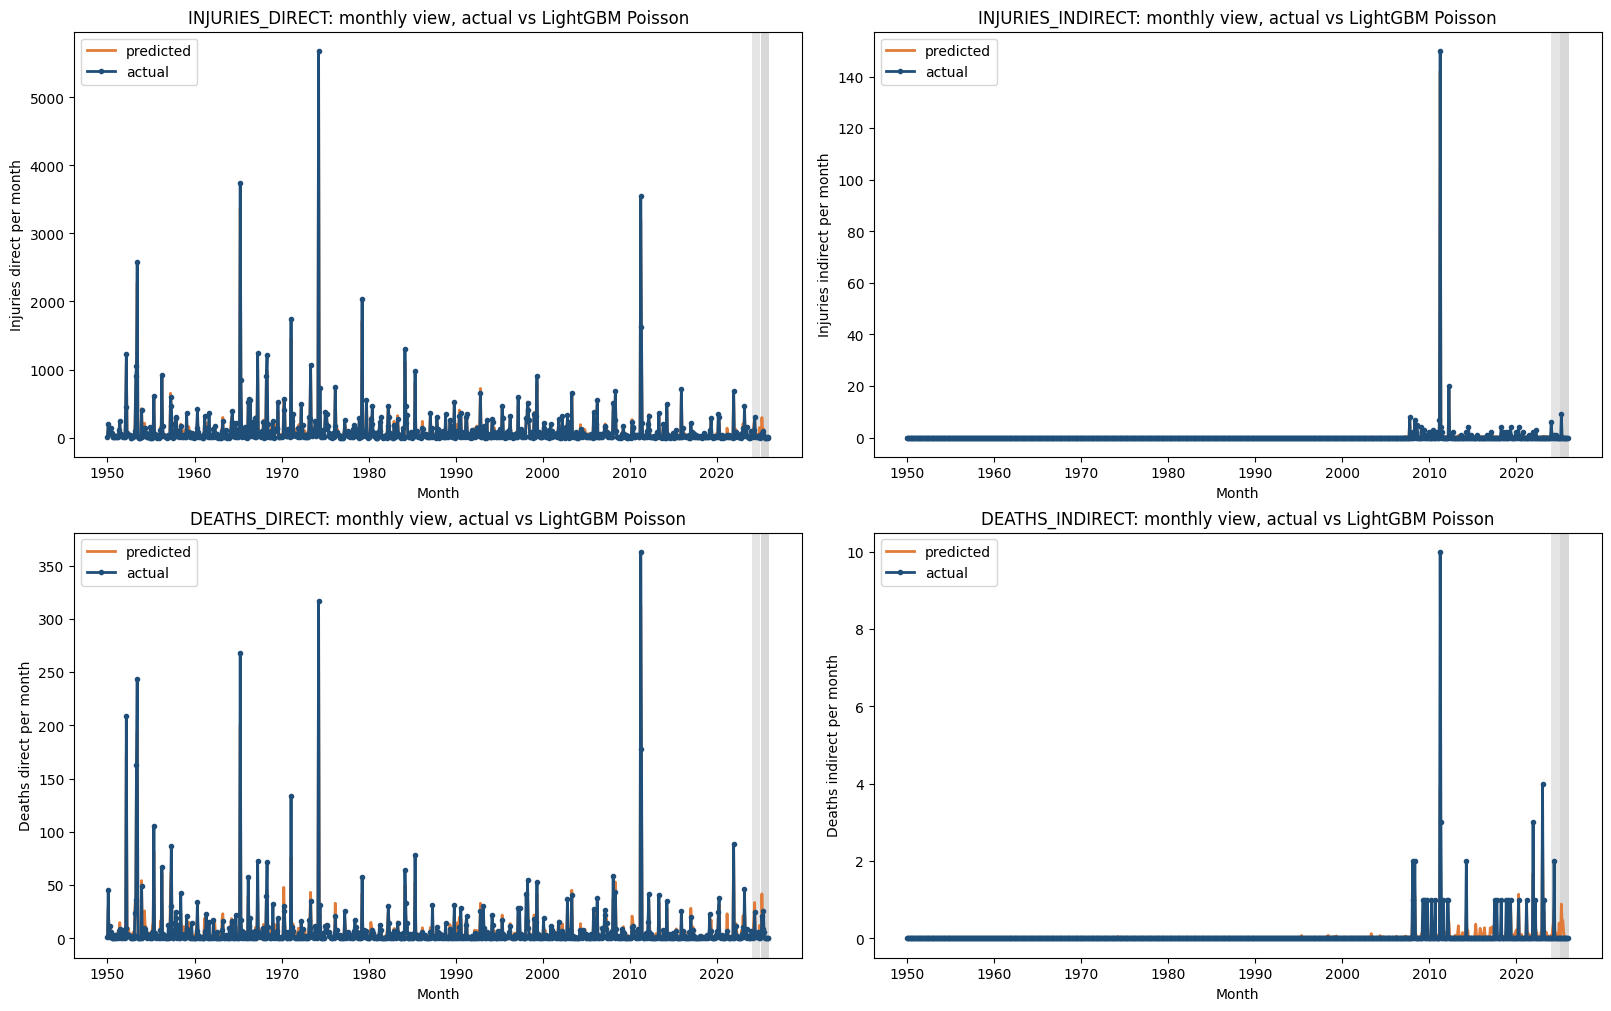

In [ ]:
target_list=['INJURIES_DIRECT','INJURIES_INDIRECT','DEATHS_DIRECT','DEATHS_INDIRECT']
plot_monthly_actual_vs_predicted(forecast_results, target_list, model='LGBM')

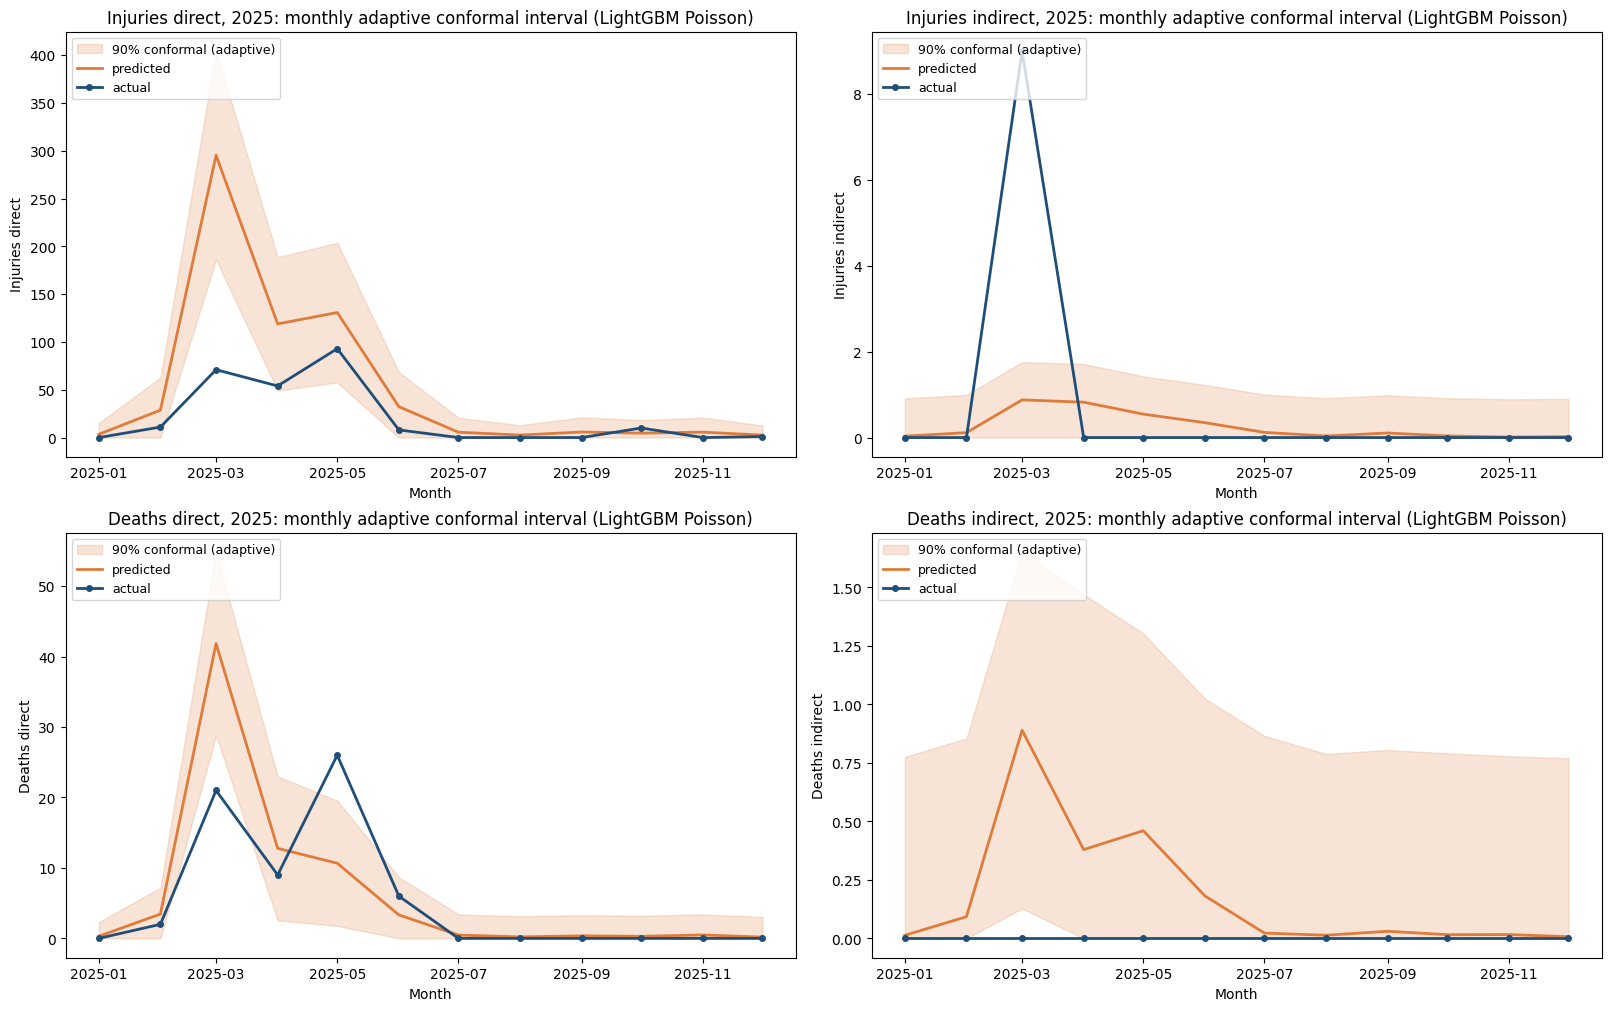

In [ ]:
plot_conformal_monthly(forecast_results, target_list, model='LGBM', test_year=2025)

### Backtesting Results


 BACKTESTING FOR TARGET: INJURIES_DIRECT (LightGBM Poisson)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


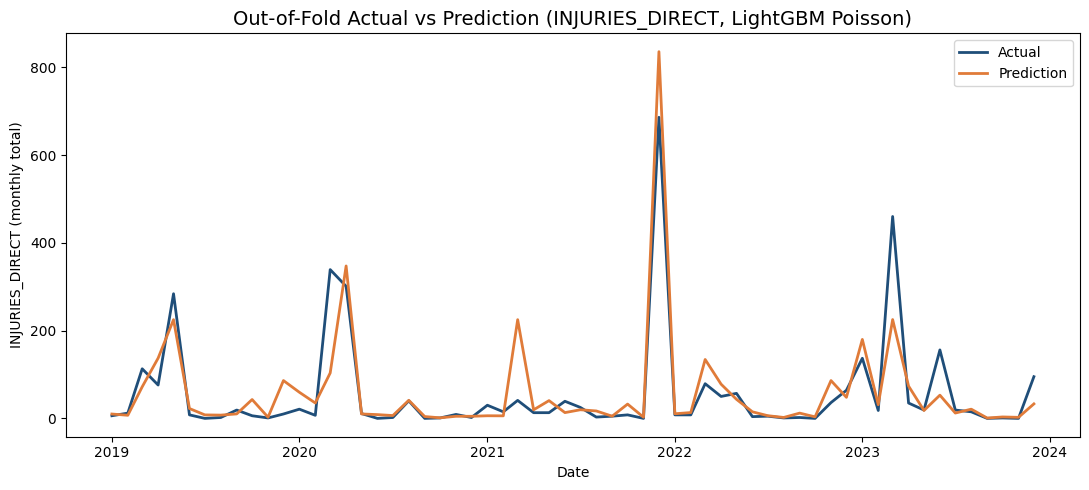

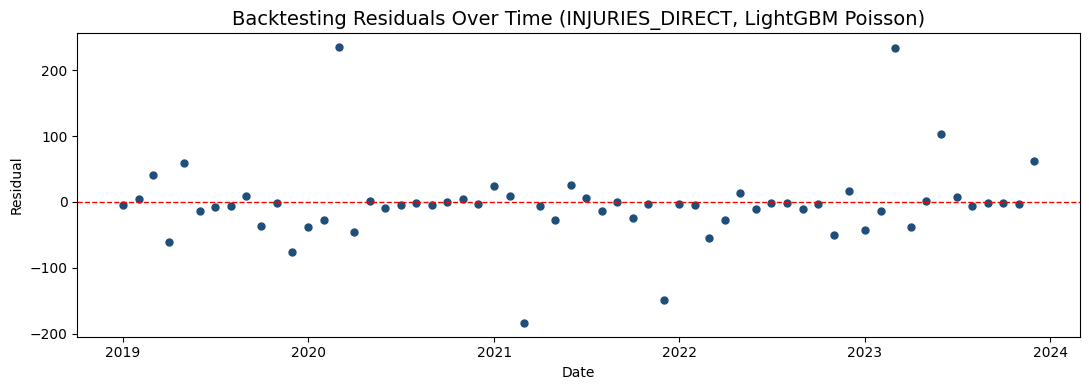

,n,events,D2,RMSE,MPD
year,,,,,
2019,2085,75,0.4737,4.0892,1.2872
2020,1517,71,0.6441,5.0609,1.4868
2021,1728,75,0.6761,5.8616,1.5149
2022,1588,76,0.4328,1.5357,0.8186
2023,1734,97,0.4580,5.1823,2.3210


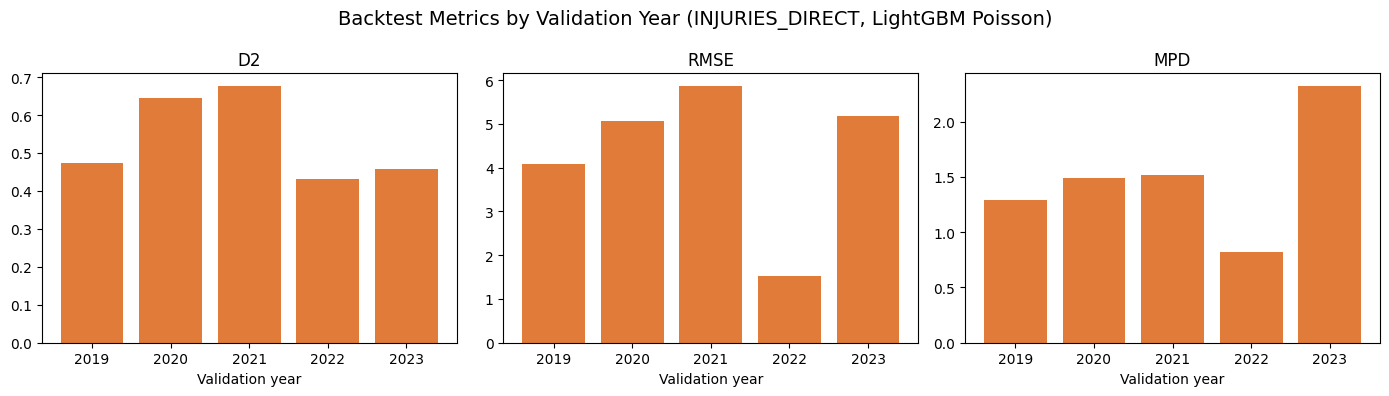

In [ ]:
backtest_target_cv(
    train_events,
    'INJURIES_DIRECT',
    params=BEST_PARAMETERS['INJURIES_DIRECT'],
    model='LGBM',
)


 BACKTESTING FOR TARGET: INJURIES_INDIRECT (LightGBM Poisson)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


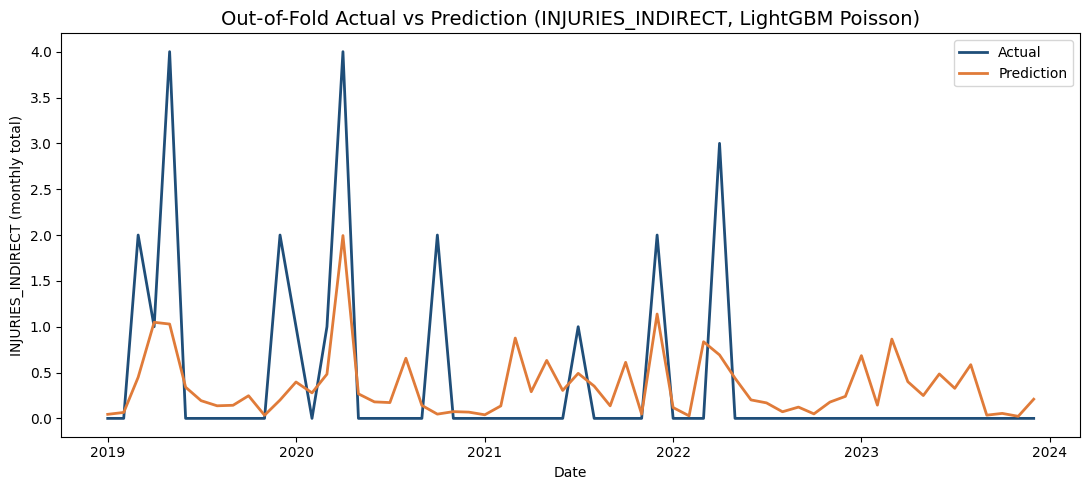

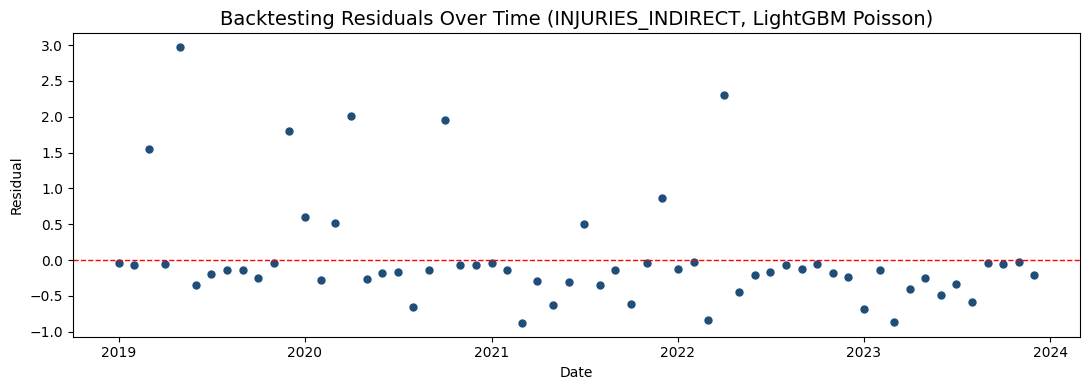

,n,events,D2,RMSE,MPD
year,,,,,
2019,2085,7,-0.0287,0.0848,0.0516
2020,1517,5,0.0351,0.1027,0.0593
2021,1728,2,0.1117,0.0541,0.0210
2022,1588,1,0.1013,0.0754,0.0250
2023,1734,0,NaN,0.0059,0.0047


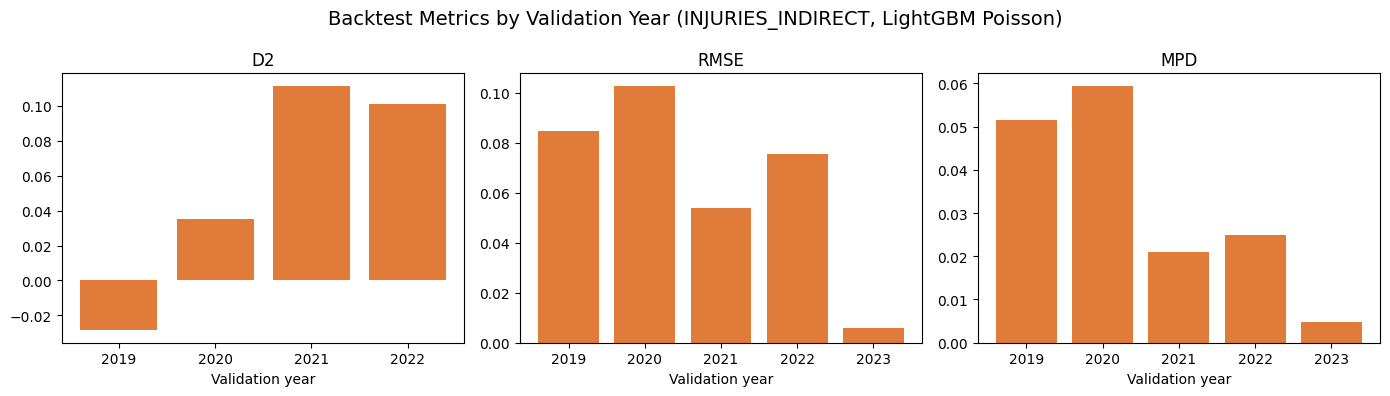

In [ ]:
backtest_target_cv(
    train_events,
    'INJURIES_INDIRECT',
    params=BEST_PARAMETERS['INJURIES_INDIRECT'],
    model='LGBM',
)


 BACKTESTING FOR TARGET: DEATHS_DIRECT (LightGBM Poisson)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


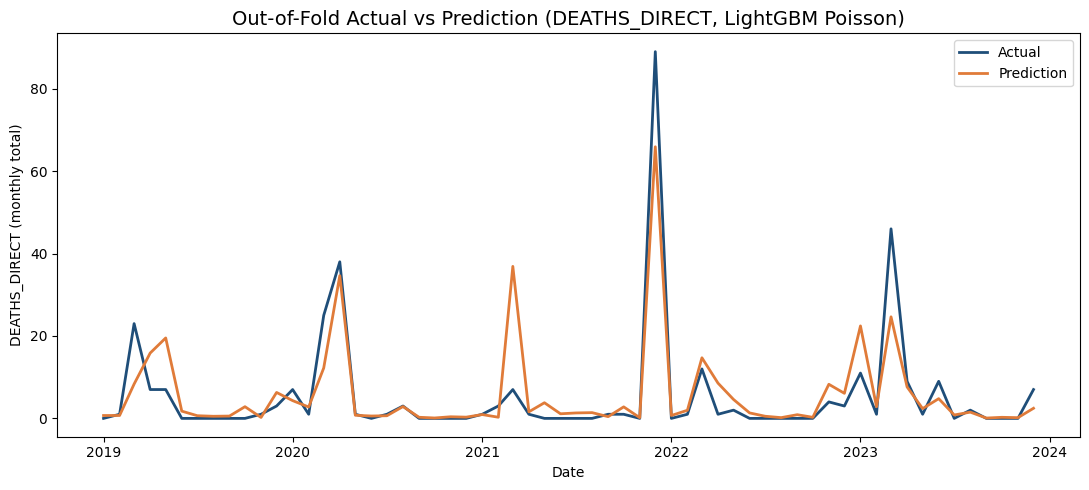

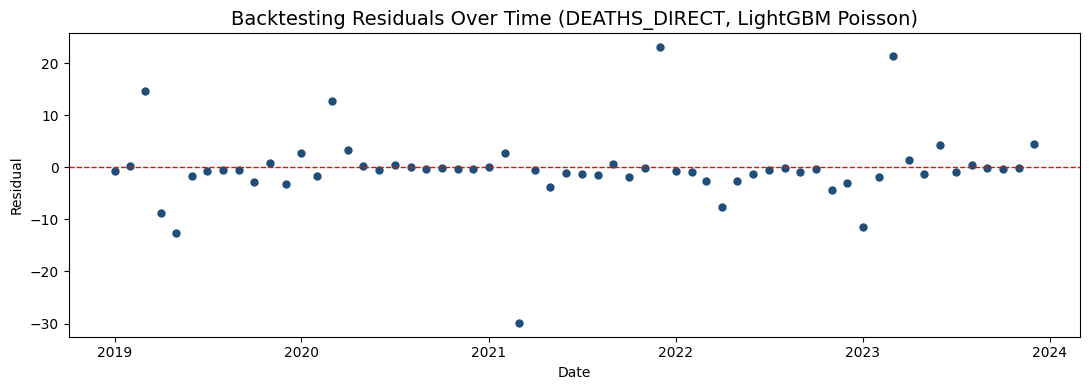

,n,events,D2,RMSE,MPD
year,,,,,
2019,2085,14,0.4399,0.5039,0.1316
2020,1517,27,0.4952,0.5633,0.2262
2021,1728,23,0.6278,0.7626,0.2210
2022,1588,14,0.2503,0.2091,0.1074
2023,1734,31,0.4882,0.5078,0.2227


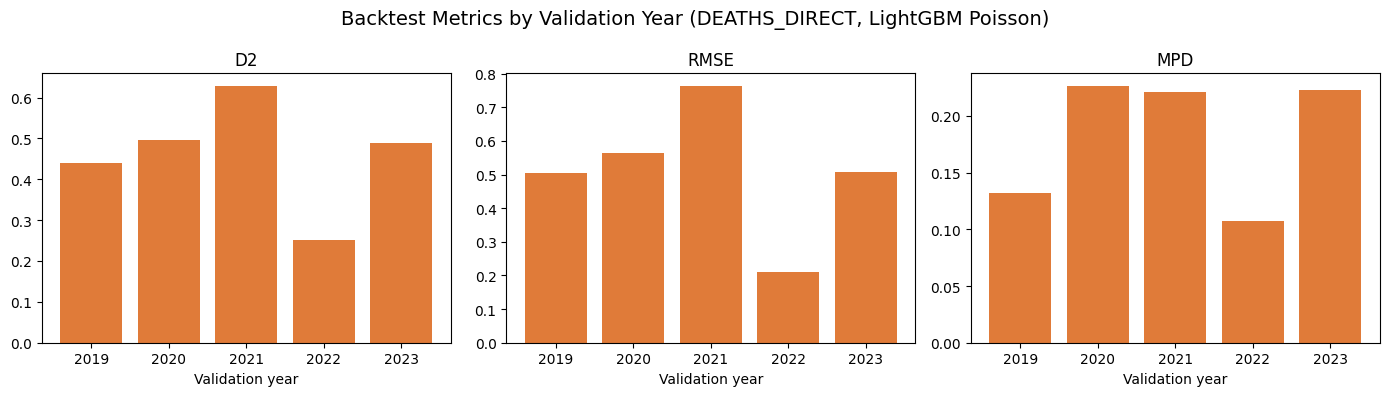

In [ ]:
backtest_target_cv(
    train_events,
    'DEATHS_DIRECT',
    params=BEST_PARAMETERS['DEATHS_DIRECT'],
    model='LGBM',
)


 BACKTESTING FOR TARGET: DEATHS_INDIRECT (LightGBM Poisson)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


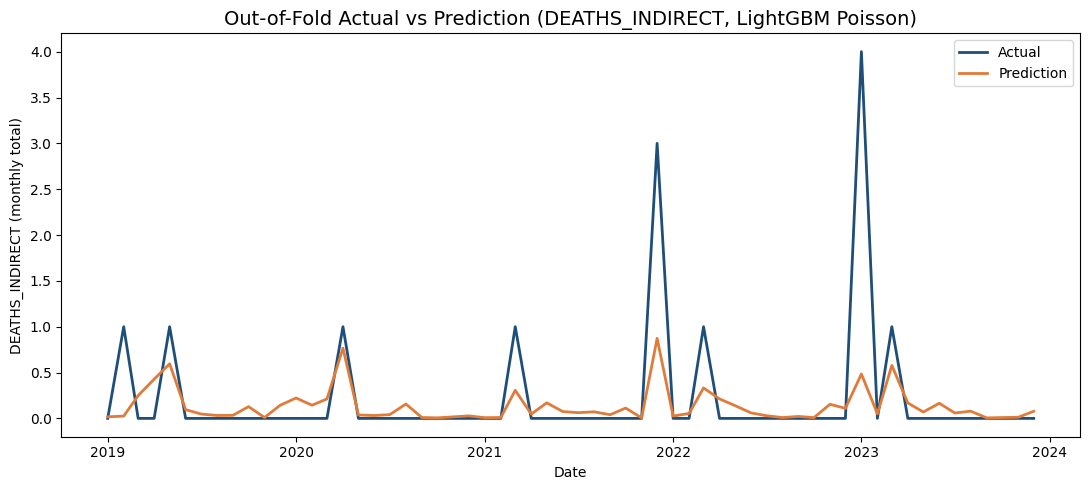

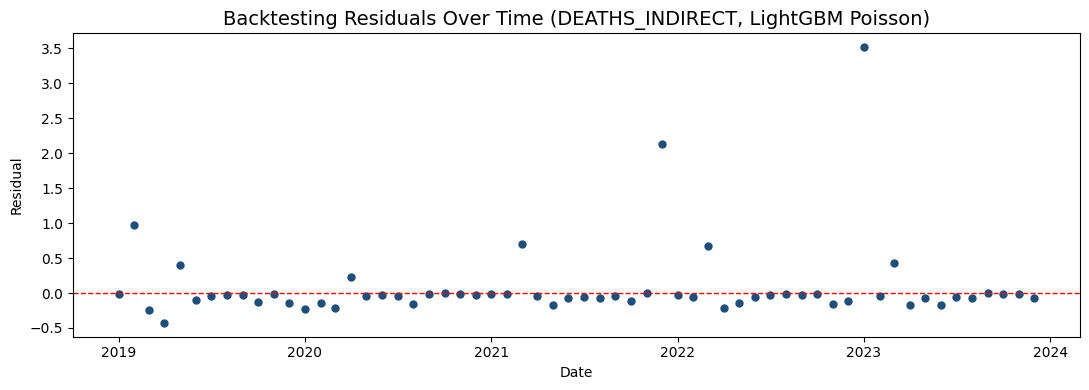

,n,events,D2,RMSE,MPD
year,,,,,
2019,2085,2,0.3777,0.0305,0.0083
2020,1517,1,0.1724,0.0260,0.0080
2021,1728,4,0.4651,0.0472,0.0150
2022,1588,1,-0.0035,0.0252,0.0093
2023,1734,5,0.1878,0.0536,0.0274


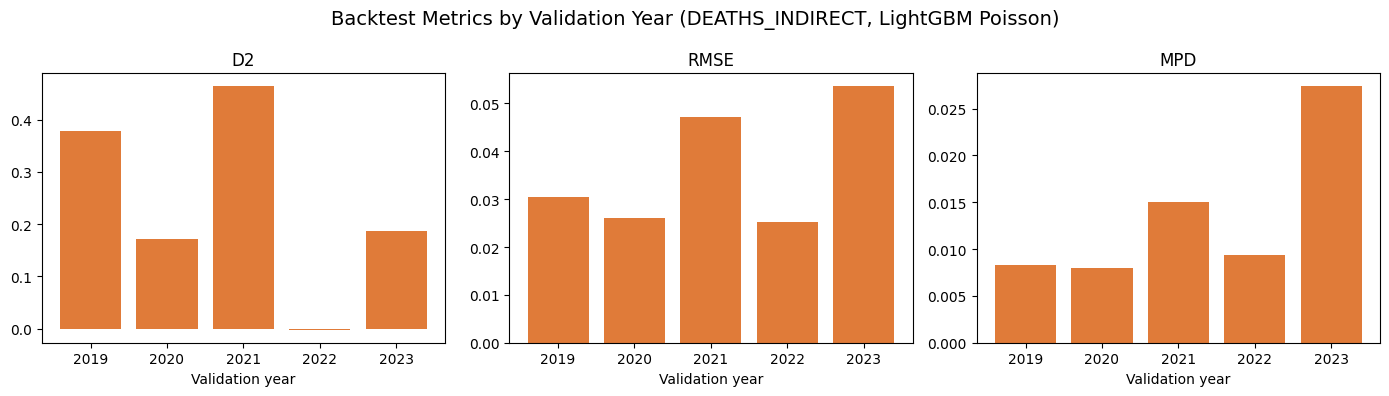

In [ ]:
backtest_target_cv(
    train_events,
    'DEATHS_INDIRECT',
    params=BEST_PARAMETERS['DEATHS_INDIRECT'],
    model='LGBM',
)

## LSTM

### Fine-Tuning

In [ ]:
# To recalculate BEST_PARAMETERS_LSTM with the yearly expanding-window CV, uncomment and run:
#BEST_PARAMETERS_LSTM_TUNED = find_best_parameters_for_all_targets(
#      train_events,
#      FORECAST_TARGETS,
#      model='LSTM',
#      validation_years=VALIDATION_YEARS,
#      n_trials=15,
#)
#print("New BEST_PARAMETERS_LSTM dictionary:", BEST_PARAMETERS_LSTM_TUNED)

Tuning LSTM Poisson for target INJURIES_DIRECT...
Precomputing 5 folds for INJURIES_DIRECT...
  best parameters: {'sequence_length': 4, 'sequence_by': None, 'units': 16, 'dropout': 0.26299026343992205, 'learning_rate': 0.009489339755504058, 'epochs': 10, 'batch_size': 256, 'verbose': 0}
Tuning LSTM Poisson for target INJURIES_INDIRECT...
Precomputing 5 folds for INJURIES_INDIRECT...
  best parameters: {'sequence_length': 10, 'sequence_by': None, 'units': 64, 'dropout': 0.23625431936284402, 'learning_rate': 0.00010224038159981541, 'epochs': 3, 'batch_size': 1024, 'verbose': 0}
Tuning LSTM Poisson for target DEATHS_DIRECT...
Precomputing 5 folds for DEATHS_DIRECT...
  best parameters: {'sequence_length': 3, 'sequence_by': None, 'units': 16, 'dropout': 0.2858334782580346, 'learning_rate': 0.007232371232294039, 'epochs': 10, 'batch_size': 256, 'verbose': 0}
Tuning LSTM Poisson for target DEATHS_INDIRECT...
Precomputing 5 folds for DEATHS_INDIRECT...
  best parameters: {'sequence_length': 9

### Prediction

In [ ]:
LSTM_INJ_DIR = {
    'sequence_length': 4,
    'sequence_by': None,
    'units': 16,
    'dropout': 0.26299026343992205,
    'learning_rate': 0.009489339755504058,
    'epochs': 10,
    'batch_size': 256,
    'verbose': 0
}

LSTM_INJ_INDIR = {
    'sequence_length': 10,
    'sequence_by': None,
    'units': 64,
    'dropout': 0.23625431936284402,
    'learning_rate': 0.00010224038159981541,
    'epochs': 3,
    'batch_size': 1024,
    'verbose': 0
}

LSTM_DEATHS_DIR = {
    'sequence_length': 3,
    'sequence_by': None,
    'units': 16,
    'dropout': 0.2858334782580346,
    'learning_rate': 0.007232371232294039,
    'epochs': 10,
    'batch_size': 256,
    'verbose': 0
}

LSTM_DEATHS_INDIR = {
    'sequence_length': 9,
    'sequence_by': None,
    'units': 16,
    'dropout': 0.18223253279942547,
    'learning_rate': 0.004922076774969921,
    'epochs': 4,
    'batch_size': 256,
    'verbose': 0
}

BEST_PARAMETERS_LSTM = {
    'INJURIES_DIRECT': dict(LSTM_INJ_DIR),
    'INJURIES_INDIRECT': dict(LSTM_INJ_INDIR),
    'DEATHS_DIRECT': dict(LSTM_DEATHS_DIR),
    'DEATHS_INDIRECT': dict(LSTM_DEATHS_INDIR),
}

forecast_results = build_forecast_results(
    train_events,
    calibration_events,
    test_events,
    FORECAST_TARGETS,
    best_params=BEST_PARAMETERS_LSTM,
    model='LSTM',
    group_column=GROUP_COL,
)
lstm_results = forecast_results

[LSTM Poisson] fitting INJURIES_DIRECT...
[LSTM Poisson] fitting INJURIES_INDIRECT...
[LSTM Poisson] fitting DEATHS_DIRECT...
[LSTM Poisson] fitting DEATHS_INDIRECT...


### Reporting Results

In [ ]:
display(point_metrics_by_target(forecast_results, model='LSTM').round(4))

n  events      D2     RMSE     MPD
Target            Split                                              
DEATHS_DIRECT     train        86063    1812  0.5946   0.9770  0.2732
                  calibration   2416      27  0.3972   0.2437  0.1206
                  test          1776      25  0.2453   0.4800  0.2543
DEATHS_INDIRECT   train        86063      37  0.5191   0.0346  0.0041
                  calibration   2416       2  0.1459   0.0288  0.0100
                  test          1776       0     NaN   0.0018  0.0016
INJURIES_DIRECT   train        86063    8584  0.5880  13.2978  3.5922
                  calibration   2416     100  0.3293   2.5537  1.4302
                  test          1776      74  0.1148   1.7025  0.9254
INJURIES_INDIRECT train        86063      65  0.0699   0.3502  0.0500
                  calibration   2416       4  0.0254   0.1270  0.0493
                  test          1776       2  0.0561   0.1912  0.0682

In [ ]:
display(daily_conformal_summary(forecast_results, model='LSTM').round(4))

,Days,Coverage,MeanActual,MeanWidth,RelWidth
Target,,,,,
DEATHS_DIRECT,360,0.9222,0.1778,0.3393,1.9085
DEATHS_INDIRECT,360,0.9333,0.0000,0.0126,NaN
INJURIES_DIRECT,360,0.9222,0.6889,2.6116,3.7911
INJURIES_INDIRECT,360,0.9389,0.0250,0.1182,4.7278


### Visualization Results

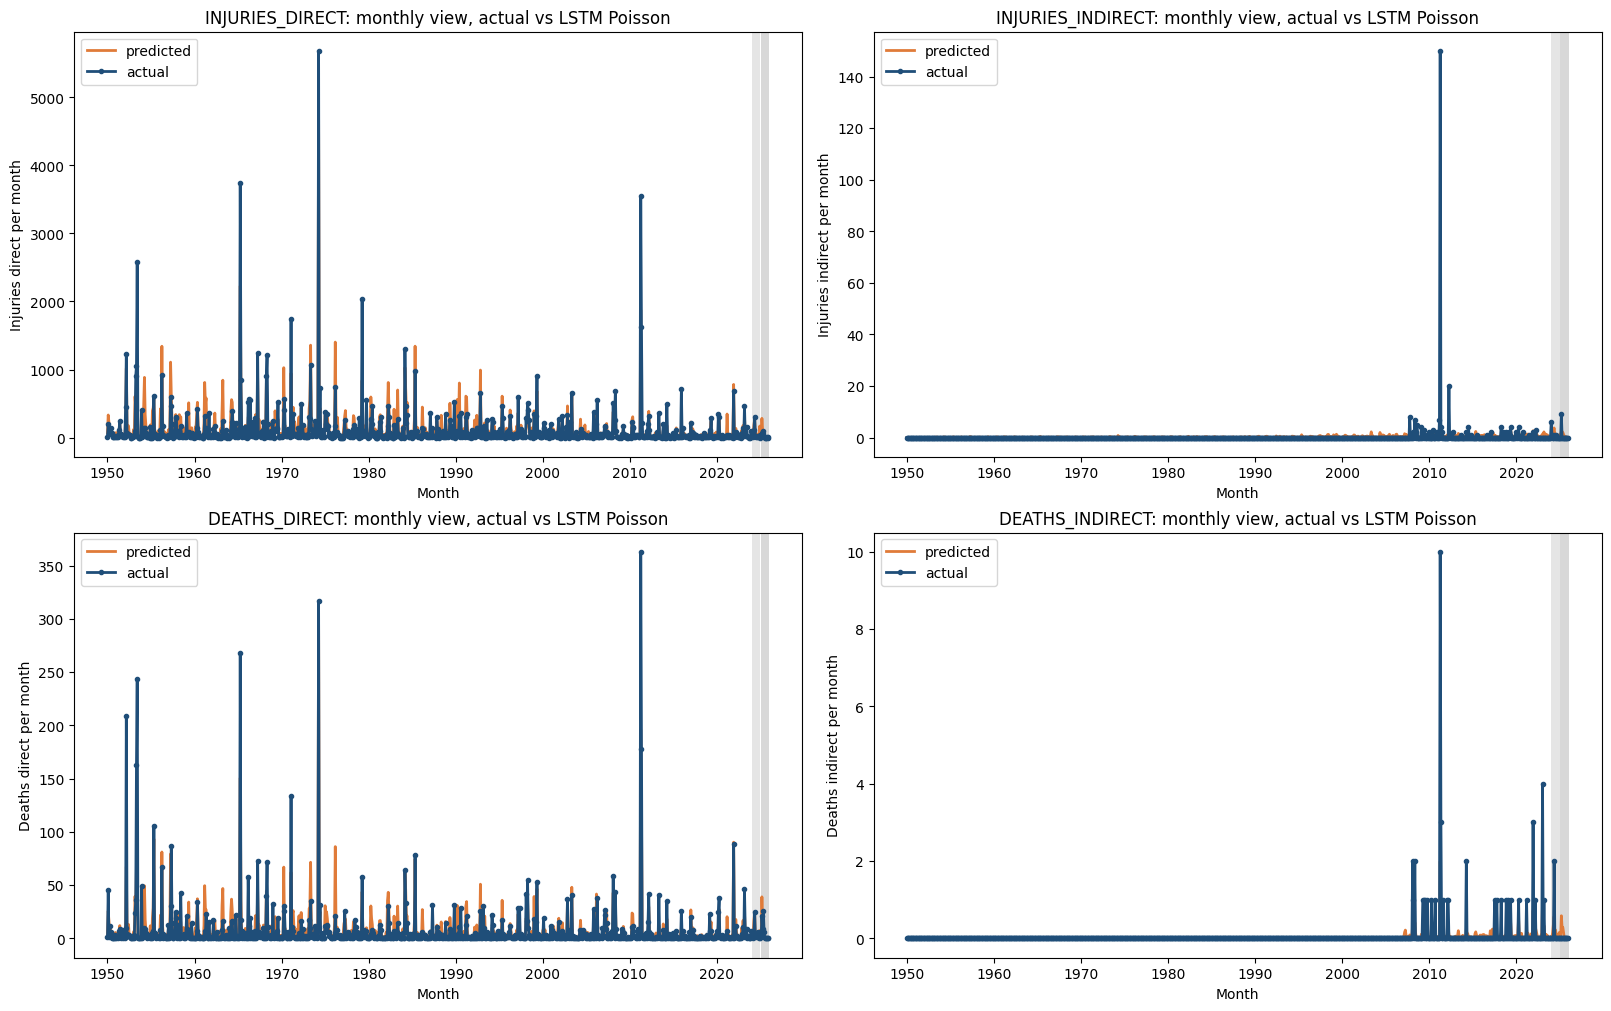

In [ ]:
target_list=['INJURIES_DIRECT','INJURIES_INDIRECT','DEATHS_DIRECT','DEATHS_INDIRECT']
plot_monthly_actual_vs_predicted(forecast_results, target_list, model='LSTM')

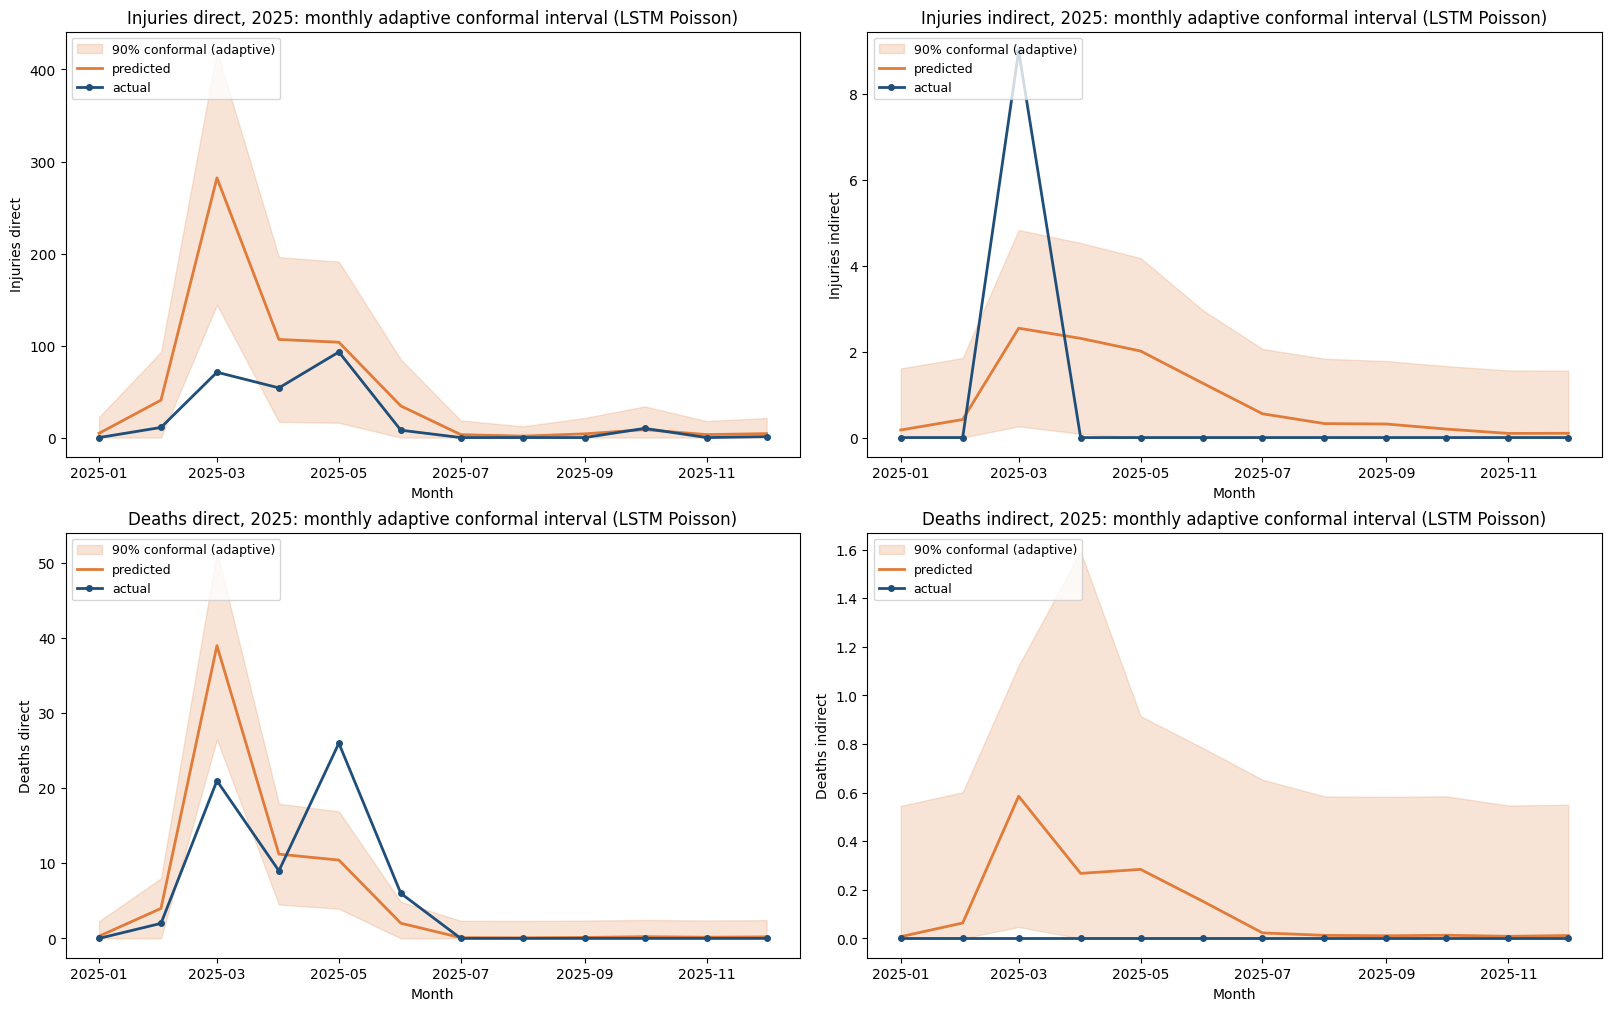

In [ ]:
plot_conformal_monthly(forecast_results, target_list, model='LSTM', test_year=2025)

### Backtesting Results



 BACKTESTING FOR TARGET: INJURIES_DIRECT (LSTM Poisson)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


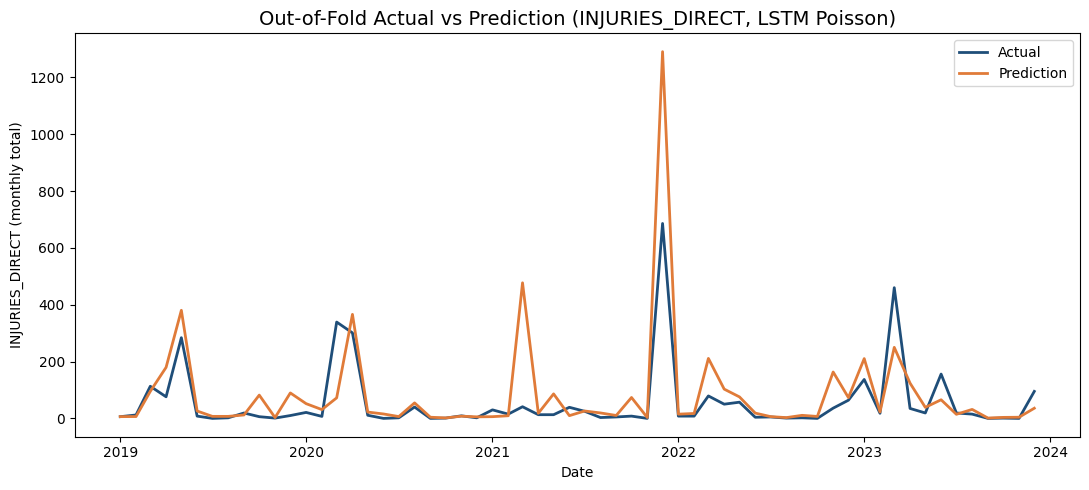

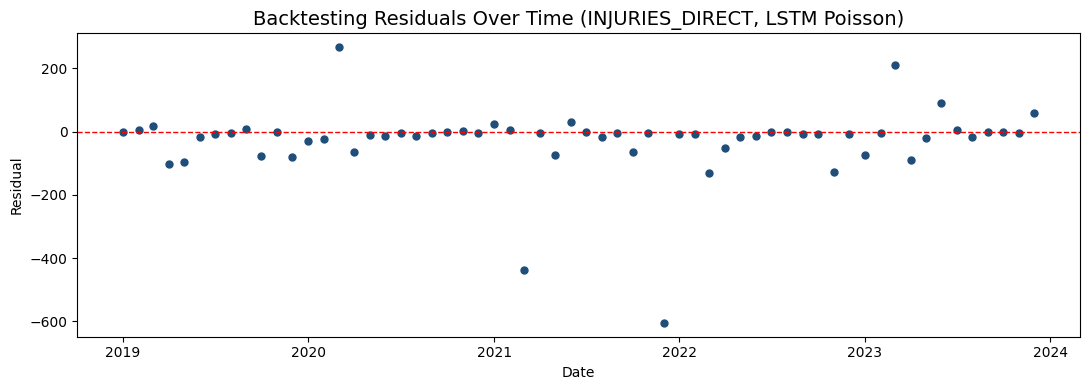

,n,events,D2,RMSE,MPD
year,,,,,
2019,2085,75,0.3940,4.3129,1.4821
2020,1517,71,0.5699,5.3939,1.7968
2021,1728,75,0.5107,7.3683,2.2888
2022,1588,76,0.2151,2.0944,1.1328
2023,1734,97,0.3803,5.2944,2.6537


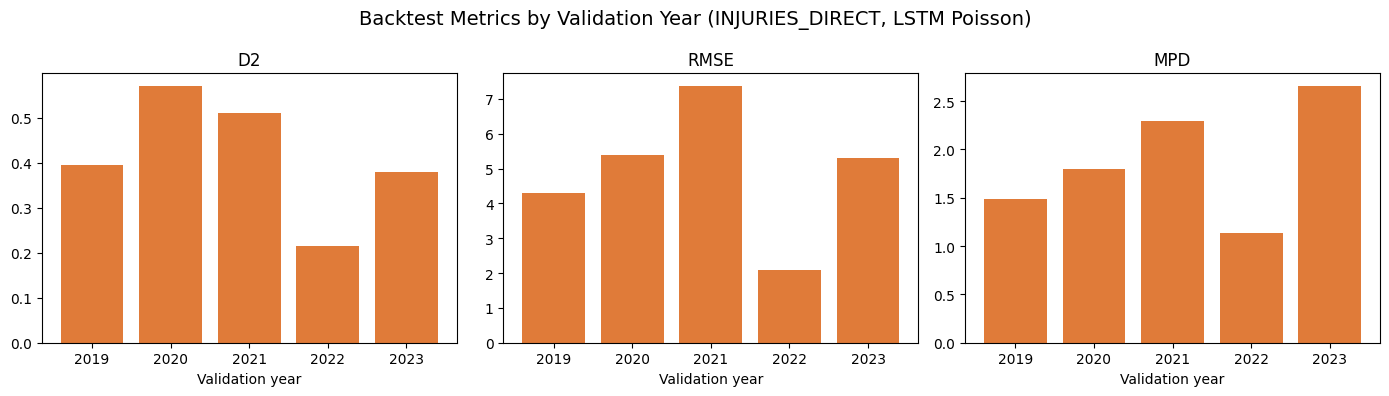

In [ ]:
backtest_target_cv(
    train_events,
    'INJURIES_DIRECT',
    params=BEST_PARAMETERS_LSTM['INJURIES_DIRECT'],
    model='LSTM',
)


 BACKTESTING FOR TARGET: INJURIES_INDIRECT (LSTM Poisson)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


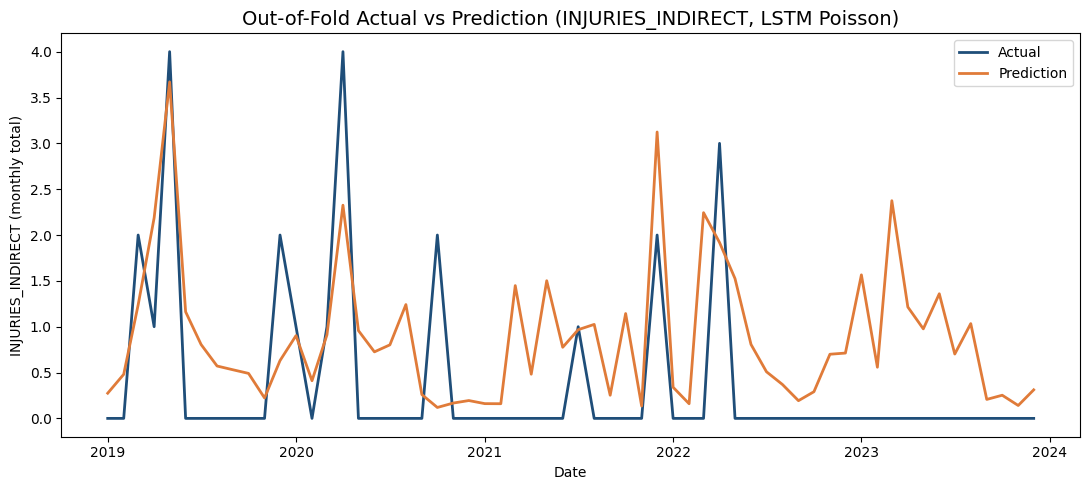

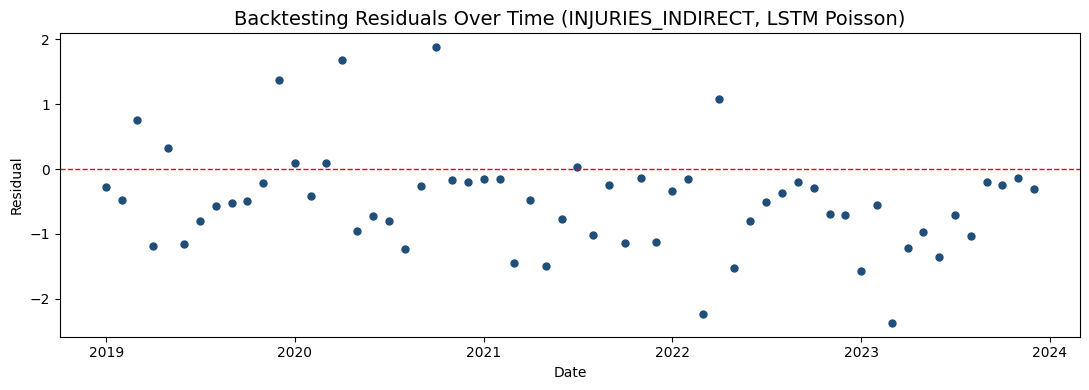

,n,events,D2,RMSE,MPD
year,,,,,
2019,2085,7,-0.0029,0.0847,0.0503
2020,1517,5,-0.0068,0.1026,0.0619
2021,1728,2,-0.1999,0.0540,0.0284
2022,1588,1,-0.1690,0.0754,0.0326
2023,1734,0,NaN,0.0065,0.0123


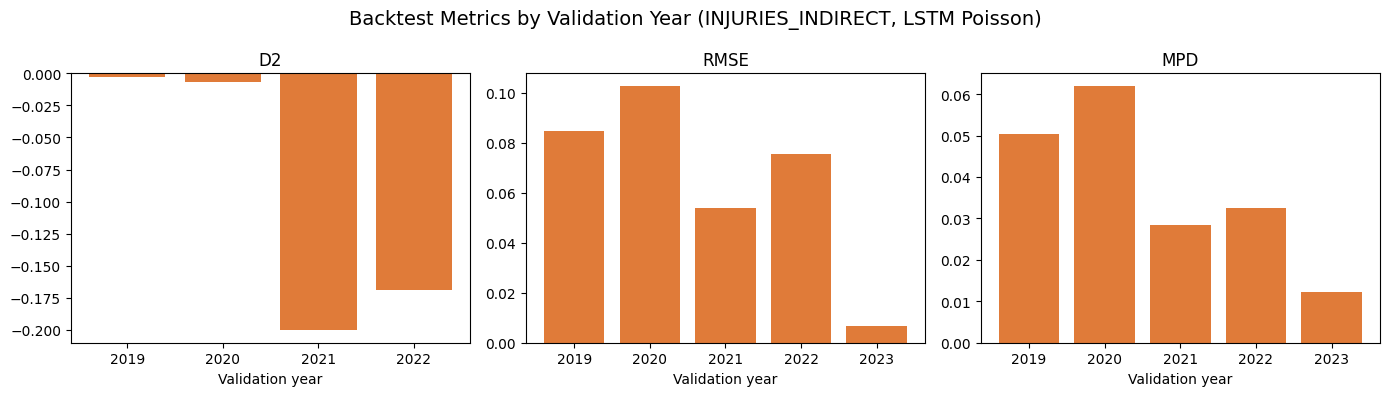

In [ ]:
backtest_target_cv(
    train_events,
    'INJURIES_INDIRECT',
    params=BEST_PARAMETERS_LSTM['INJURIES_INDIRECT'],
    model='LSTM',
)


 BACKTESTING FOR TARGET: DEATHS_DIRECT (LSTM Poisson)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


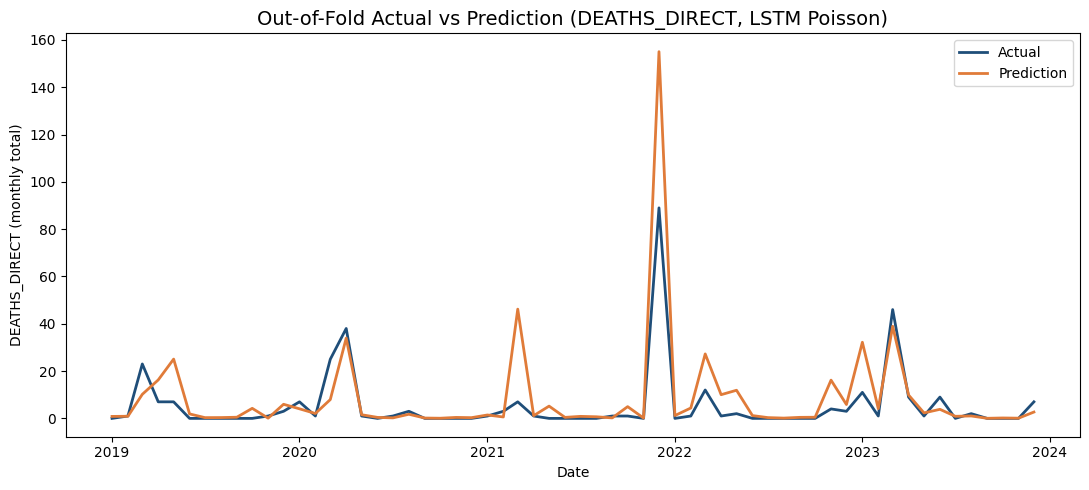

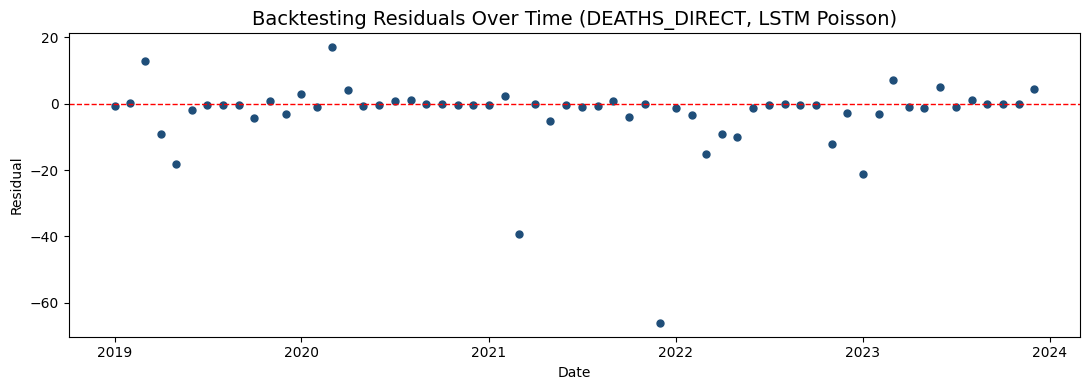

,n,events,D2,RMSE,MPD
year,,,,,
2019,2085,14,0.3918,0.5057,0.1429
2020,1517,27,0.4515,0.5724,0.2458
2021,1728,23,0.5442,0.9244,0.2707
2022,1588,14,0.1637,0.2696,0.1198
2023,1734,31,0.4899,0.4826,0.2220


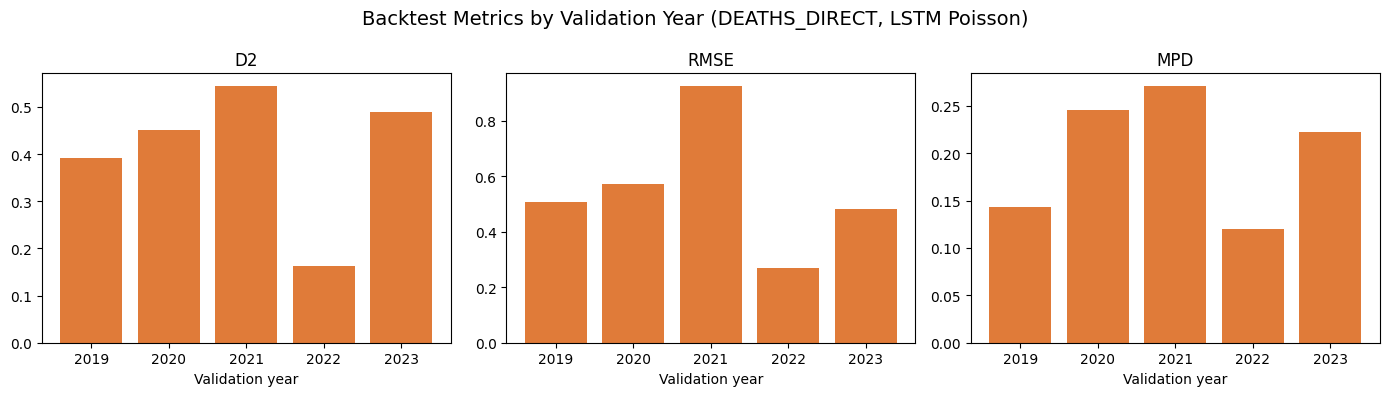

In [ ]:
backtest_target_cv(
    train_events,
    'DEATHS_DIRECT',
    params=BEST_PARAMETERS_LSTM['DEATHS_DIRECT'],
    model='LSTM',
)


 BACKTESTING FOR TARGET: DEATHS_INDIRECT (LSTM Poisson)
Fold 1: train <= 2018, validation = 2019
Fold 2: train <= 2019, validation = 2020
Fold 3: train <= 2020, validation = 2021
Fold 4: train <= 2021, validation = 2022
Fold 5: train <= 2022, validation = 2023


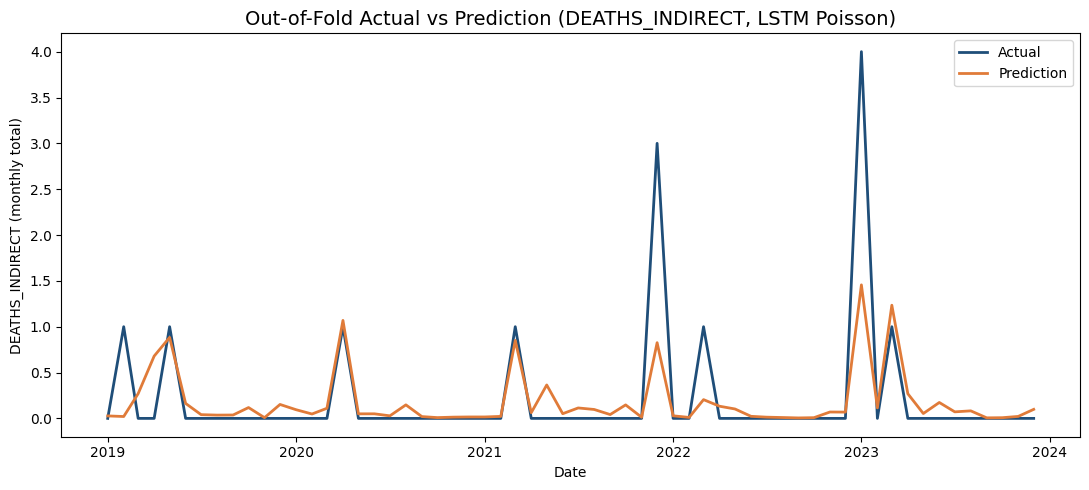

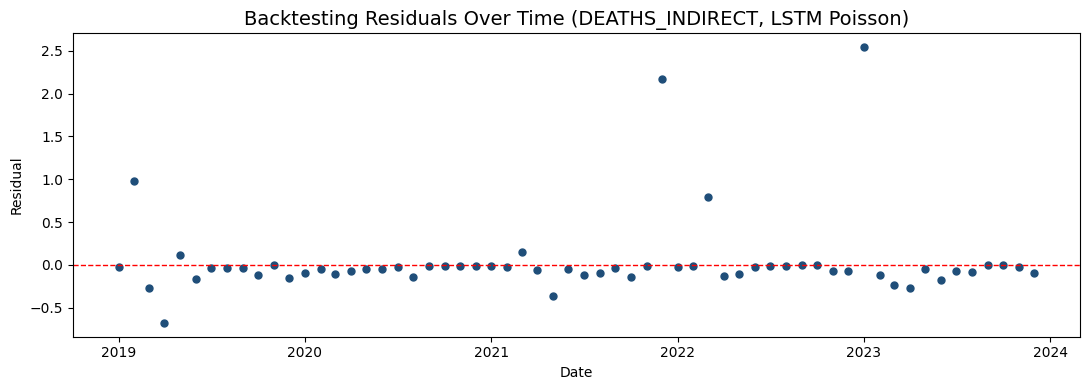

,n,events,D2,RMSE,MPD
year,,,,,
2019,2085,2,0.2578,0.0306,0.0099
2020,1517,1,0.5449,0.0246,0.0044
2021,1728,4,0.4143,0.0477,0.0165
2022,1588,1,0.2898,0.0250,0.0066
2023,1734,5,0.5433,0.0488,0.0154


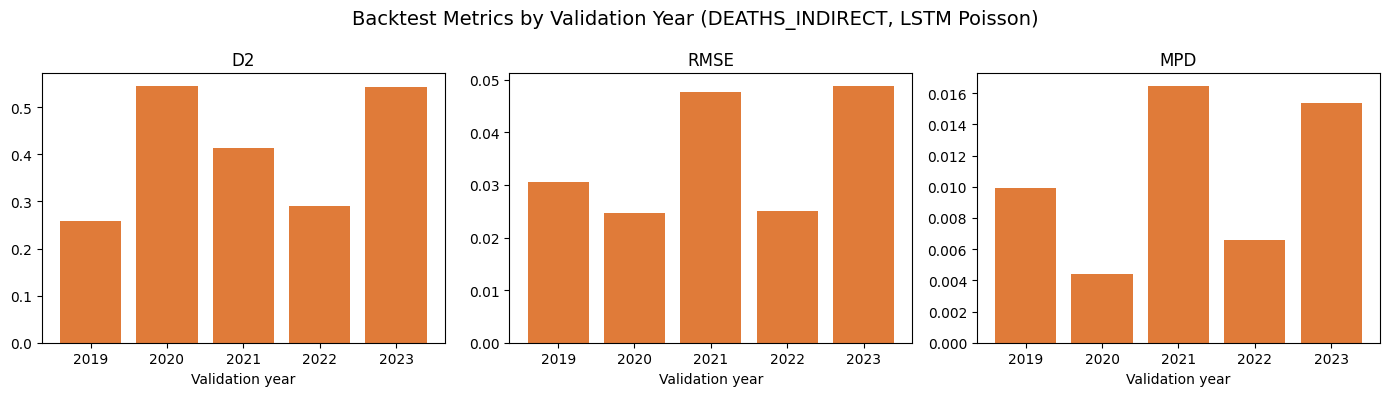

In [ ]:
backtest_target_cv(
    train_events,
    'DEATHS_INDIRECT',
    params=BEST_PARAMETERS_LSTM['DEATHS_INDIRECT'],
    model='LSTM',
)

## TabPFN

### Model setup

In [ ]:
##############################################################################
# TABPFN: A TABULAR FOUNDATION MODEL
##############################################################################

TABPFN_PARAMS = {
    # --- counting structure
    "target_transform": "log1p",
    "bias_correction": True,
    "level_split": "train",
    #"level_min_events": 10,

    # --- target-aware context
    # Keep every available positive case first, then sample zeros until the
    # context reaches 50,000 rows. This is repeated independently for each
    # target and inside every historical backtest fold.
    "context_size": 50000,
    "context_seed": RANDOM_STATE,

    # --- runtime
    "n_estimators": 4,
    "subsample_samples": 50000,
    "predict_batch_size": 4096,
    "device": "auto",
    "fit_mode": "fit_with_cache",
    "verbose": True,
}

MODEL_SPECS["TABPFN"] = {
    "label": "TabPFN-3",
    "nominal_encoding": "category",
    "scale_numeric": False,
    "scalar_param": None,
    "fit_kind": "foundation",
    "default_params": dict(TABPFN_PARAMS),
}


def make_tabpfn_regressor(params, categorical_indices):
    """TabPFN-3 regressor, one ensemble over a subsampled context."""
    return TabPFNRegressor.create_default_for_version(
        ModelVersion.V3,
        device=params["device"],
        n_estimators=params["n_estimators"],
        fit_mode=params["fit_mode"],
        categorical_features_indices=categorical_indices,
        ignore_pretraining_limits=True,
        inference_config={"SUBSAMPLE_SAMPLES": params["subsample_samples"]},
        random_state=RANDOM_STATE,
    )


def tabpfn_matrix(X):
    """Numeric matrix plus the positions of the categorical columns."""
    values = X.copy()
    indices = [X.columns.get_loc(column) for column in categorical_columns(X)]

    for position in indices:
        codes = values.iloc[:, position].cat.codes.astype("float64")
        values.iloc[:, position] = codes.mask(codes < 0.0)

    return values.to_numpy(dtype="float64"), indices


### TabPFN In-Context Learning for Count Prediction

In [ ]:
def global_level_factor(y_true, predicted):
    """Single multiplicative correction: observed total over predicted total."""
    total_actual = float(np.sum(y_true))
    total_predicted = float(np.sum(predicted))

    if total_predicted <= 0.0:
        return 1.0

    return total_actual / total_predicted


def target_stratified_context_positions(y, context_size, random_state):
    """Selects a subset of positions from the input data, prioritizing positive
    target values and sampling zeros to fit within a specified context_size."""
    y = np.asarray(y)
    n_rows = len(y)
    context_size = min(int(context_size), n_rows)

    if context_size == n_rows:
        return np.arange(n_rows, dtype="int64")

    positive_positions = np.flatnonzero(y > 0)
    zero_positions = np.flatnonzero(y <= 0)
    rng = np.random.default_rng(random_state)

    # Keep all positives whenever they fit inside the requested context.
    if len(positive_positions) <= context_size:
        selected_positive = positive_positions
        n_zero = context_size - len(selected_positive)
        selected_zero = rng.choice(zero_positions, size=n_zero, replace=False)
        selected = np.concatenate([selected_positive, selected_zero])
    else:
        # Fallback for a non-rare target.
        selected = rng.choice(positive_positions, size=context_size, replace=False)

    rng.shuffle(selected)
    return selected.astype("int64", copy=False)


def tabpfn_predict_rate(estimator, X, batch_size):
    """Predicted rate for one split, in batches, back on the counting scale."""
    values, _ = tabpfn_matrix(X)

    pieces = [
        estimator.predict(values[start:start + batch_size], output_type="mean")
        for start in range(0, len(values), batch_size)
    ]

    return np.clip(np.expm1(np.concatenate(pieces)), 0.0, None)


def fit_predict_foundation(matrices, params, fit_on, model):
    """Target-stratified TabPFN V3 context in, Poisson-shaped counts out.

    Fits a TabPFN model using a target-stratified context, where all positive
    casualty cases are prioritized and zeros are sampled to fill a specified
    context size, then predicts Poisson-shaped counts that are rescaled by a
    single global level correction (one event group only)."""
    X_fit_full = matrices["X"][fit_on]
    y_fit_full = np.asarray(matrices["y"][fit_on])
    exposure_fit_full = np.asarray(matrices["exposure"][fit_on])

    batch_size = int(params["predict_batch_size"])
    context_size = int(params.get("context_size", params["subsample_samples"]))
    context_seed = int(params.get("context_seed", RANDOM_STATE))

    context_positions = target_stratified_context_positions(
        y=y_fit_full,
        context_size=context_size,
        random_state=context_seed,
    )

    X_fit = X_fit_full.iloc[context_positions]
    y_fit = y_fit_full[context_positions]
    exposure_fit = exposure_fit_full[context_positions]

    z_fit = np.log1p(y_fit / exposure_fit)
    context_values, categorical_indices = tabpfn_matrix(X_fit)

    estimator = make_tabpfn_regressor(params, categorical_indices)
    estimator.fit(context_values, z_fit)

    predicted = {
        name: tabpfn_predict_rate(estimator, X, batch_size) * matrices["exposure"][name]
        for name, X in matrices["X"].items()
    }

    del estimator
    gc.collect()
    torch.cuda.empty_cache()

    if params["bias_correction"]:
        level_split = params["level_split"]

        factor = global_level_factor(
            matrices["y"][level_split],
            predicted[level_split],
        )

        print(f" level correction on {level_split}: global x{factor:.4f}")

        for name in predicted:
            predicted[name] = predicted[name] * factor

    for name in predicted:
        predicted[name] = np.clip(predicted[name], 1e-6, None)

    return None, predicted


### One target end to end

In [ ]:
###############################################################
# TabPFN now rides the shared pipeline
###############################################################


def run_target_model_tabpfn(
    train_df,
    calibration_df,
    test_df,
    target,
    params=None,
    alpha_target=0.10,
    gamma=0.01,
    #group_column=GROUP_COL,
):
    """One target end to end, through the shared run_target_model."""
    return run_target_model(
        train_df=train_df,
        calibration_df=calibration_df,
        test_df=test_df,
        target=target,
        params=params,
        model="TABPFN",
        alpha_target=alpha_target,
        gamma=gamma,
        #group_column=group_column,
    )


def build_forecast_results_tabpfn(
    train_df,
    calibration_df,
    test_df,
    targets,
    params=None,
    alpha_target=0.10,
    gamma=0.01,
    #group_column=GROUP_COL,
):
    """One TabPFN result per outcome, same design as build_forecast_results."""
    return build_forecast_results(
        train_df=train_df,
        calibration_df=calibration_df,
        test_df=test_df,
        targets=targets,
        best_params={target: params for target in targets},
        model="TABPFN",
        alpha_target=alpha_target,
        gamma=gamma,
        #group_column=group_column,
    )


### Prediction

In [ ]:
tabpfn_results = build_forecast_results_tabpfn(
    train_events,
    calibration_events,
    test_events,
    FORECAST_TARGETS,
    params=TABPFN_PARAMS,
    #group_column=GROUP_COL,
)
forecast_results = tabpfn_results


[TabPFN-3] fitting INJURIES_DIRECT...


tabpfn-v3-regressor-v3_default.ckpt: reconstructing file:   0%|          |  0.00B /  233MB            

tabpfn-v3-regressor-v3_default.ckpt: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

 level correction on train: global x2.9167
[TabPFN-3] fitting INJURIES_INDIRECT...
 level correction on train: global x43.5595
[TabPFN-3] fitting DEATHS_DIRECT...
 level correction on train: global x3.8294
[TabPFN-3] fitting DEATHS_INDIRECT...
 level correction on train: global x226.3089


### Reporting Results

In [ ]:
display(point_metrics_by_target(tabpfn_results, model='TABPFN').round(4))

n  events      D2     RMSE     MPD
Target            Split                                              
DEATHS_DIRECT     train        86063    1812  0.7140   1.1134  0.1928
                  calibration   2416      27  0.4005   0.2448  0.1199
                  test          1776      25  0.4033   0.4730  0.2011
DEATHS_INDIRECT   train        86063      37 -0.3394   0.0433  0.0114
                  calibration   2416       2 -0.8361   0.0288  0.0216
                  test          1776       0     NaN   0.0011  0.0004
INJURIES_DIRECT   train        86063    8584  0.7714  13.0471  1.9934
                  calibration   2416     100  0.4416   2.4363  1.1907
                  test          1776      74  0.2199   1.4379  0.8155
INJURIES_INDIRECT train        86063      65  0.1319   0.3507  0.0466
                  calibration   2416       4 -0.5126   0.1427  0.0765
                  test          1776       2 -0.5063   0.2161  0.1089

In [ ]:
display(daily_conformal_summary(tabpfn_results, model='TABPFN').round(4))

,Days,Coverage,MeanActual,MeanWidth,RelWidth
Target,,,,,
DEATHS_DIRECT,360,0.9194,0.1778,0.3736,2.1013
DEATHS_INDIRECT,360,0.9222,0.0000,0.0027,NaN
INJURIES_DIRECT,360,0.9278,0.6889,2.0263,2.9414
INJURIES_INDIRECT,360,0.9333,0.0250,0.5622,22.4894


### Visualization Results

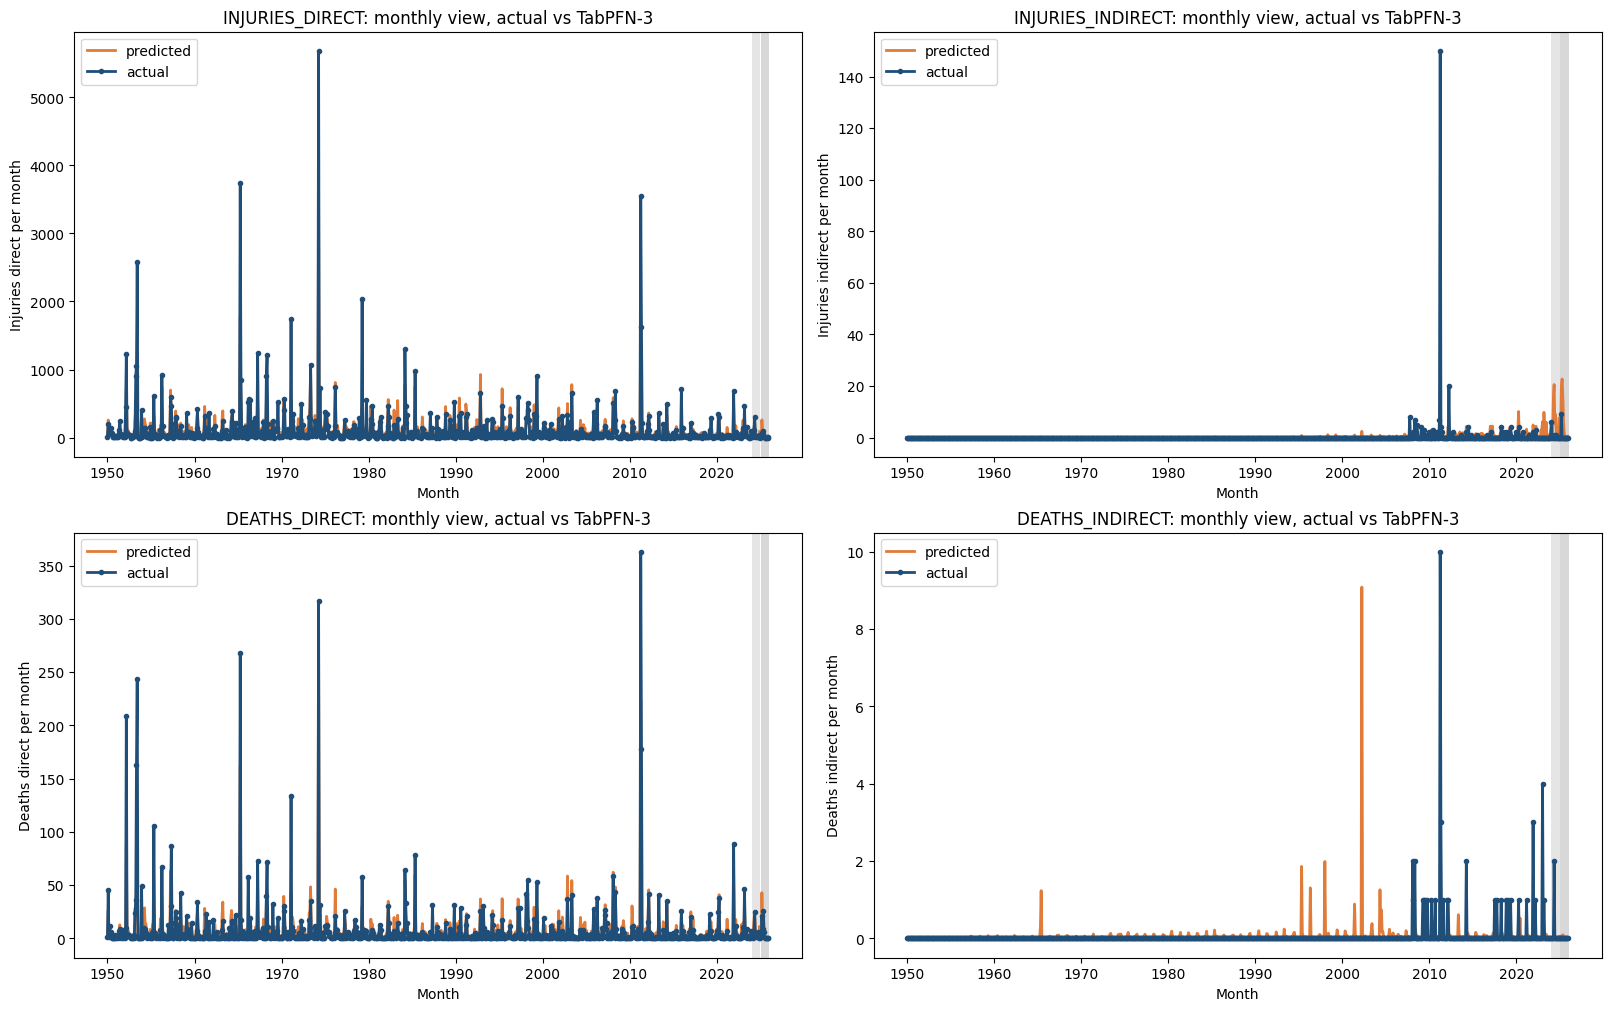

In [ ]:
target_list = ['INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT', 'DEATHS_INDIRECT']
plot_monthly_actual_vs_predicted(tabpfn_results, target_list, model='TABPFN')

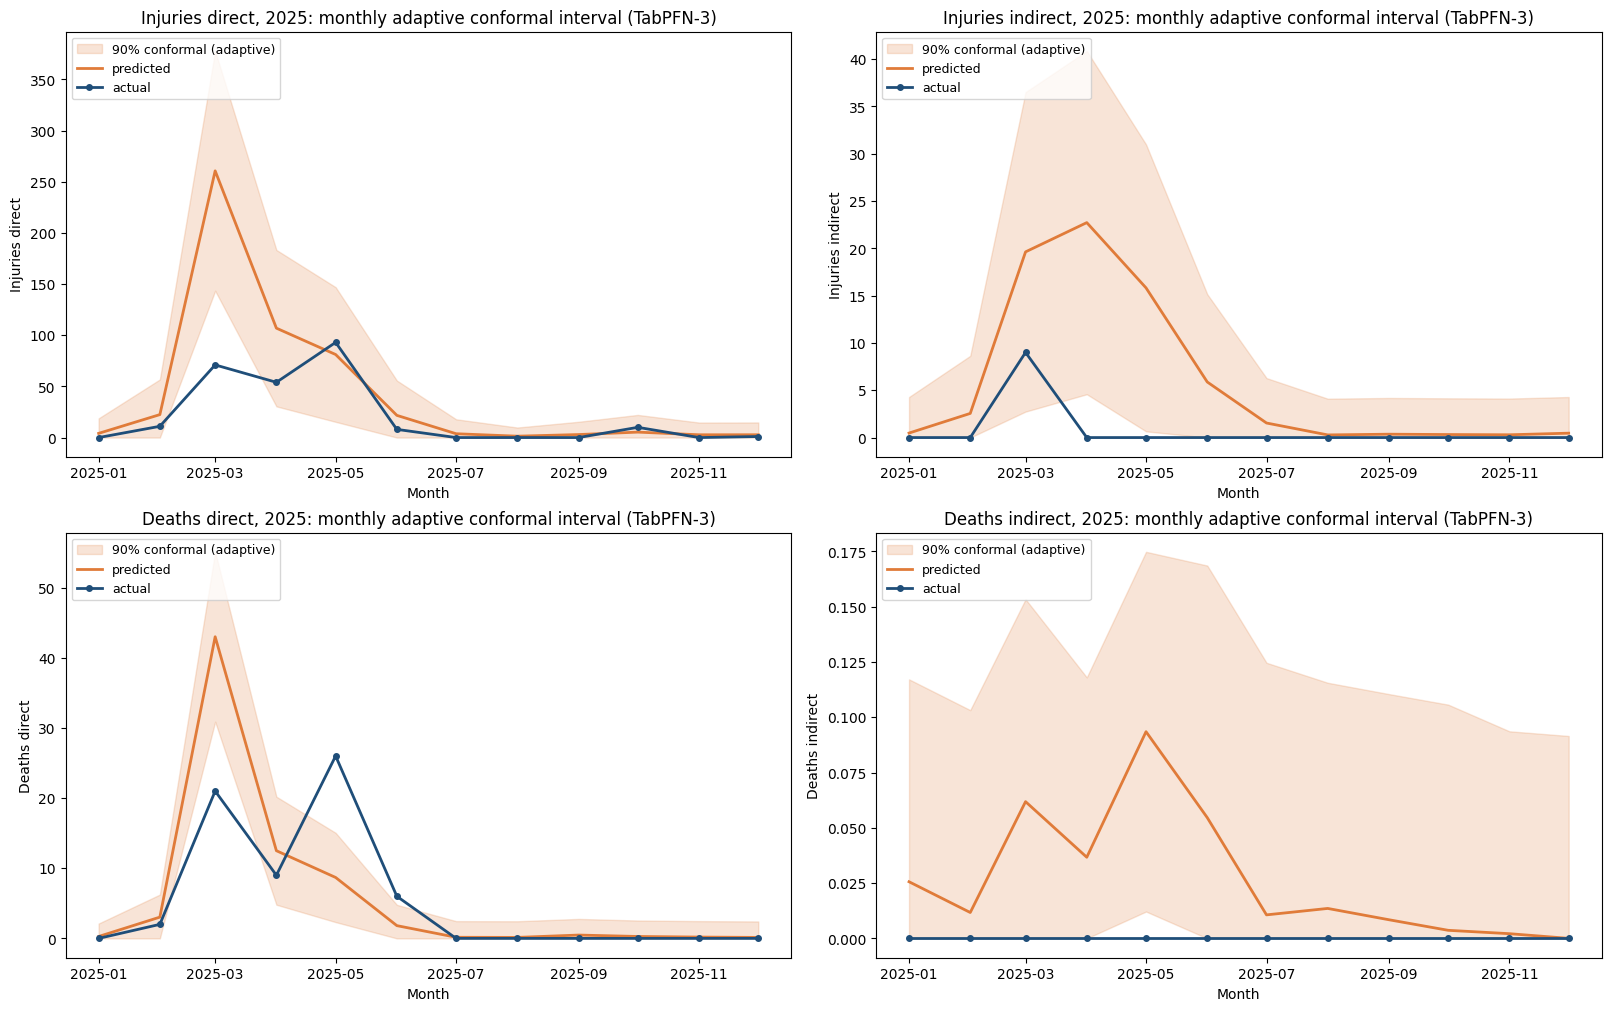

In [ ]:
plot_conformal_monthly(tabpfn_results, target_list, model='TABPFN', test_year=2025)

### Backtesting Results

In [ ]:

###################################################
# Historical backtesting, TabPFN
###################################################

VALIDATION_YEARS = (2019, 2020, 2021, 2022, 2023)


def backtest_target_cv_tabpfn(
    train_df,
    target,
    params=None,
    validation_years=VALIDATION_YEARS,
):
    """One target backtested on the shared expanding-window folds."""
    return backtest_target_cv(
        train_df=train_df,
        target=target,
        params=params,
        model="TABPFN",
        validation_years=validation_years,
    )



 BACKTESTING FOR TARGET: INJURIES_DIRECT (TabPFN-3)
Fold 1: train <= 2018, validation = 2019
 level correction on train: global x3.2709
Fold 2: train <= 2019, validation = 2020
 level correction on train: global x3.3593
Fold 3: train <= 2020, validation = 2021
 level correction on train: global x3.5459
Fold 4: train <= 2021, validation = 2022
 level correction on train: global x3.0192
Fold 5: train <= 2022, validation = 2023
 level correction on train: global x3.2349


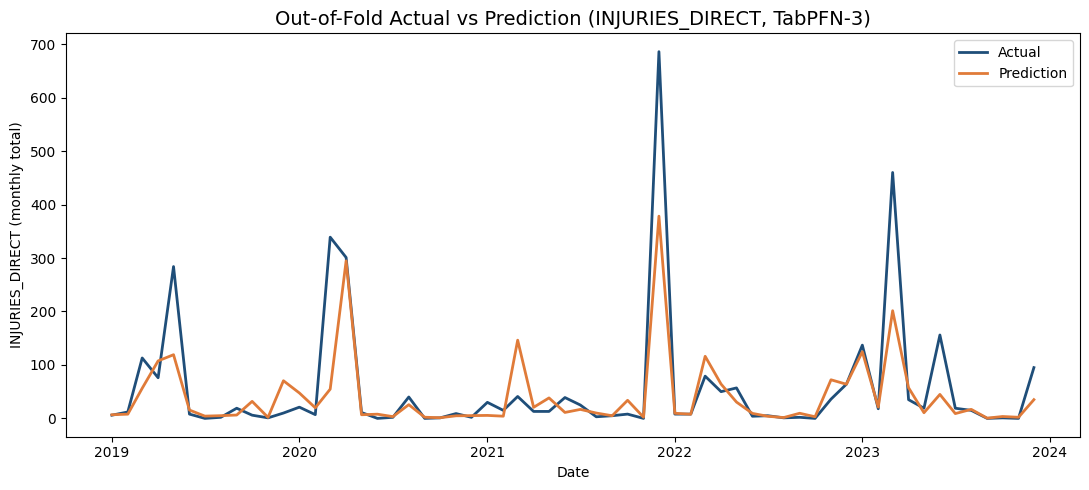

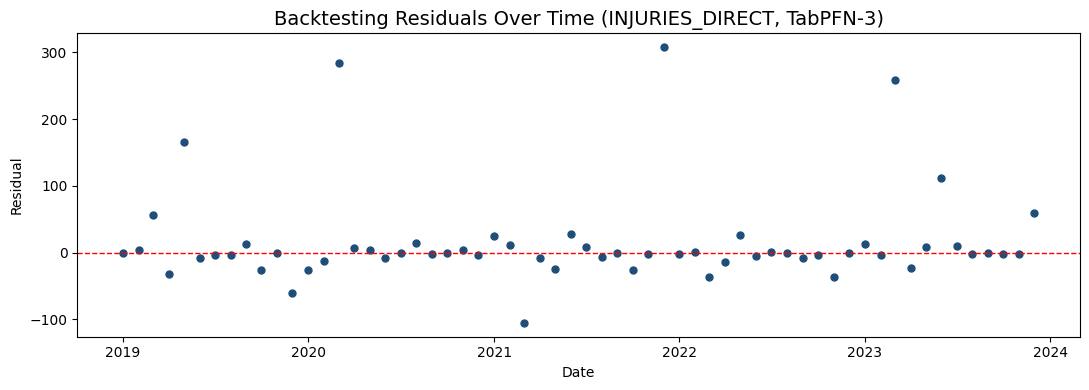

,n,events,D2,RMSE,MPD
year,,,,,
2019,2085,75,0.4562,4.1981,1.3300
2020,1517,71,0.5867,5.3999,1.7267
2021,1728,75,0.6685,6.5924,1.5505
2022,1588,76,0.4585,1.5281,0.7814
2023,1734,97,0.4158,5.2201,2.5017


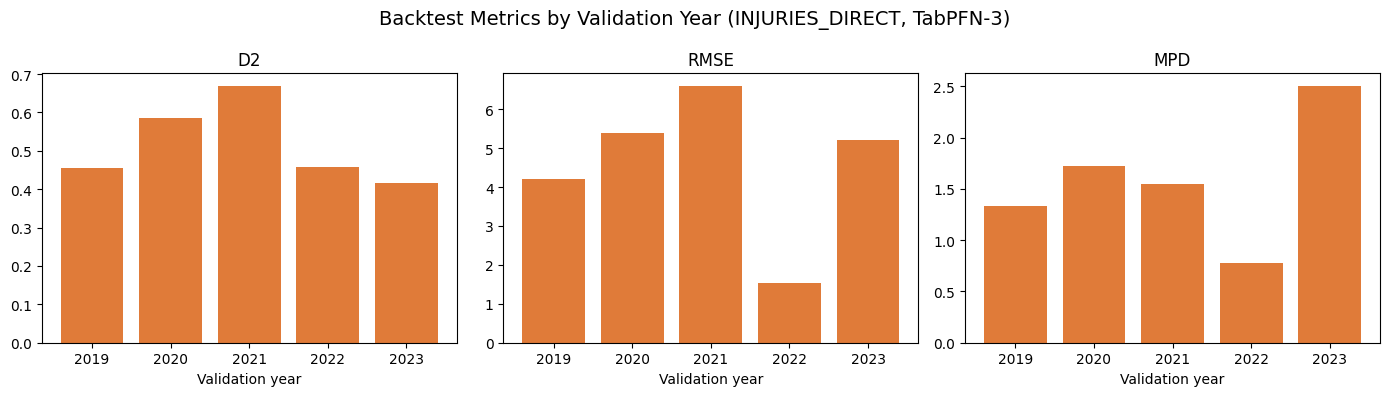

In [ ]:
backtest_target_cv_tabpfn(
    train_events,
    'INJURIES_DIRECT',
    params=TABPFN_PARAMS,
    validation_years=VALIDATION_YEARS,
)


 BACKTESTING FOR TARGET: INJURIES_INDIRECT (TabPFN-3)
Fold 1: train <= 2018, validation = 2019
 level correction on train: global x49.0078
Fold 2: train <= 2019, validation = 2020
 level correction on train: global x50.3900
Fold 3: train <= 2020, validation = 2021
 level correction on train: global x31.7179
Fold 4: train <= 2021, validation = 2022
 level correction on train: global x52.6281
Fold 5: train <= 2022, validation = 2023
 level correction on train: global x43.4117


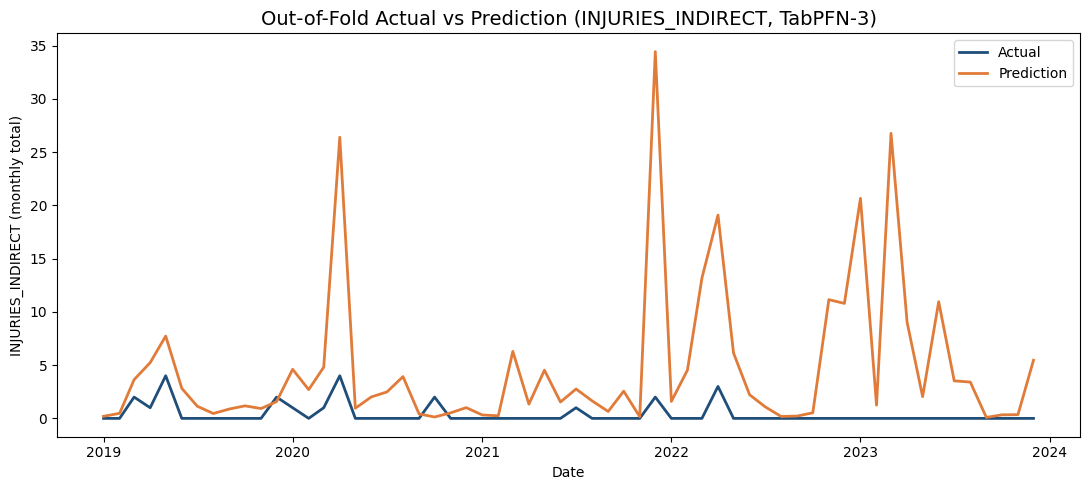

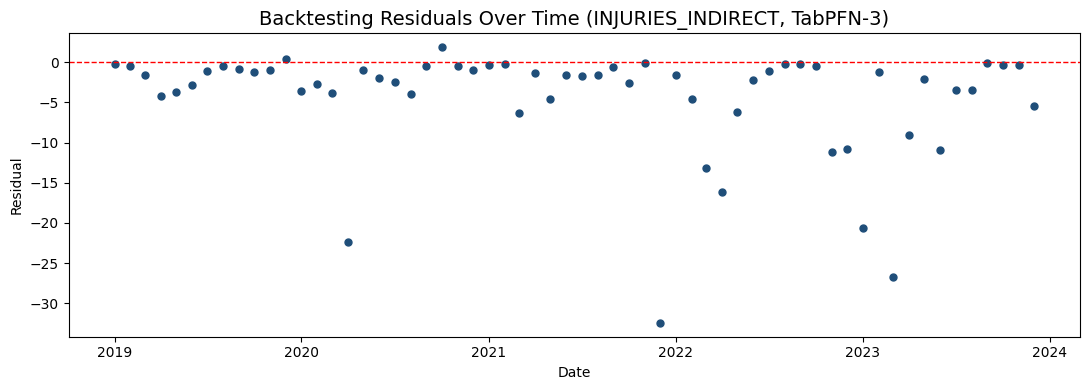

,n,events,D2,RMSE,MPD
year,,,,,
2019,2085,7,-0.2797,0.0960,0.0642
2020,1517,5,-0.6731,0.1616,0.1029
2021,1728,2,-1.9186,0.0997,0.0691
2022,1588,1,-2.8163,0.1801,0.1063
2023,1734,0,NaN,0.1664,0.0967


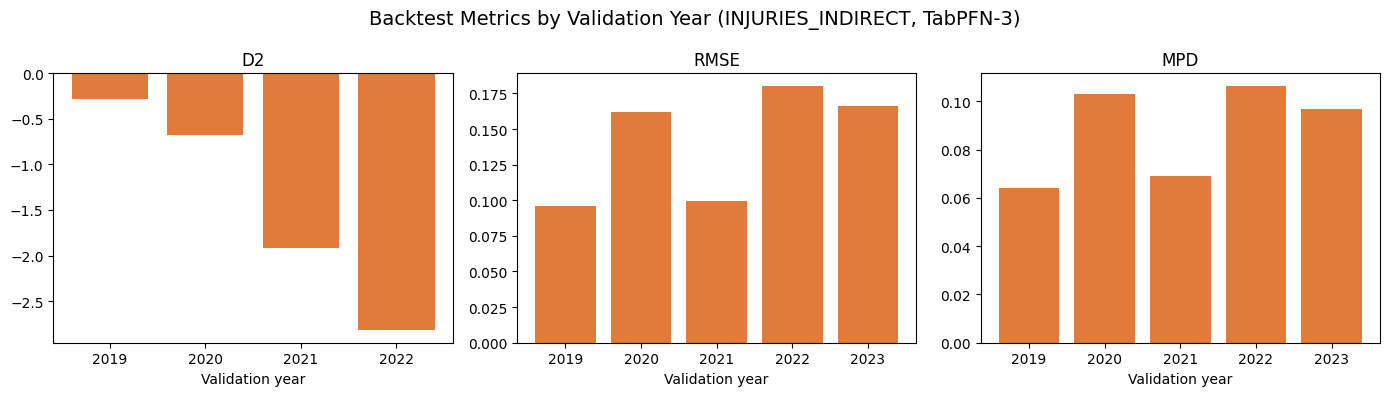

In [ ]:
backtest_target_cv_tabpfn(
    train_events,
    'INJURIES_INDIRECT',
    params=TABPFN_PARAMS,
    validation_years=VALIDATION_YEARS,
)


 BACKTESTING FOR TARGET: DEATHS_DIRECT (TabPFN-3)
Fold 1: train <= 2018, validation = 2019
 level correction on train: global x4.0219
Fold 2: train <= 2019, validation = 2020
 level correction on train: global x4.0346
Fold 3: train <= 2020, validation = 2021
 level correction on train: global x3.9461
Fold 4: train <= 2021, validation = 2022
 level correction on train: global x3.9161
Fold 5: train <= 2022, validation = 2023
 level correction on train: global x3.8314


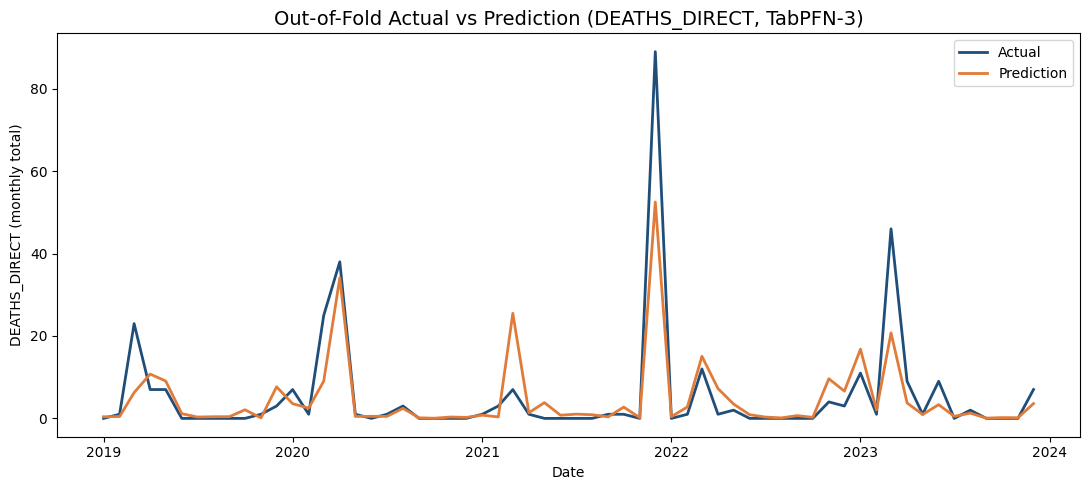

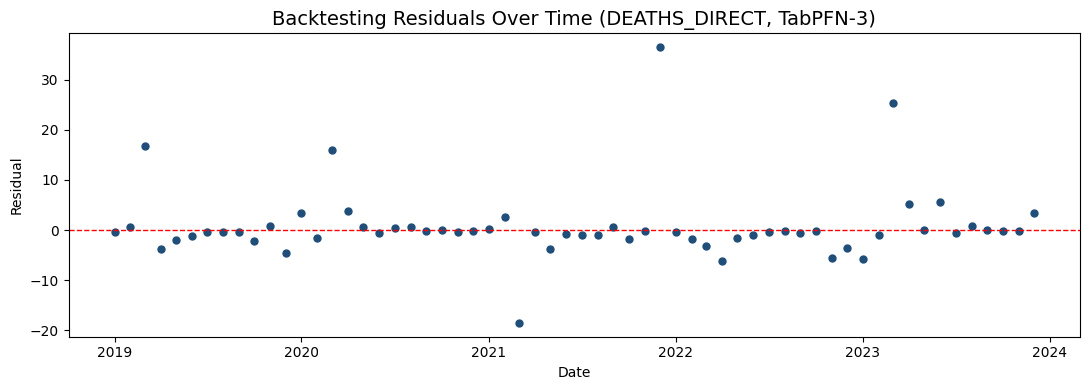

,n,events,D2,RMSE,MPD
year,,,,,
2019,2085,14,0.4512,0.5085,0.1290
2020,1517,27,0.5328,0.5409,0.2093
2021,1728,23,0.6348,0.7706,0.2169
2022,1588,14,0.2800,0.2152,0.1031
2023,1734,31,0.4491,0.5063,0.2397


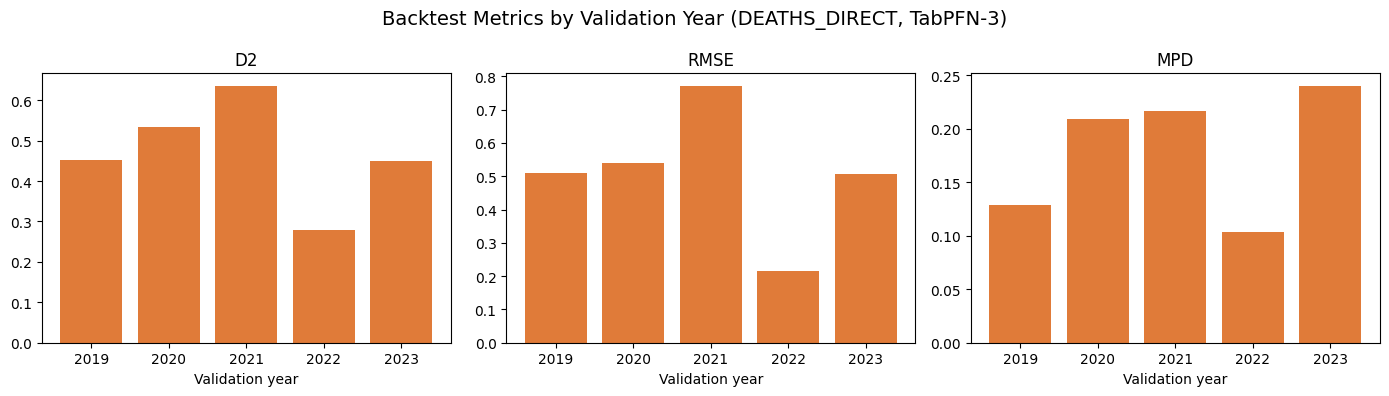

In [ ]:
backtest_target_cv_tabpfn(
    train_events,
    'DEATHS_DIRECT',
    params=TABPFN_PARAMS,
    validation_years=VALIDATION_YEARS,
)


 BACKTESTING FOR TARGET: DEATHS_INDIRECT (TabPFN-3)
Fold 1: train <= 2018, validation = 2019
 level correction on train: global x29.6205
Fold 2: train <= 2019, validation = 2020
 level correction on train: global x408.6867
Fold 3: train <= 2020, validation = 2021
 level correction on train: global x352.4041
Fold 4: train <= 2021, validation = 2022
 level correction on train: global x44.7709
Fold 5: train <= 2022, validation = 2023
 level correction on train: global x298.9027


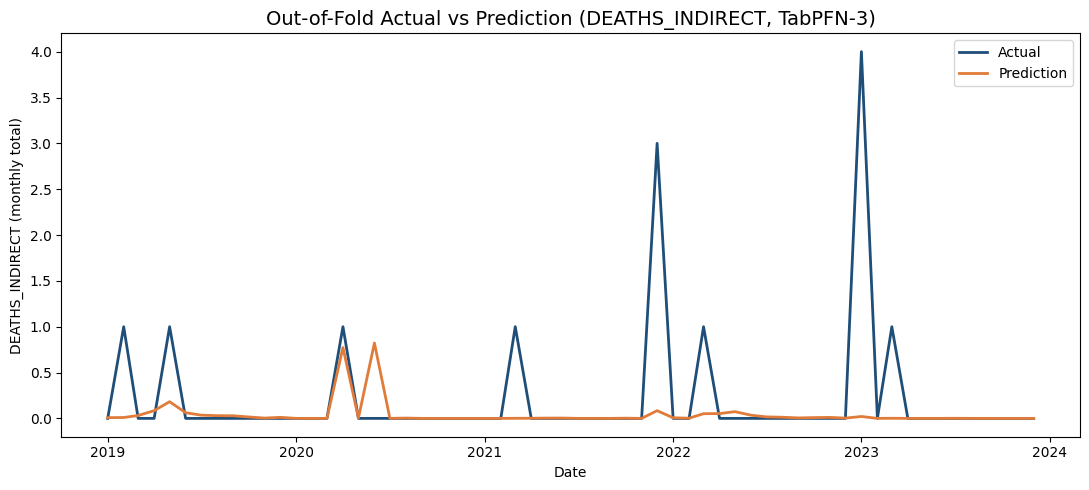

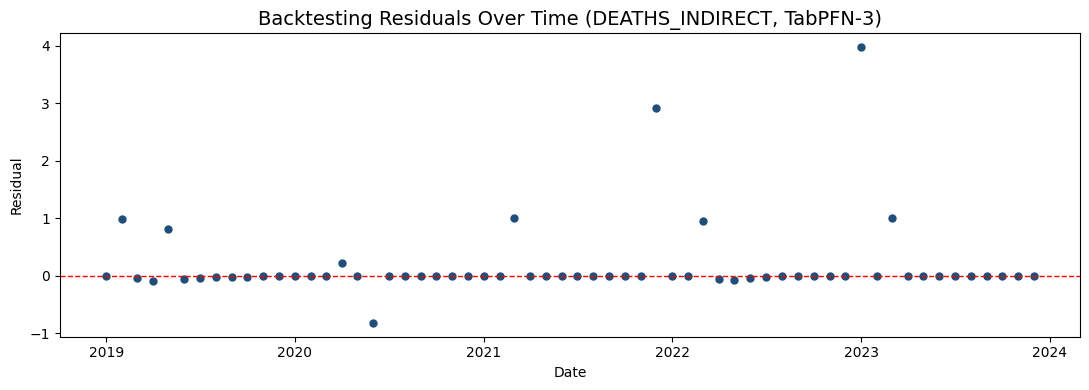

,n,events,D2,RMSE,MPD
year,,,,,
2019,2085,2,-0.3568,0.0310,0.0181
2020,1517,1,0.7111,0.0322,0.0028
2021,1728,4,-1.1158,0.0482,0.0594
2022,1588,1,0.0328,0.0251,0.0090
2023,1734,5,-1.1920,0.0537,0.0739


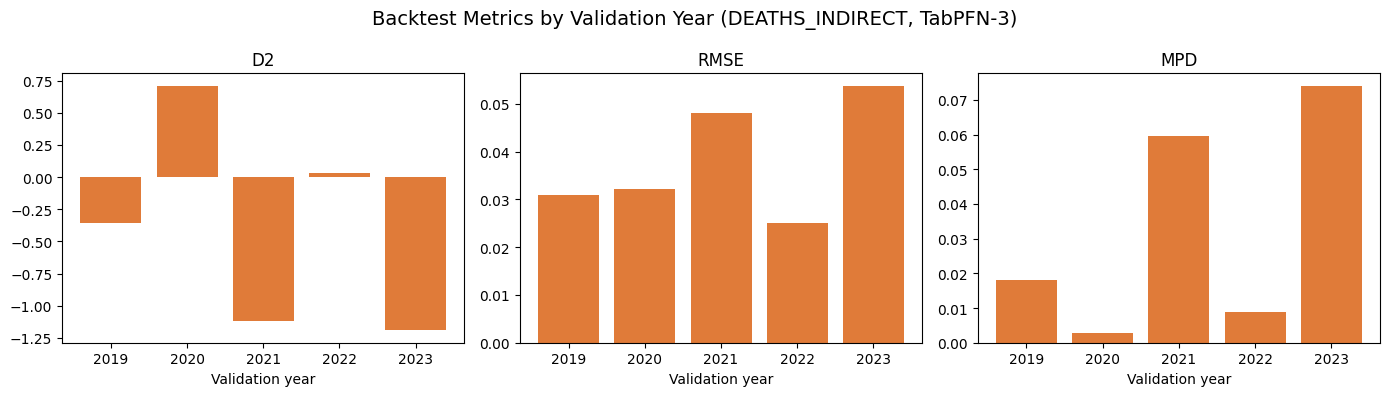

In [ ]:
backtest_target_cv_tabpfn(
    train_events,
    'DEATHS_INDIRECT',
    params=TABPFN_PARAMS,
    validation_years=VALIDATION_YEARS,
)

## Models Comparison

In [ ]:
#########################################################
# COMPARISON SETUP
#############################################################

MODEL_RESULTS = {
    "GLM": glm_results,
    "LGBM": lgbm_results,
    "LSTM": lstm_results,
    "TABPFN": tabpfn_results,
}

MODEL_COLORS = {
    "GLM": "#1f4e79",
    "LGBM": "#e07b39",
    "LSTM": "#4c9a2a",
    "TABPFN": "#8e44ad",
}

COMPARISON_METRICS = ["D2", "RMSE", "MPD"]
METRIC_DIRECTION = {"D2": "high = better", "RMSE": "low = better", "MPD": "low = better"}
ALPHA_TARGET = 0.10


def collect_point_metrics(model_results=MODEL_RESULTS):
    frames = []
    for model_name, results in model_results.items():
        table = point_metrics_by_target(results).reset_index()
        table["Model"] = model_name
        frames.append(table)

    comparison = pd.concat(frames, ignore_index=True)
    comparison["Split"] = pd.Categorical(comparison["Split"], categories=SPLIT_ORDER, ordered=True)

    return comparison[["Model", "Target", "Split", *POINT_METRIC_COLUMNS]].sort_values(
        ["Target", "Split", "Model"]
    )


def collect_conformal_by_target(model_results=MODEL_RESULTS, alpha_target=ALPHA_TARGET):
    rows = []
    for model_name, results in model_results.items():
        for target, result in results.items():
            levels = {
                "daily": result["daily_conformal"],
                "monthly": result["monthly_conformal"],
            }
            for level_name, frame in levels.items():
                rows.append({
                    "Model": model_name,
                    "Target": target,
                    "Level": level_name,
                    "n": len(frame),
                    "Coverage": float(frame["covered"].mean()),
                    "MeanActual": float(frame["actual"].mean()),
                    "MeanWidth": float(frame["width"].mean()),
                    "Nominal": 1.0 - alpha_target,
                })


    return _add_relative_width(pd.DataFrame(rows))[
        ["Model", "Target", "Level", "n", "Coverage",
         "MeanActual", "MeanWidth", "RelWidth", "Nominal"]
    ]



point_comparison = collect_point_metrics()
conformal_comparison = collect_conformal_by_target()





In [ ]:
#############################################################
# 1. POINT METRICS: MODEL x TARGET x SPLIT
#############################################################


def plot_metric_comparison(
    metrics_table=None,
    metrics=COMPARISON_METRICS,
    splits=SPLIT_ORDER,
    targets=None,
    model_colors=MODEL_COLORS,
):
    metrics_table = collect_point_metrics() if metrics_table is None else metrics_table
    targets = list(FORECAST_TARGETS) if targets is None else list(targets)
    models = list(model_colors)

    positions = np.arange(len(targets))
    bar_width = 0.8 / len(models)

    fig, axes = plt.subplots(
        len(metrics),
        len(splits),
        figsize=(5.4 * len(splits), 3.6 * len(metrics)),
        layout="constrained",
        squeeze=False,
    )

    for row, metric in enumerate(metrics):
        for column, split in enumerate(splits):
            ax = axes[row][column]
            panel = metrics_table[metrics_table["Split"] == split]

            for index, model_name in enumerate(models):
                values = (
                    panel[panel["Model"] == model_name]
                    .set_index("Target")
                    .reindex(targets)[metric]
                    .to_numpy(dtype=float)
                )
                offset = (index - (len(models) - 1) / 2) * bar_width
                ax.bar(
                    positions + offset,
                    values,
                    width=bar_width,
                    color=model_colors[model_name],
                    edgecolor="white",
                    linewidth=0.5,
                    label=model_name if (row == 0 and column == 0) else None,
                )

                for position, value in zip(positions + offset, values):
                    if np.isnan(value):
                        ax.text(position, 0, "n/d", ha="center", va="bottom", fontsize=8, color="grey")

            if metric == "D2":
                ax.axhline(0.0, color="grey", linestyle="--", linewidth=1)
            else:
                spread = panel[metric].to_numpy(dtype=float)
                spread = spread[np.isfinite(spread) & (spread > 0)]
                if len(spread) > 0 and spread.max() / spread.min() > 50:
                    ax.set_yscale("log")
                    ax.set_ylim(spread.min() * 0.5, spread.max() * 2.0)

            ax.set_xticks(positions)
            ax.set_xticklabels([name for name in targets], rotation=20, ha="right", fontsize=9)
            ax.set_title(f"{metric} — {split} ({METRIC_DIRECTION[metric]})", fontsize=11)
            ax.set_ylabel(metric)

    axes[0][0].legend(fontsize=9, title="Model")
    fig.suptitle("Point metrics comparison by target and split", fontsize=14)
    plt.show()




In [ ]:
#############################################################
# 2. CONFORMAL COVERAGE AND RELATIVE WIDTH BY TARGET
#############################################################

def plot_conformal_comparison(
    conformal_table=None,
    levels=("daily",),
    targets=None,
    quantities=("Coverage", "RelWidth"),
    model_colors=MODEL_COLORS,
):
    """Coverage and width per target"""
    conformal_table = collect_conformal_by_target() if conformal_table is None else conformal_table


    targets = list(FORECAST_TARGETS) if targets is None else list(targets)
    models = list(model_colors)
    columns = [name for name in quantities if name in conformal_table.columns]


    positions = np.arange(len(targets))
    bar_width = 0.8 / len(models)
    target_labels = [name.replace("_", " ").capitalize() for name in targets]
    nominal = (
        float(conformal_table["Nominal"].iloc[0])
        if "Nominal" in conformal_table.columns
        else None
    )

    fig, axes = plt.subplots(
        len(levels),
        len(columns),
        figsize=(7.0 * len(columns), 4.4 * len(levels)),
        layout="constrained",
        squeeze=False,
    )

    for row, level_name in enumerate(levels):
        panel_source = conformal_table[conformal_table["Level"] == level_name]

        for column, quantity in enumerate(columns):
            ax = axes[row][column]

            for index, model_name in enumerate(models):
                values = (
                    panel_source[panel_source["Model"] == model_name]
                    .set_index("Target")
                    .reindex(targets)[quantity]
                    .to_numpy(dtype=float)
                )
                offset = (index - (len(models) - 1) / 2) * bar_width
                bars = ax.bar(
                    positions + offset,
                    values,
                    width=bar_width,
                    color=model_colors[model_name],
                    edgecolor="white",
                    linewidth=0.5,
                    label=model_name if (row == 0 and column == 0) else "_nolegend_",
                )
                ax.bar_label(
                    bars,
                    labels=["" if not np.isfinite(v) else f"{v:.2f}" for v in values],
                    fontsize=8,
                    padding=2,
                )

            if quantity == "Coverage":
                if nominal is not None:
                    ax.axhline(
                        nominal,
                        color="red",
                        linestyle="--",
                        linewidth=1.2,
                        label=f"nominal {nominal:.2f}" if row == 0 else "_nolegend_",
                    )
                ax.set_ylim(0.0, 1.15)
            else:
                spread = panel_source[quantity].to_numpy(dtype=float)
                spread = spread[np.isfinite(spread) & (spread > 0)]

                if len(spread) > 0:
                    if spread.max() / spread.min() > 50:
                        ax.set_yscale("log")
                    else:
                        ax.set_ylim(0.0, spread.max() * 1.20)

            ax.set_xticks(positions)
            ax.set_xticklabels(target_labels, rotation=20, ha="right", fontsize=9)
            ax.set_title(f"{quantity}", fontsize=11)
            ax.set_ylabel(quantity)
            ax.grid(axis="y", alpha=0.25, linewidth=0.6)
            ax.set_axisbelow(True)

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="outside lower center", ncols=len(models) + 1, fontsize=9)
    fig.suptitle("Conformal intervals: coverage and relative width by target", fontsize=14)
    plt.show()

In [ ]:
# ==============================================================================
# 3. POINT METRICS HEATMAP BY EVENT GROUP AND TARGET
# ==============================================================================

HEATMAP_METRICS = {
    "D2": ("D2 (high = better)", "RdYlGn", "{:.2f}"),
    "RMSE": ("RMSE (low = better)", "YlOrRd", "{:.3g}"),
    "MPD": ("MPD (low = better)", "YlOrRd", "{:.3g}"),
}


def _shade_by_target(panel, metric):
    """Colour scale for one heatmap panel."""
    if metric == "D2":
        return panel.clip(lower=-1.0, upper=1.0), -1.0, 1.0

    lowest = panel.min(axis=0)
    highest = panel.max(axis=0)
    span = (highest - lowest).replace(0.0, np.nan)

    return (panel - lowest) / span, 0.0, 1.0


def plot_point_metrics_heatmap(
    results,
    metrics=None,
    targets=None,
    model=None,
    group_column=GROUP_COL,
    split="test",
):
    """Event group x target heatmap of the point metrics, test split only."""
    label = model_label(_check_model(results, model))
    metrics = list(HEATMAP_METRICS) if metrics is None else list(metrics)
    targets = list(FORECAST_TARGETS) if targets is None else list(targets)

    table = point_metrics_by_event_group(
        results, group_column=group_column, targets=None, model=model
    )
    table = table[table.index.get_level_values("Split") == split]

    if table.empty:
        print(f"[{label}] no event-group breakdown available (single-group dataset) - skipping heatmap.")
        return

    table = table.droplevel("Split")

    group_order = (
        table.groupby(group_column, observed=True)["events"]
        .sum()
        .sort_values(ascending=False)
        .index
    )
    target_labels = [name.replace("_", " ").capitalize() for name in targets]

    fig, axes = plt.subplots(
        1,
        len(metrics),
        figsize=(4.2 * len(metrics), 0.42 * len(group_order) + 2.6),
        layout="constrained",
        squeeze=False,
    )

    for column, metric in enumerate(metrics):
        ax = axes[0][column]
        title, colormap, number_format = HEATMAP_METRICS[metric]

        panel = (
            table[metric]
            .unstack("Target")
            .reindex(index=group_order, columns=targets)
            .astype(float)
        )
        shading, vmin, vmax = _shade_by_target(panel, metric)

        image = ax.imshow(
            shading.to_numpy(),
            cmap=colormap,
            vmin=vmin,
            vmax=vmax,
            aspect="auto",
        )
        image.cmap.set_bad("#e8e8e8")

        for row_index, group_name in enumerate(panel.index):
            for column_index, target in enumerate(panel.columns):
                value = panel.loc[group_name, target]
                shade = shading.loc[group_name, target]

                if not np.isfinite(value):
                    ax.text(column_index, row_index, "n/d", ha="center", va="center",
                            fontsize=7, color="grey")
                    continue

                ax.text(
                    column_index,
                    row_index,
                    number_format.format(value),
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="white" if np.isfinite(shade) and shade > 0.72 else "black",
                )

        ax.set_xticks(np.arange(len(targets)))
        ax.set_xticklabels(target_labels, rotation=30, ha="right", fontsize=8)
        ax.set_yticks(np.arange(len(panel.index)))
        ax.set_yticklabels([str(name).replace("_", " ") for name in panel.index], fontsize=8)
        ax.set_title(title, fontsize=11)

        ax.set_xticks(np.arange(len(targets) + 1) - 0.5, minor=True)
        ax.set_yticks(np.arange(len(panel.index) + 1) - 0.5, minor=True)
        ax.grid(which="minor", color="white", linewidth=1.0)
        ax.tick_params(which="minor", length=0)

        bar = fig.colorbar(image, ax=ax, fraction=0.045, pad=0.02)
        bar.set_label(
            "D2" if metric == "D2" else "per-target min-max (dark = worse)", fontsize=8
        )
        bar.ax.tick_params(labelsize=7)

    fig.suptitle(
        f"Point metrics by event group and target — {split} split — {label}", fontsize=14
    )
    plt.show()

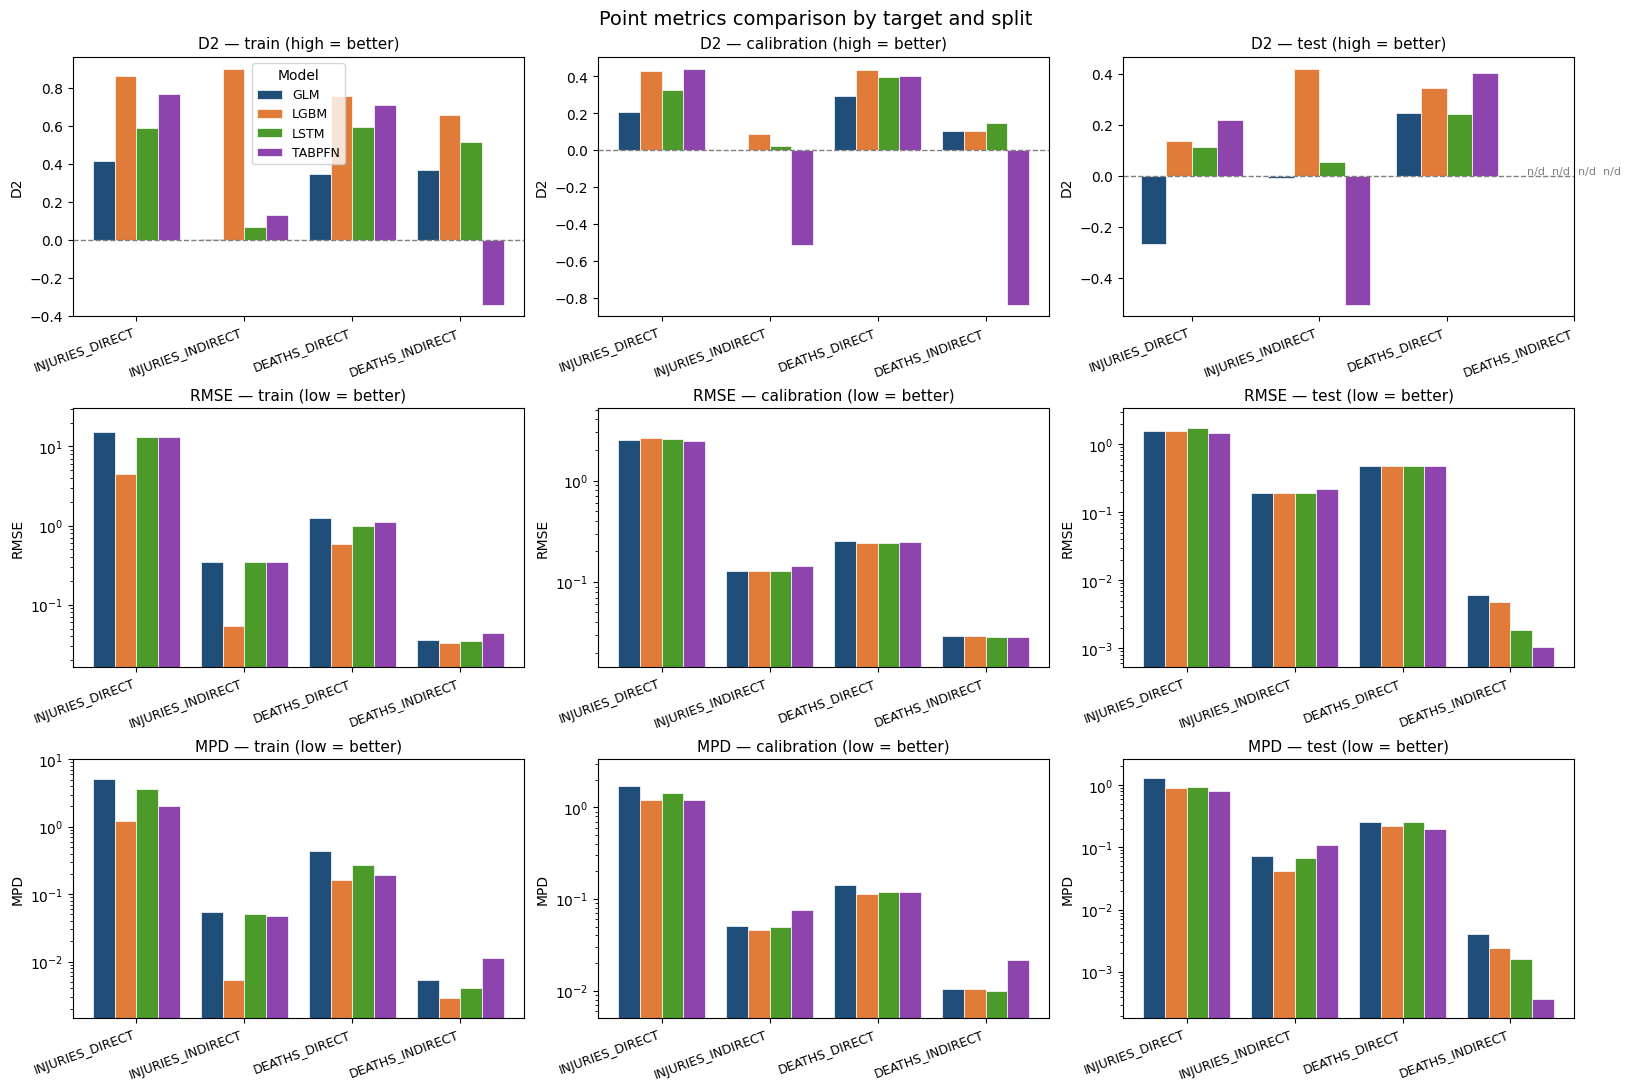

In [ ]:
plot_metric_comparison(point_comparison)

In [ ]:
plot_point_metrics_heatmap(glm_results)


[Poisson GLM] no event-group breakdown available (single-group dataset) - skipping heatmap.


In [ ]:
plot_point_metrics_heatmap(lgbm_results)


[LightGBM Poisson] no event-group breakdown available (single-group dataset) - skipping heatmap.


In [ ]:
plot_point_metrics_heatmap(lstm_results)


[LSTM Poisson] no event-group breakdown available (single-group dataset) - skipping heatmap.


In [ ]:
plot_point_metrics_heatmap(tabpfn_results)

[TabPFN-3] no event-group breakdown available (single-group dataset) - skipping heatmap.


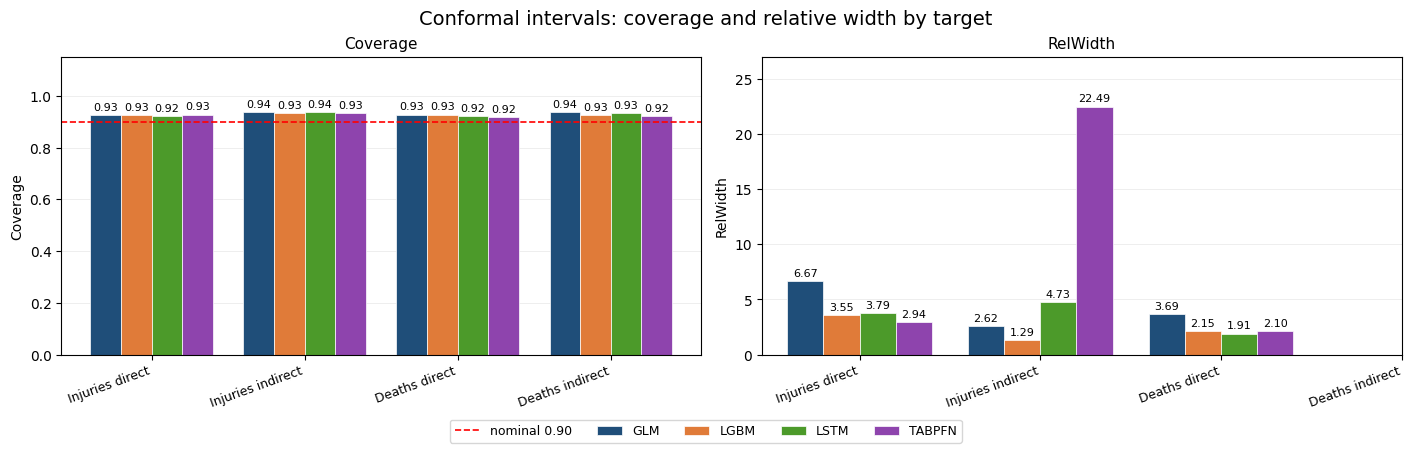

In [ ]:
plot_conformal_comparison(conformal_comparison)